## starting ArcGIS 

In [167]:
#!pip install geopandas pandas shapely
#!pip install geopandas matplotlib
#!pip install statsmodels
#!pip install pandas matplotlib seaborn geopandas



Defaulting to user installation because normal site-packages is not writeable
  Using cached click-8.1.8-py3-none-any.whl (98 kB)


In [1]:
from arcgis.gis import GIS
import pandas as pd
import arcpy
import os
gis = GIS("pro")

# Set the path to your ArcGIS Pro project file
aprx_file_path = r"C:/Users/tokey.1/OneDrive - The Ohio State University/pyst_test/pyst_test.aprx" # r"C:/study/1_OSU/harvey/pyst_test/pyst_test.aprx"

if os.path.exists(aprx_file_path):
    print("File exists.")
else:
    print("File not found.")


File exists.


In [2]:
# Create an ArcGIS Pro project object
aprx = arcpy.mp.ArcGISProject(aprx_file_path)
# Access maps and layers within the project
map1 = aprx.listMaps()[0]  # Access the first map in the project

In [9]:
#let's check the layers on the map scene
layers = map1.listLayers()
for layer in layers:
    print(f"Layer name: {layer.name}, Type: {layer.isFeatureLayer}, Visible: {layer.visible}")

Layer name: Light Gray Reference, Type: False, Visible: True
Layer name: FinalRasterPoints_2498856_Dis, Type: True, Visible: True
Layer name: FinalRasterPoints_2498856, Type: True, Visible: False
Layer name: grid_centroid_batch3, Type: True, Visible: False
Layer name: grid_centroid_batch2, Type: True, Visible: False
Layer name: grid_centroid_batch1, Type: True, Visible: False
Layer name: grid_centroids2k, Type: True, Visible: True
Layer name: input_cbus_2sample_Layer3, Type: True, Visible: False
Layer name: temp_sample1, Type: True, Visible: False
Layer name: input_cbus_2sample, Type: True, Visible: False
Layer name: grid_centroids, Type: True, Visible: False
Layer name: fishnet_2k_label, Type: True, Visible: False
Layer name: New Group Layer, Type: False, Visible: False
Layer name: grid_centroids, Type: True, Visible: False
Layer name: input_cbus_1sample, Type: True, Visible: False
Layer name: points_af_t_f, Type: True, Visible: False
Layer name: sample_1anchor_cbus_Project, Type: Tru

In [7]:
for layer in layers:
    if layer.isFeatureLayer:
        # Extracting the layer's table
        feature_class = layer.dataSource
        print(f"Feature Class: {feature_class}")


Feature Class: C:\study\1_OSU\harvey\pyst_test\pyst_test.gdb\FinalRasterPoints_2498856_Dis
Feature Class: C:\study\1_OSU\harvey\pyst_test\columbus_sample\FinalRasterPoints_2498856.shp
Feature Class: C:\study\1_OSU\harvey\pyst_test\pyst_test.gdb\grid_centroid_batch3
Feature Class: C:\study\1_OSU\harvey\pyst_test\pyst_test.gdb\grid_centroid_batch2
Feature Class: C:\study\1_OSU\harvey\pyst_test\pyst_test.gdb\grid_centroid_batch1
Feature Class: C:\study\1_OSU\harvey\pyst_test\pyst_test.gdb\grid_centroids2k
Feature Class: C:\study\1_OSU\harvey\pyst_test\pyst_test.gdb\input_cbus_2sample
Feature Class: C:\study\1_OSU\harvey\pyst_test\columbus_sample\temp_sample1
Feature Class: C:\study\1_OSU\harvey\pyst_test\pyst_test.gdb\input_cbus_2sample
Feature Class: C:\study\1_OSU\harvey\pyst_test\columbus_sample\grid_centroids.shp
Feature Class: C:\study\1_OSU\harvey\pyst_test\pyst_test.gdb\fishnet_2k_label
Feature Class: C:\study\1_OSU\harvey\pyst_test\columbus_sample\grid_centroids.shp
Feature Class:

## temperature data

In [8]:
######## grid creation
import arcpy
import os

# Set workspace
workspace = r"C:\study\1_OSU\harvey\pyst_test\temperature"
arcpy.env.workspace = workspace
arcpy.env.overwriteOutput = True

# Define grid cell size
grid_width = 200  # Change this if needed
# Define Grid Output with dynamic naming
grid_fc = workspace + fr"\grid_{grid_width}m_{point_name}.shp"
if arcpy.Exists(grid_fc):
    arcpy.Delete_management(grid_fc)
# Step 1: Create a 200m Fishnet Grid for the raster
desc = arcpy.Describe(raster_file)
extent = desc.extent  # Get raster extent
# Define grid parameters
grid_origin = f"{extent.XMin} {extent.YMin}"
grid_y_axis = f"{extent.XMin} {extent.YMin + grid_width}"

# Create Fishnet
arcpy.management.CreateFishnet(out_feature_class=grid_fc,origin_coord=grid_origin,y_axis_coord=grid_y_axis,
    cell_width=str(grid_width),cell_height=str(grid_width),number_rows="",
    number_columns="",labels="NO_LABELS",template=extent,geometry_type="POLYGON")
print(f"Grid {grid_fc} created.")


######## Manual tasks
# 1. convert raster to point
        # with arcpy.EnvManager(outputZFlag="Disabled", outputMFlag="Disabled"):    arcpy.conversion.RasterToPoint("af_t_f.tif", r"C:\study\1_OSU\harvey\pyst_test\temperature\points_af_t_f.shp", "Value")
# 2. select grids that has at least one point
        # arcpy.management.SelectLayerByLocation(r"C:\study\1_OSU\harvey\pyst_test\temperature\grid_200m_af_t_f.shp", "CONTAINS", "points_af_t_f", None, "NEW_SELECTION", "NOT_INVERT")
# 3. use spatial join to get the mean temperature of the grids
        # arcpy.analysis.SpatialJoin("grid_200m_af_t_f_Layer", "points_af_t_f", r"C:\study\1_OSU\harvey\pyst_test\temperature\mean_200m_af_t_f.shp", "JOIN_ONE_TO_ONE", "KEEP_ALL", 'Id "Id" true true false 6 Long 0 6,First,#,grid_200m_af_t_f_Layer,Id,-1,-1;pointid "pointid" true true false 10 Long 0 10,First,#,points_af_t_f,pointid,-1,-1;grid_code "Temp_F" true true false 13 Float 0 0,Mean,#,points_af_t_f,grid_code,-1,-1', "CONTAINS", None, '')
    

NameError: name 'point_name' is not defined

In [16]:
import arcpy
import os

# Set workspace
workspace = r"C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\temperature"
arcpy.env.workspace = workspace
arcpy.env.overwriteOutput = True

# Input grid polygon feature class
grid_fc = os.path.join(workspace, "mean_450m_af_t_f.shp")  

# Step 1: Add a new field for centroid storage (Text format)
centroid_field = "Centroid"
if centroid_field not in [f.name for f in arcpy.ListFields(grid_fc)]:
    arcpy.AddField_management(grid_fc, centroid_field, "TEXT", field_length=50)


# Step 2: Calculate centroid coordinates and store in the new field
with arcpy.da.UpdateCursor(grid_fc, ["SHAPE@", centroid_field]) as cursor:
    for row in cursor:
        centroid = row[0].centroid
        x = round(centroid.X, 1)
        y = round(centroid.Y, 1)
        row[1] = f"{x},{y}"  # Store as text
        cursor.updateRow(row)

print("Centroid field updated in the grid feature class.")
# Get the spatial reference from the grid feature class
desc = arcpy.Describe(grid_fc)
spatial_ref = desc.spatialReference




Centroid field updated in the grid feature class.


In [ ]:

# Output centroid point feature class
workspace = r'C:\study\1_OSU\harvey\pyst_test\columbus_sample'
centroid_fc =os.path.join(workspace, "grid_centroids.shp")  # Change name if needed


# Step 3: Create a point feature class from centroids
if arcpy.Exists(centroid_fc):
    arcpy.Delete_management(centroid_fc)

arcpy.CreateFeatureclass_management(
    workspace, "grid_centroids.shp", "POINT", spatial_reference=spatial_ref
)

# Add X, Y fields for centroid coordinates
arcpy.AddField_management(centroid_fc, "X", "DOUBLE")
arcpy.AddField_management(centroid_fc, "Y", "DOUBLE")
arcpy.AddField_management(centroid_fc, "pointid", "LONG")

# Step 4: Insert centroid points into the new feature class
with arcpy.da.InsertCursor(centroid_fc, ["SHAPE@", "X", "Y", "pointid"]) as insert_cursor:
    with arcpy.da.SearchCursor(grid_fc, ["SHAPE@", "pointid"]) as search_cursor:
        for row in search_cursor:
            centroid = row[0].centroid
            pointid = row[1]
            insert_cursor.insertRow([centroid, centroid.X, centroid.Y, pointid])  # Insert pointid


print(f"Centroid points created: {centroid_fc}")

## necessary functions

In [2]:
import arcpy
from datetime import datetime, timedelta


import os

def create_time_shifted_points(input_fc, id_field, start_datetime, trip_duration, output_workspace):
    """
    Creates separate feature classes for each input row with a time-incremented duplicate.
    
    :param input_fc: Path to the input point feature class
    :param id_field: Name of the unique identifier field in the input
    :param start_datetime: Start datetime as a string (e.g., '5/10/2012 11:16:13 AM')
    :param trip_duration: Duration to increment (minutes and seconds as tuple, e.g., (20, 1))
    :param output_workspace: Path to the output workspace (e.g., a geodatabase or folder)
    """
    from datetime import datetime, timedelta
    # Convert start_datetime to a datetime object
    start_dt = datetime.strptime(start_datetime, "%m/%d/%Y %I:%M:%S %p")
    duration = timedelta(minutes=trip_duration[0], seconds=trip_duration[1])
    
    # Define spatial reference
    spatial_ref = arcpy.Describe(input_fc).spatialReference

    # Unix epoch
    unix_epoch = datetime(1970, 1, 1)
    
    # Iterate through each row in the input feature class
    with arcpy.da.SearchCursor(input_fc, [id_field, "SHAPE@"]) as search_cursor:
        for row in search_cursor:
            object_id, shape = row
            
            # Define the unique output feature class name
            output_name = f"PSTP_input_{object_id}"
            output_fc = os.path.join(output_workspace, f"{output_name}.shp")

            # Delete if already exists
            if arcpy.Exists(output_fc):
                arcpy.Delete_management(output_fc)

            # Create new feature class
            arcpy.CreateFeatureclass_management(output_workspace, output_name, "POINT", None, spatial_reference=spatial_ref)
            arcpy.AddField_management(output_fc, id_field, "LONG")
            arcpy.AddField_management(output_fc, "datetime", "TEXT")

            # Insert cursor to populate the new feature class
            with arcpy.da.InsertCursor(output_fc, [id_field, "SHAPE@", "datetime"]) as insert_cursor:
                # First record: convert start_dt to seconds since Unix epoch
                #start_seconds = int((start_dt - unix_epoch).total_seconds())
                #start_datetime = datetime.utcfromtimestamp(start_seconds)
                #insert_cursor.insertRow((object_id, shape, start_datetime))
                insert_cursor.insertRow((object_id, shape, start_dt.strftime("%m/%d/%Y %I:%M:%S %p")))

                # Second record with incremented time
                new_datetime = start_dt + duration
                #new_seconds = int((new_datetime - unix_epoch).total_seconds())
                #new_datetime = datetime.utcfromtimestamp(new_seconds)
                #insert_cursor.insertRow((object_id, shape, new_datetime))

                insert_cursor.insertRow((object_id, shape, new_datetime.strftime("%m/%d/%Y %I:%M:%S %p")))

            print(f"Feature class created: {output_fc}")
    return output_fc


#==================== prerequisite for PSTP =========================
import arcpy
from datetime import datetime, timedelta
class Trajectory(object):
    """Represents the trajectory of a moving object as a series of timestamped
    point locations. Trajectories serve as the input for space-time prism
    generating functions. Essentially, a Trajectory is just an ordered set of
    dictionaries - each dictionary represents one fix (space-time anchor) in 
    the input trajectory. The Trajectory class currently only supports 
    point geodatabase feature classes as input. These inputs are expected 
    to carry a field reflecting timestamp informtation for each available 
    point location. The timestamp field must be Date type. Inputs are assumed 
    to subscribe to a projected coordinate system. All distances are recorded 
    in the map units of this projected coordinate system. Instantiating a 
    Trajectory object calculates and stores all of the time-delta and velocity 
    values as necessary for space-time prism calculation. All timings are recorded 
    in seconds.
    """

    def __init__(self, in_features, timestamp_field, id_field):
        """
        Args:
            in_features: A reference to the source feature class used to
                instantiate the trajectory.
            timestamp_field: A reference to the field reflecting timestamp
                values for input fixes in the trajectory.
        """
        from datetime import datetime, timedelta
        self.in_features = in_features
        self.timestamp_field_name = timestamp_field
        self.id_field = id_field
        self.extent = arcpy.Describe(in_features).extent
        self.oid_field_name = arcpy.Describe(in_features).OIDFieldName
        self.spatial_reference = arcpy.Describe(in_features).spatialReference
        self.fixes = []
        
        # Extra 1: to deal with text date. Define the datetime format that matches your stored TEXT format
        datetime_format = "%m/%d/%Y %I:%M:%S %p"
        
        with arcpy.da.SearchCursor(
            in_features, ["OID@", "SHAPE@", timestamp_field, id_field]
        ) as cursor:
            for row in cursor:
                # extra 2: add try-except to convert the text back
                try:
                    timestamp_value = datetime.strptime(row[2], datetime_format)  # Convert string to datetime
                except ValueError as e:
                    print(f"Error parsing timestamp for OID {row[0]}: {row[2]} - {e}")
                    continue  # Skip this record if there's an error

                self.fixes.append(
                    {"OID": row[0], "geometry": row[1], "timestamp": timestamp_value, "id_field": row[3]} #extra 3: timestamp_value instead of row[2]
                )
        self.fixes.sort(key=lambda x: x["timestamp"])
        for feature in self.fixes:
            if self.fixes.index(feature) == len(self.fixes) - 1:
                # this is the last fix in the trajectory, indexing starts at 0
                feature["distance"] = 0
                feature["elapsed_time"] = 0
                feature["velocity"] = 0
            else:
                """Suppose we have two sequential fixes, A and B... All of the
                information calculated here is associated with A. The last fix
                in the trajectory will have 0's for all these calculations...
                """
                # distance is the distance from A to B in map units
                feature["distance"] = feature["geometry"].distanceTo(self.fixes[self.fixes.index(feature) + 1]["geometry"])
                # elapsed_time is the seconds elapsed between A to B
                feature["elapsed_time"] = (self.fixes[self.fixes.index(feature) + 1]["timestamp"] - feature["timestamp"]).total_seconds()
                # velocity is the distance/time of travel from A to B
                feature["velocity"] = feature["distance"] / feature["elapsed_time"]
        self.duration = (
            self.fixes[-1]["timestamp"] - self.fixes[0]["timestamp"]
        ).total_seconds()
        self.count = len(self.fixes)
        self.minimum_disk_interval = min(
            fix["elapsed_time"] for fix in self.fixes if fix["elapsed_time"] != 0
        )
        return

    def export_trajectory(self, output_workspace, output_name):
        "Exports the trajectory as a geodatabase point feature class"
        arcpy.CreateFeatureclass_management(
            output_workspace,
            output_name,
            geometry_type="POINT",
            spatial_reference=self.spatial_reference,
        )
        arcpy.AddField_management(output_workspace + "\\" + output_name, "id", "LONG")
        arcpy.AddField_management(
            output_workspace + "\\" + output_name, "timestamp", "DATE"
        )
        for item in ["distance", "elapsed_time", "velocity"]:
            arcpy.AddField_management(
                output_workspace + "\\" + output_name, item, "DOUBLE"
            )
        with arcpy.da.InsertCursor(
            output_workspace + "\\" + output_name,
            ["id", "SHAPE@", "timestamp", "distance", "elapsed_time", "velocity"],
        ) as cursor:
            for item in self.fixes:
                row = [
                    item["OID"],
                    item["geometry"],
                    item["timestamp"],
                    item["distance"],
                    item["elapsed_time"],
                    item["velocity"],
                ]
                cursor.insertRow(row)
        return


def main():
    return


if __name__ == "__main__":
    main()
    
    
#========================== PSTP ==========================
import arcpy
from arcpy.sa import *
import datetime
import os
import numpy as np
#from .utils import Trajectory

def probabilistic_space_time_prism_round(
    in_features,
    timestamp_field,
    id_field,
    disk_interval,
    cell_size,
    velocity_multiplier,
    decay_function='idw',   # NEW: 'idw', 'nexp', 'gauss', 'hybrid'
    beta=1.0 ,
    #grocery_path=None, 
    #grocery_weight_field=None,
    output_workspace=None,
    save_output=True,
                   # NEW: Only used for non-hybrid functions
):
    from datetime import datetime, timedelta
    old_workspace = arcpy.env.workspace  # Store the old workspace
    arcpy.env.workspace = output_workspace  # Set workspace for this function
    arcpy.env.overwriteOutput = True
    expand_edges_factor = 1
    """Generates the PSTP voxel space-time prisms from in_trajectory for round trip. The input should have one location entered twice with different timestamp. This
    pstp result is returned as an ordered list of arcpy raster objects. Each
    raster represents one space time disk. All timings are recorded in seconds.
    This function does not account for stationary activity time, and assumes
    the object was in-motion from departure to arrival. This function requires
    a spatial analyst license.
    """
    # First, prepare a Trajectory object from the input dataset
    in_trajectory = Trajectory(in_features, timestamp_field, id_field)
    # Ensure the user's disk interval is smaller than the minimum time elapsed
    if disk_interval > in_trajectory.minimum_disk_interval:
        raise ValueError(
            "Disk interval {0} is > shortest interval in trajectory of {1}".format(
                disk_interval, in_trajectory.minimum_disk_interval
            )
        )
    
    
    # 🔹 Get the value of `id_field` instead of using its name
    if in_trajectory.fixes:
        id_value = in_trajectory.fixes[0]["id_field"]  # First row's ID
    else:
        raise ValueError("Trajectory has no valid fixes.")

    # 🔹 Use `id_value` in the GDB name
    gdb_name = f"{id_value}_PSTP.gdb"
    gdb_path = os.path.join(arcpy.env.workspace, gdb_name)

    # 🔹 If GDB exists, delete it before creating a new one
    if arcpy.Exists(gdb_path):
        arcpy.Delete_management(gdb_path)

    # Create a new geodatabase
    #arcpy.CreateFileGDB_management(arcpy.env.workspace, gdb_name)

    # Prepare the analysis extent to cover more area using the expand_edges_factor
    def find_margin():
        n = 0
        # Increment n until the condition g*(n + 0.5) > x is satisfied
        while cell_size * (n + 0.5) <= in_trajectory.duration * velocity_multiplier:
            n += 1
        # Calculate p
        extent_margin = cell_size * (n + 0.5)
        return extent_margin
    
    # Get the extent values
    xmin = in_trajectory.extent.XMin - find_margin()
    ymin = in_trajectory.extent.YMin - find_margin()
    xmax = in_trajectory.extent.XMax + find_margin()
    ymax = in_trajectory.extent.YMax + find_margin()

    arcpy.env.extent = arcpy.Extent(
        (in_trajectory.extent.XMin- find_margin()),
        (in_trajectory.extent.YMin- find_margin()),
        (in_trajectory.extent.XMax+ find_margin()),
        (in_trajectory.extent.YMax+ find_margin()),
    )
    
    pstp_rasters = []
    import uuid
    for fix in in_trajectory.fixes:
        if in_trajectory.fixes.index(fix) != in_trajectory.fixes.index(
            in_trajectory.fixes[-1]
        ) or (
            in_trajectory.fixes.index(fix)
            == in_trajectory.fixes.index(in_trajectory.fixes[-1])
            and fix["elapsed_time"] != 0
        ):
            disk_count = int(round(fix["elapsed_time"] / disk_interval, 0)) + 1 # Include t=0
            
            result = arcpy.MakeFeatureLayer_management(
                in_trajectory.in_features,
                "x_i", '"' + str(in_trajectory.oid_field_name) + '"' + " = " + str(fix["OID"]),
            )
            x_i_layer = result.getOutput(0)
            
            result = arcpy.MakeFeatureLayer_management(
                in_trajectory.in_features,
                "x_j",'"'+ str(in_trajectory.oid_field_name)+ '"'+ " = "+ str(in_trajectory.fixes[in_trajectory.fixes.index(fix) + 1]["OID"]),
            )
            x_j_layer = result.getOutput(0)
            
            t_i = 0.0
            t_j = t_i + fix["elapsed_time"]
            #distances_from_x_i = EucDistance(x_i_layer, cell_size=cell_size)
            #distances_from_x_j = EucDistance(x_j_layer, cell_size=cell_size)
            
            # Define the fishnet output path
            fishnet_fc = os.path.join(arcpy.env.workspace, "fishnet_grid")
            if arcpy.Exists(fishnet_fc):
                arcpy.Delete_management(fishnet_fc)


            # Get the extent values
            xmin = in_trajectory.extent.XMin - find_margin()
            ymin = in_trajectory.extent.YMin - find_margin()
            xmax = in_trajectory.extent.XMax + find_margin()
            ymax = in_trajectory.extent.YMax + find_margin()

            # Create the fishnet
            arcpy.CreateFishnet_management(
                out_feature_class=fishnet_fc,
                origin_coord=f"{xmin} {ymin}",
                y_axis_coord=f"{xmin} {ymax}",
                cell_width=cell_size,
                cell_height=cell_size,
                number_rows="",
                number_columns="",
                corner_coord=f"{xmax} {ymax}",
                labels="NO_LABELS",
                template="#",
                geometry_type="POLYGON"
            )

            grid_layer = arcpy.MakeFeatureLayer_management(fishnet_fc, "fishnet_layer")

            #grid_layer = create_raster_polygon(distances_from_x_i, arcpy.Describe(in_feature).spatialReference)
            #grid_layer = arcpy.RasterToPolygon_conversion(distances_from_x_i, "grid_layer", "NO_SIMPLIFY") #new code for intersection
            
            try:
            # Extract the first point geometry from x_i_layer
                with arcpy.da.SearchCursor(in_feature, ["SHAPE@"]) as cursor:
                    #for row in cursor:
                    x_i_point = next(cursor)[0]  # Extracts the geometry
                    
                # Define the output feature class
                #centers_fc = f"{arcpy.env.workspace}/centers"
                centers_fc = os.path.join(arcpy.env.workspace, f"centers_{uuid.uuid4().hex}")
                
                if arcpy.Exists(centers_fc):
                    arcpy.Delete_management(centers_fc)
    
                arcpy.management.CopyFeatures(x_i_point, centers_fc)
                spatial_ref= arcpy.Describe(in_feature).spatialReference
                points = [arcpy.PointGeometry(x_i_point.centroid, spatial_ref) for _ in range(disk_count - 1)]
    
                if points:
                    arcpy.management.Append(points, centers_fc, "NO_TEST")  # Append duplicates
            except Exception as e:
                print(f"Error creating centers: {e}")
                pass
            centers_oid = arcpy.Describe(centers_fc).OIDFieldName
            """
            ###=======================facility addition ====================###
            
            # Step 1: Define facility influence zone
            full_accessible_distance = ((t_j - t_i) / 2.0) * velocity_multiplier
            facility_layer = arcpy.MakeFeatureLayer_management(facility_path, "facility_layer")
            facility_buffer = arcpy.Buffer_analysis(x_i_layer, "facility_buffer", full_accessible_distance)
            arcpy.SelectLayerByLocation_management(facility_layer, "INTERSECT", facility_buffer)
            selected_facilities = arcpy.CopyFeatures_management(facility_layer, "in_memory\\selected_facilities")

            # Step 2: Extract geometries and optional weights
            facility_geometries = []
            facility_weights = []
            with arcpy.da.SearchCursor(
                selected_facilities,
                ["SHAPE@"] + ([facility_weight_field] if facility_weight_field else [])
            ) as cursor:
                for row in cursor:
                    facility_geometries.append(row[0])
                    facility_weights.append(row[1] if facility_weight_field else 1.0)

            # Normalize facility weights if field provided
            if facility_weight_field and sum(facility_weights) > 0:
                total_weight = sum(facility_weights)
                facility_weights = [w / total_weight for w in facility_weights]
            else:
                facility_weights = [1.0 for _ in facility_geometries]  # treat as unweighted
                
             """   

            for disk_number in range(disk_count):
                t = float((disk_number+0.0001) * disk_interval)  # Adjusted to start at t=0
                f_i_accessible_distance = (t - t_i) * velocity_multiplier
                buffer_i_name = os.path.join("in_memory", f"f_i_buffer_{uuid.uuid4().hex}")
                f_i_accessible_distance_buffer = arcpy.Buffer_analysis(x_i_layer, buffer_i_name, f_i_accessible_distance) #new code for intersection
                f_i_cone = arcpy.SelectLayerByLocation_management(grid_layer, "INTERSECT", f_i_accessible_distance_buffer, selection_type="NEW_SELECTION") #new code for intersection
                f_i_cone_layer = arcpy.MakeFeatureLayer_management(f_i_cone, "f_i_cone_layer")
                # Check if 'temp_field' exists, if not, add it
                if not arcpy.ListFields(f_i_cone_layer, "temp_I"):
                    arcpy.AddField_management(f_i_cone_layer, "temp_I", "SHORT")
                arcpy.CalculateField_management(f_i_cone_layer, "temp_I", "1", "PYTHON3")
                
                temp_fc_i = "in_memory\\temp_fc_i"
                arcpy.CopyFeatures_management(f_i_cone_layer, temp_fc_i)
                #f_i_cone_raster = arcpy.FeatureToRaster_conversion(temp_fc_i, "temp_I", "out_raster_i", cell_size)            
                import uuid
                out_raster_i_path = os.path.join("in_memory", f"out_raster_i_{uuid.uuid4().hex}")
                f_i_cone_raster = arcpy.FeatureToRaster_conversion(temp_fc_i, "temp_I", out_raster_i_path, cell_size)
                arcpy.SelectLayerByAttribute_management(grid_layer, "CLEAR_SELECTION")
                
                
                
                f_j_accessible_distance = (t_j - t) * velocity_multiplier
                buffer_j_name  = os.path.join("in_memory", f"f_j_buffer_{uuid.uuid4().hex}")
                f_j_accessible_distance_buffer = arcpy.Buffer_analysis(x_j_layer, buffer_j_name , f_j_accessible_distance)#new code for intersection
                #f_i_cone = LessThanEqual(distances_from_x_i, f_i_accessible_distance) #old code for centroid filter
                #f_j_cone = LessThanEqual(distances_from_x_j, f_j_accessible_distance) #old code for centroid filter
                f_j_cone = arcpy.SelectLayerByLocation_management(grid_layer, "INTERSECT", f_j_accessible_distance_buffer, selection_type="NEW_SELECTION") #new code for intersection
                f_j_cone_layer = arcpy.MakeFeatureLayer_management(f_j_cone, "f_j_cone_layer")
                # Check if 'temp_J' exists, if not, add it
                if not arcpy.ListFields(f_j_cone_layer, "temp_J"):
                    arcpy.AddField_management(f_j_cone_layer, "temp_J", "SHORT")
                    arcpy.CalculateField_management(f_j_cone_layer, "temp_J", "1", "PYTHON3")                
                temp_fc_j = "in_memory\\temp_fc_j"
                arcpy.CopyFeatures_management(f_j_cone_layer, temp_fc_j)
                #f_j_cone_raster = arcpy.FeatureToRaster_conversion(temp_fc_j, "temp_J", "out_raster_j", cell_size)
                out_raster_j_path = os.path.join("in_memory", f"out_raster_j_{uuid.uuid4().hex}")
                f_j_cone_raster = arcpy.FeatureToRaster_conversion(temp_fc_j, "temp_J", out_raster_j_path, cell_size)
                arcpy.SelectLayerByAttribute_management(grid_layer, "CLEAR_SELECTION")
                                
                Z_i_j_disk = BooleanAnd(f_i_cone_raster, f_j_cone_raster)
                
                result = arcpy.MakeFeatureLayer_management(
                    centers_fc,
                    "k_center",
                    '"' + str(centers_oid) + '"' + " = " + str(disk_number),
                )
                k_center_layer = result.getOutput(0)
                k_distances = EucDistance(k_center_layer, cell_size=cell_size)
                k_distances = Con(
                    EqualTo(k_distances, 0), (cell_size / 2), k_distances
                )
                #############==================== Facility weighted distances
                """
                weighted_facility_distance = 0
                for geom, weight in zip(facility_geometries, facility_weights):
                    geom_layer = arcpy.CopyFeatures_management(geom, "in_memory\\temp_fac")
                    dist = EucDistance(geom_layer, cell_size=cell_size)
                    weighted_facility_distance += Times(dist, weight)

                # Final combined distance: p + weighted facility distances
                k_distances = Plus(k_distances, weighted_facility_distance)
                """
                
                
                #############==================== Facility weighted distances ends
                
                
                
                disk_distances = Times(k_distances, Z_i_j_disk)
                #disk_idw = 1.0 / disk_distances
                # Compute decay weights based on selected function
                """
                Parameters:
                    decay_function (str): One of 'idw', 'negative_exponential', 'gaussian', 'hybrid'.
                    beta (float): Parameter for controlling decay steepness (ignored for 'hybrid').

                Decay Functions:
                    'idw':         1 / distance^beta
                    'negative_exponential': exp(-beta * distance)
                    'gaussian':    exp(-beta * distance^2)
                    'hybrid':      (max_distance - distance) / max_distance
                """

                if decay_function == 'idw':
                    decay_weights = 1.0 / Power(disk_distances, beta)
                elif decay_function == 'nexp':
                    decay_weights = Exp(Times(-beta, disk_distances))
                elif decay_function == 'gauss':
                    decay_weights = Exp(Times(-beta, Power(disk_distances, 2)))
                elif decay_function == 'hybrid':
                    # (max_dist - dist) / max_dist → normalize between 0 and 1
                    max_dist = disk_distances.maximum
                    decay_weights = Divide(Minus(max_dist, disk_distances), max_dist)
                else:
                    raise ValueError(f"Unsupported decay_function: {decay_function}")
                    
               
               
                from datetime import datetime, timedelta
                if decay_weights.mean is not None:
                    disk_array = arcpy.RasterToNumPyArray(decay_weights, nodata_to_value=0)
                    out_disk_idw = decay_weights / float(disk_array.sum())
                    
                    disk_z_minimum = fix["timestamp"] + timedelta(
                        seconds=(t)
                    )
                    out_tuple = (
                        Con(IsNull(out_disk_idw), 0, out_disk_idw),
                        disk_z_minimum,
                    )
                    
                    raster_name = f"{in_trajectory.id_field}_{disk_z_minimum.strftime('%Y_%m_%d_%H_%M_%S')}_{uuid.uuid4().hex}"
                    #raster_name = f"{in_trajectory.id_field}_{disk_z_minimum.strftime('%Y_%m_%d_%H_%M_%S')}"
                    out_tuple[0].save(os.path.join(arcpy.env.workspace, raster_name+ ".tif"))
                    pstp_rasters.append(out_tuple)
                    
                    
        else:
            pass
    if save_output and output_workspace:
        for raster, timestamp in pstp_rasters:
            output_name = f"{id_value}_{timestamp.strftime('%Y_%m_%d_%H_%M_%S')}"+".tif"
            output_path = f"{output_workspace}/{output_name}"
            raster.save(output_path)
    #arcpy.env.workspace = old_workspace  # Restore previous workspace
    return pstp_rasters


# ========================= make the PSTP long ==============================


import arcpy
import re
from arcpy.sa import *

import arcpy
import os
import re

def extract_time(filename):
        """Extracts timestamp from the raster filename."""
        base_name = os.path.basename(filename)  # Extract filename
        match = re.search(r'(\d{4}_\d{2}_\d{2}_\d{2}_\d{2}_\d{2})', base_name)
        #match = re.search(r'(\d{2}_\d{2}_\d{2})$', base_name) 
        return match.group(0) if match else "Unknown"

def extract_datetime(filename):
    """Extracts timestamp from the raster filename."""
    base_name = os.path.basename(filename)  # Extract filename
    match = re.search(r'(\d{4}_\d{2}_\d{2}_\d{2}_\d{2}_\d{2})', base_name)
    #match = re.search(r'(\d{2}_\d{2}_\d{2})$', base_name) 
    return match.group(0) if match else "Unknown"
    
def process_raster_files(pstp, final_table_name=None):
    """
    Converts raster files from the PSTP output to points, filters out zero values, 
    adds timestamp and centroid fields, and appends results to a final table.

    Parameters:
    - pstp (list): List of (arcpy.Raster, datetime) tuples.
    - final_table_name (str, optional): Name of the final output feature class.
                                         If None, it defaults to 'FinalRasterPoints_{id_field}'.
    """

    # Extract workspace from arcpy environment
    workspace = arcpy.env.workspace

    # Extract file path from first raster
    first_raster_file = pstp[0][0].catalogPath  # Get file path from Raster object
    first_raster_name = os.path.basename(first_raster_file)  # Extract filename
    id_field = first_raster_name.split("_")[0]  # Get ID field from filename

    # Generate default table name if not provided
    if final_table_name is None:
        final_table_name = f"FinalRasterPoints_{id_field}.shp"

    # Define final output table path
    final_output = os.path.join(workspace, final_table_name)
    first_file = True  # Flag to track the first raster file

    
    
    # Processing loop
    for raster, timestamp in pstp:
        raster_file = raster.catalogPath  # Convert Raster object to file path
        raster_name = os.path.splitext(os.path.basename(raster_file))[0]
        extracted_timestamp = extract_time(raster_file)

        # Convert raster to point
        temp_points = os.path.join(workspace, "TempRasterPoints.shp")
        arcpy.conversion.RasterToPoint(raster_file, temp_points, "VALUE")

        # Get existing fields
        existing_fields = [f.name for f in arcpy.ListFields(temp_points)]

        # Ensure necessary fields exist
        if "Timestamp" not in existing_fields:
            arcpy.AddField_management(temp_points, "Timestamp", "TEXT", field_length=19)
        if "Coord" not in existing_fields:
            arcpy.AddField_management(temp_points, "Coord", "TEXT", field_length=50)
        if "grid_code" not in existing_fields:
            arcpy.AddField_management(temp_points, "grid_code", "LONG")

        # Update fields and filter out zero-value points
        with arcpy.da.UpdateCursor(temp_points, ["grid_code", "SHAPE@", "Timestamp", "Coord"]) as cursor:
            for row in cursor:
                if row[0] == 0:  
                    cursor.deleteRow()  # Remove zero-value points
                else:
                    row[2] = extracted_timestamp  # Timestamp
                    centroid = row[1].centroid
                    x = round(centroid.X, 1)
                    y = round(centroid.Y, 1)
                    row[3] = f"({x},{y})"  # Store centroid coordinates #row[3] = f"({row[1].centroid.X},{row[1].centroid.Y})"
                    cursor.updateRow(row)

        # Copy first file or append subsequent ones
        if first_file:
            arcpy.management.CopyFeatures(temp_points, final_output)
            print(f"Created {final_output} from first raster.")
            first_file = False
        else:
            arcpy.management.Append(temp_points, final_output, "NO_TEST")
            #print(f"Appended {raster_name} to {final_output}.")

        # Delete temporary feature class to free up space
        arcpy.management.Delete(temp_points)

    # Check in the Spatial Analyst extension
    arcpy.CheckInExtension("Spatial")

    print(f"Processing completed. Final table: {final_output}")
    return final_output



# ========================= select accessible subset =========================


def filtered_grids_pair(raster_files, d):
    import os
    import numpy as np
    import pandas as pd
    import arcpy

    # Extract start and end times
    start_time = extract_time(raster_files[0])
    end_time = extract_time(raster_files[1])

    # Check if files exist
    for raster in raster_files:
        if not os.path.exists(raster):
            print(f"File does not exist: {raster}")

    origin_raster = arcpy.Raster(raster_files[0])
    origin_array = arcpy.RasterToNumPyArray(origin_raster)
    rows, cols = origin_array.shape

    extent = origin_raster.extent
    cell_size_x, cell_size_y = origin_raster.meanCellWidth, origin_raster.meanCellHeight
    non_zero_cells = np.argwhere(origin_array > 0)

    next_raster = arcpy.Raster(raster_files[1])
    next_array = arcpy.RasterToNumPyArray(next_raster)

    filtered_grids_dict = {}

    for cell in non_zero_cells:
        row, col = cell
        origin_x = extent.XMin + col * cell_size_x + cell_size_x / 2
        origin_y = extent.YMax - row * cell_size_y - cell_size_y / 2

        # Initial buffer
        buffer_dist = d
        orig_polygon = arcpy.PointGeometry(arcpy.Point(origin_x, origin_y)).buffer(buffer_dist)

        filtered_grids = []

        def get_intersecting_cells(orig_poly):
            result = []
            for r in range(rows):
                for c in range(cols):
                    if next_array[r, c] > 0:
                        grid_x = next_raster.extent.XMin + c * cell_size_x + cell_size_x / 2
                        grid_y = next_raster.extent.YMax - r * cell_size_y - cell_size_y / 2
                        grid_polygon = arcpy.Polygon(arcpy.Array([
                            arcpy.Point(grid_x - cell_size_x / 2, grid_y - cell_size_y / 2),
                            arcpy.Point(grid_x + cell_size_x / 2, grid_y - cell_size_y / 2),
                            arcpy.Point(grid_x + cell_size_x / 2, grid_y + cell_size_y / 2),
                            arcpy.Point(grid_x - cell_size_x / 2, grid_y + cell_size_y / 2),
                            arcpy.Point(grid_x - cell_size_x / 2, grid_y - cell_size_y / 2)
                        ]))
                        if orig_poly.overlaps(grid_polygon) or orig_poly.contains(grid_polygon):
                            result.append((grid_x, grid_y))
            return result

        # First try with original distance
        filtered_grids = get_intersecting_cells(orig_polygon)

        # If empty, broaden the buffer and try again
        if not filtered_grids:
            adjusted_d = d + (cell_size_x / 4 * 1.41)
            orig_polygon = arcpy.PointGeometry(arcpy.Point(origin_x, origin_y)).buffer(adjusted_d)
            filtered_grids = get_intersecting_cells(orig_polygon)

        filtered_grids_dict[(origin_x, origin_y)] = filtered_grids

    # Convert to DataFrame
    records = []
    for origin, destinations in filtered_grids_dict.items():
        for dest in destinations:
            rounded_origin = (round(origin[0], 1),round(origin[1], 1))
            rounded_dest = (round(dest[0], 1),round(dest[1], 1))
            records.append({'originID': rounded_origin, 'destinationID': rounded_dest})

    filtered_grids_df = pd.DataFrame(records)

    return filtered_grids_df, start_time, end_time, origin_raster


    #return filtered_grids_dict, start_time, end_time, origin_raster


#=========================== generate grid traversal length and ODM ===============================

import os
import numpy as np
import pandas as pd
import arcpy

def grid_traversal_lengths_from_ids(origin_coord, dest_coord, grid_size, x_min, y_min):
    x0, y0 = origin_coord
    x1, y1 = dest_coord

    dx = x1 - x0
    dy = y1 - y0

    length = np.hypot(dx, dy)
    if length == 0:
        return pd.DataFrame([{
            'grid_coord': f"({round(x0, 1)},{round(y0, 1)})", #f"({int(x0)}, {int(y0)})",
            'length': 0.0
        }])

    step_x = np.sign(dx)
    step_y = np.sign(dy)

    t_delta_x = grid_size / abs(dx) if dx != 0 else np.inf
    t_delta_y = grid_size / abs(dy) if dy != 0 else np.inf

    x = x0
    y = y0

    i = int((x - x_min) // grid_size)
    j = int((y - y_min) // grid_size)

    if dx > 0:
        next_x = x_min + (i + 1) * grid_size
    else:
        next_x = x_min + i * grid_size
    if dy > 0:
        next_y = y_min + (j + 1) * grid_size
    else:
        next_y = y_min + j * grid_size

    t_max_x = (next_x - x) / dx if dx != 0 else np.inf
    t_max_y = (next_y - y) / dy if dy != 0 else np.inf

    result = []
    current_x, current_y = x0, y0
    t = 0.0

    while t <= 1.0:
        if t_max_x < t_max_y:
            new_t = t_max_x
            t_max_x += t_delta_x
            i += int(step_x)
        else:
            new_t = t_max_y
            t_max_y += t_delta_y
            j += int(step_y)

        if new_t > 1.0:
            new_t = 1.0

        new_x = x0 + new_t * dx
        new_y = y0 + new_t * dy

        segment_length = np.hypot(new_x - current_x, new_y - current_y)
        grid_i = int((current_x - x_min) // grid_size)
        grid_j = int((current_y - y_min) // grid_size)

        x_coord = x_min + (grid_i + 0.5) * grid_size
        y_coord = y_min + (grid_j + 0.5) * grid_size

        result.append({
            'grid_coord': f"({round(x_coord, 1)},{round(y_coord, 1)})", #f"({int(x_coord)}, {int(y_coord)})",
            'length': segment_length
        })

        current_x, current_y = new_x, new_y
        t = new_t

        if np.isclose(t, 1.0):
            break

    return pd.DataFrame(result)

def generate_odm(input_shapefile, output_folder, disk_interval, grid_size):
    base_name = os.path.splitext(os.path.basename(input_shapefile))[0]
    old_workspace = arcpy.env.workspace
    arcpy.env.workspace = output_folder
    arcpy.env.overwriteOutput = True

    unique_points = os.path.join(output_folder, "unique_points_ppa.shp")
    arcpy.CopyFeatures_management(input_shapefile, unique_points)
    arcpy.DeleteIdentical_management(unique_points, ["Shape"])

    count = int(arcpy.GetCount_management(unique_points)[0])
    near_table = os.path.join(output_folder, "near_table.dbf")
    arcpy.GenerateNearTable_analysis(unique_points, unique_points, near_table,
                                     closest="ALL", closest_count=str(count - 1),
                                     location="NO_LOCATION", angle="ANGLE")

    
    with arcpy.da.UpdateCursor(unique_points, ["SHAPE@", "Coord"]) as cursor:
        for row in cursor:
            x = round(row[0].centroid.X, 1)
            y = round(row[0].centroid.Y, 1)
            row[1] = f"({x}, {y})"
            cursor.updateRow(row)

    with arcpy.da.SearchCursor(unique_points, ["Coord"]) as cursor:
        coords = set()
        for row in cursor:
            coords.add(row[0])
        print("Unique Coord count:", len(coords)) 


    with arcpy.da.SearchCursor(unique_points, ["Coord", "SHAPE@XY"]) as cursor:
        coord_dict = {eval(row[0]): row[1] for row in cursor}
#        coord_dict = {row[0]: row[1] for row in cursor}

    xs = [pt[0] for pt in coord_dict.values()]
    ys = [pt[1] for pt in coord_dict.values()]
    x_min = min(xs) - grid_size / 2
    y_min = min(ys) - grid_size / 2

    df_near = pd.DataFrame(arcpy.da.TableToNumPyArray(near_table, ["IN_FID", "NEAR_FID", "NEAR_DIST"]))
    df_coords = pd.DataFrame(list(coord_dict.items()), columns=["Coord", "XY"])
    df_coords["FID"] = df_coords.index

    id_map = df_coords.set_index("FID")["Coord"].to_dict()
    df_near["originID"] = df_near["IN_FID"].map(id_map)
    df_near["destinationID"] = df_near["NEAR_FID"].map(id_map)
    df_near = df_near.drop(columns=["IN_FID", "NEAR_FID"])
    df_near = df_near.rename(columns={"NEAR_DIST": "direct_dist"})

    results = []
    for _, row in df_near.iterrows():
        origin = row["originID"]
        dest = row["destinationID"]
        dist = row["direct_dist"]
        origin_coord = coord_dict[origin]
        dest_coord = coord_dict[dest]

        segments = grid_traversal_lengths_from_ids(origin_coord, dest_coord, grid_size, x_min, y_min)
        segments["originID"] = [origin] * len(segments)
        segments["destinationID"] = [dest] * len(segments)
        segments["direct_dist"] = [dist] * len(segments)
        segments["speed"] = [dist / disk_interval] * len(segments)
        segments["time"] = segments["length"] / segments["speed"]
        results.append(segments)
        """
        segments["originID"] = origin
        segments["destinationID"] = dest
        segments["direct_dist"] = dist
        segments["speed"] = dist / disk_interval
        segments["time"] = segments["length"] / segments["speed"]
        results.append(segments)
        """

    df_all = pd.concat(results, ignore_index=True)
    # Handle same-origin-destination cases
    same_point = df_all["originID"] == df_all["destinationID"]
    df_all.loc[same_point, "speed"] = 0
    df_all.loc[same_point, "time"] = disk_interval

    return df_all



# ====================== summarize voxels =========================

import arcpy
import pandas as pd

def summarize_voxel_attributes(odm_df, filtered_grids_df, temp_shapefile, timestamp):
    def round_coord(tup, precision=3):
        return tuple(round(x, precision) for x in tup)

    def parse_to_tuple(v):
        if isinstance(v, str):
            try:
                v = eval(v)
            except:
                return None
        if isinstance(v, tuple) and len(v) == 2:
            return round_coord(v)
        if isinstance(v, list) and len(v) == 2:
            return round_coord(tuple(v))
        return None  # fallback if not parsable

    # Ensure originID and destinationID columns are tuples
    for col in ['originID', 'destinationID']:
        if isinstance(filtered_grids_df[col].iloc[0], str):
            filtered_grids_df[col] = filtered_grids_df[col].apply(eval)
        if isinstance(odm_df[col].iloc[0], str):
            odm_df[col] = odm_df[col].apply(eval)

    # Merge ODM with filtered grids
    merged = filtered_grids_df.merge(
        odm_df,
        on=["originID", "destinationID"],
        how="left"
    )
    
    same_point = merged["originID"] == merged["destinationID"]
    merged.loc[same_point, "speed"] = 0
    merged.loc[same_point, "time"] = disk_interval
    merged.loc[same_point, "grid_coord"] = merged.loc[same_point, "originID"]

    # Load temperature shapefile
    array = arcpy.da.FeatureClassToNumPyArray(temp_shapefile, ["Centroid", "Temp_F"])
    temp_df = pd.DataFrame(array)

    # Clean up temperature coordinates
    temp_df["Centroid"] = temp_df["Centroid"].apply(
        lambda s: round_coord(tuple(map(float, s.split(",")))) if isinstance(s, str) else round_coord(s)
    )

    # Clean up grid_coord and originID
    merged["grid_coord"] = merged["grid_coord"].apply(parse_to_tuple)
    merged["originID"] = merged["originID"].apply(parse_to_tuple)

    # Merge temperature with main data
    merged = merged.merge(
        temp_df[["Centroid", "Temp_F"]],
        left_on="grid_coord",
        right_on="Centroid",
        how="left"
    )
    
    # Merge again to get origin_temp using originID
    merged = merged.merge(
        temp_df.rename(columns={"Temp_F": "origin_temp"}),
        left_on="originID",
        right_on="Centroid",
        how="left"
    )
    # Compute Exposure = time * Temp_F
    merged["TDM"] = merged["time"] * merged["Temp_F"]/60
    
    if timestamp is not None:
        merged['timestamp'] = timestamp

    return merged



##### pstp with facility

In [33]:
def probabilistic_space_time_prism_round(
    in_features,
    timestamp_field,
    id_field,
    disk_interval,
    cell_size,
    velocity_multiplier,
    decay_function='idw',   # NEW: 'idw', 'nexp', 'gauss', 'hybrid'
    beta=1.0 ,
    facility_path=None, 
    facility_weight_field=None,
    output_workspace=None,
    save_output=True,
                   # NEW: Only used for non-hybrid functions
):
    from datetime import datetime, timedelta
    old_workspace = arcpy.env.workspace  # Store the old workspace
    arcpy.env.workspace = output_workspace  # Set workspace for this function
    arcpy.env.overwriteOutput = True
    expand_edges_factor = 1
    """Generates the PSTP voxel space-time prisms from in_trajectory for round trip. The input should have one location entered twice with different timestamp. This
    pstp result is returned as an ordered list of arcpy raster objects. Each
    raster represents one space time disk. All timings are recorded in seconds.
    This function does not account for stationary activity time, and assumes
    the object was in-motion from departure to arrival. This function requires
    a spatial analyst license.
    """
    # First, prepare a Trajectory object from the input dataset
    in_trajectory = Trajectory(in_features, timestamp_field, id_field)
    # Ensure the user's disk interval is smaller than the minimum time elapsed
    if disk_interval > in_trajectory.minimum_disk_interval:
        raise ValueError(
            "Disk interval {0} is > shortest interval in trajectory of {1}".format(
                disk_interval, in_trajectory.minimum_disk_interval
            )
        )
    
    
    # 🔹 Get the value of `id_field` instead of using its name
    if in_trajectory.fixes:
        id_value = in_trajectory.fixes[0]["id_field"]  # First row's ID
    else:
        raise ValueError("Trajectory has no valid fixes.")

    # 🔹 Use `id_value` in the GDB name
    gdb_name = f"{id_value}_PSTP.gdb"
    gdb_path = os.path.join(arcpy.env.workspace, gdb_name)

    # 🔹 If GDB exists, delete it before creating a new one
    if arcpy.Exists(gdb_path):
        arcpy.Delete_management(gdb_path)

    # Create a new geodatabase
    #arcpy.CreateFileGDB_management(arcpy.env.workspace, gdb_name)

    # Prepare the analysis extent to cover more area using the expand_edges_factor
    def find_margin():
        n = 0
        # Increment n until the condition g*(n + 0.5) > x is satisfied
        while cell_size * (n + 0.5) <= in_trajectory.duration * velocity_multiplier:
            n += 1
        # Calculate p
        extent_margin = cell_size * (n + 0.5)
        return extent_margin
    
    # Get the extent values
    xmin = in_trajectory.extent.XMin - find_margin()
    ymin = in_trajectory.extent.YMin - find_margin()
    xmax = in_trajectory.extent.XMax + find_margin()
    ymax = in_trajectory.extent.YMax + find_margin()

    arcpy.env.extent = arcpy.Extent(
        (in_trajectory.extent.XMin- find_margin()),
        (in_trajectory.extent.YMin- find_margin()),
        (in_trajectory.extent.XMax+ find_margin()),
        (in_trajectory.extent.YMax+ find_margin()),
    )
    
    pstp_rasters = []
    for fix in in_trajectory.fixes:
        if in_trajectory.fixes.index(fix) != in_trajectory.fixes.index(
            in_trajectory.fixes[-1]
        ) or (
            in_trajectory.fixes.index(fix)
            == in_trajectory.fixes.index(in_trajectory.fixes[-1])
            and fix["elapsed_time"] != 0
        ):
            disk_count = int(round(fix["elapsed_time"] / disk_interval, 0)) + 1 # Include t=0
            
            result = arcpy.MakeFeatureLayer_management(
                in_trajectory.in_features,
                "x_i", '"' + str(in_trajectory.oid_field_name) + '"' + " = " + str(fix["OID"]),
            )
            x_i_layer = result.getOutput(0)
            
            result = arcpy.MakeFeatureLayer_management(
                in_trajectory.in_features,
                "x_j",'"'+ str(in_trajectory.oid_field_name)+ '"'+ " = "+ str(in_trajectory.fixes[in_trajectory.fixes.index(fix) + 1]["OID"]),
            )
            x_j_layer = result.getOutput(0)
            
            t_i = 0.0
            t_j = t_i + fix["elapsed_time"]
            #distances_from_x_i = EucDistance(x_i_layer, cell_size=cell_size)
            #distances_from_x_j = EucDistance(x_j_layer, cell_size=cell_size)
            
            # Define the fishnet output path
            fishnet_fc = os.path.join(arcpy.env.workspace, "fishnet_grid")
            if arcpy.Exists(fishnet_fc):
                arcpy.Delete_management(fishnet_fc)


            # Get the extent values
            xmin = in_trajectory.extent.XMin - find_margin()
            ymin = in_trajectory.extent.YMin - find_margin()
            xmax = in_trajectory.extent.XMax + find_margin()
            ymax = in_trajectory.extent.YMax + find_margin()

            # Create the fishnet
            arcpy.CreateFishnet_management(
                out_feature_class=fishnet_fc,
                origin_coord=f"{xmin} {ymin}",
                y_axis_coord=f"{xmin} {ymax}",
                cell_width=cell_size,
                cell_height=cell_size,
                number_rows="",
                number_columns="",
                corner_coord=f"{xmax} {ymax}",
                labels="NO_LABELS",
                template="#",
                geometry_type="POLYGON"
            )

            grid_layer = arcpy.MakeFeatureLayer_management(fishnet_fc, "fishnet_layer")

            #grid_layer = create_raster_polygon(distances_from_x_i, arcpy.Describe(in_feature).spatialReference)
            #grid_layer = arcpy.RasterToPolygon_conversion(distances_from_x_i, "grid_layer", "NO_SIMPLIFY") #new code for intersection
            
            try:
            # Extract the first point geometry from x_i_layer
                with arcpy.da.SearchCursor(in_feature, ["SHAPE@"]) as cursor:
                    #for row in cursor:
                    x_i_point = next(cursor)[0]  # Extracts the geometry
                    
                # Define the output feature class
                centers_fc = f"{arcpy.env.workspace}/centers"

                if arcpy.Exists(centers_fc):
                    arcpy.Delete_management(centers_fc)
    
                arcpy.management.CopyFeatures(x_i_point, centers_fc)
                spatial_ref= arcpy.Describe(in_feature).spatialReference
                points = [arcpy.PointGeometry(x_i_point.centroid, spatial_ref) for _ in range(disk_count - 1)]
    
                if points:
                    arcpy.management.Append(points, centers_fc, "NO_TEST")  # Append duplicates
            except Exception as e:
                print(f"Error creating centers: {e}")
                pass
            centers_oid = arcpy.Describe(centers_fc).OIDFieldName
            ###=======================facility addition ====================###
            # Step 1: Define facility influence zone
            full_accessible_distance = ((t_j - t_i) / 2.0) * velocity_multiplier
            facility_layer = arcpy.MakeFeatureLayer_management(facility_path, "facility_layer")
            facility_buffer = arcpy.Buffer_analysis(x_i_layer, "facility_buffer", full_accessible_distance)
            arcpy.SelectLayerByLocation_management(facility_layer, "INTERSECT", facility_buffer)
            selected_facilities = arcpy.CopyFeatures_management(facility_layer, "in_memory\\selected_facilities")

            # Step 2: Extract geometries and optional weights
            facility_geometries = []
            facility_weights = []
            with arcpy.da.SearchCursor(
                selected_facilities,
                ["SHAPE@"] + ([facility_weight_field] if facility_weight_field else [])
            ) as cursor:
                for row in cursor:
                    facility_geometries.append(row[0])
                    facility_weights.append(row[1] if facility_weight_field else 1.0)

            # Normalize facility weights if field provided
            if facility_weight_field and sum(facility_weights) > 0:
                total_weight = sum(facility_weights)
                facility_weights = [w / total_weight for w in facility_weights]
            else:
                facility_weights = [1.0 for _ in facility_geometries]  # treat as unweighted
                
                

            for disk_number in range(disk_count):
                t = float((disk_number+0.0001) * disk_interval)  # Adjusted to start at t=0
                f_i_accessible_distance = (t - t_i) * velocity_multiplier
                f_i_accessible_distance_buffer = arcpy.Buffer_analysis(x_i_layer, "f_i_buffer", f_i_accessible_distance) #new code for intersection
                f_i_cone = arcpy.SelectLayerByLocation_management(grid_layer, "INTERSECT", f_i_accessible_distance_buffer, selection_type="NEW_SELECTION") #new code for intersection
                f_i_cone_layer = arcpy.MakeFeatureLayer_management(f_i_cone, "f_i_cone_layer")
                # Check if 'temp_field' exists, if not, add it
                if not arcpy.ListFields(f_i_cone_layer, "temp_I"):
                    arcpy.AddField_management(f_i_cone_layer, "temp_I", "SHORT")
                arcpy.CalculateField_management(f_i_cone_layer, "temp_I", "1", "PYTHON3")
                
                temp_fc_i = "in_memory\\temp_fc_i"
                arcpy.CopyFeatures_management(f_i_cone_layer, temp_fc_i)
                #f_i_cone_raster = arcpy.FeatureToRaster_conversion(temp_fc_i, "temp_I", "out_raster_i", cell_size)            
                import uuid
                out_raster_i_path = os.path.join("in_memory", f"out_raster_i_{uuid.uuid4().hex}")
                f_i_cone_raster = arcpy.FeatureToRaster_conversion(temp_fc_i, "temp_I", out_raster_i_path, cell_size)
                arcpy.SelectLayerByAttribute_management(grid_layer, "CLEAR_SELECTION")
                
                
                
                f_j_accessible_distance = (t_j - t) * velocity_multiplier
                f_j_accessible_distance_buffer = arcpy.Buffer_analysis(x_j_layer, "f_j_buffer", f_j_accessible_distance)#new code for intersection
                #f_i_cone = LessThanEqual(distances_from_x_i, f_i_accessible_distance) #old code for centroid filter
                #f_j_cone = LessThanEqual(distances_from_x_j, f_j_accessible_distance) #old code for centroid filter
                f_j_cone = arcpy.SelectLayerByLocation_management(grid_layer, "INTERSECT", f_j_accessible_distance_buffer, selection_type="NEW_SELECTION") #new code for intersection
                f_j_cone_layer = arcpy.MakeFeatureLayer_management(f_j_cone, "f_j_cone_layer")
                # Check if 'temp_J' exists, if not, add it
                if not arcpy.ListFields(f_j_cone_layer, "temp_J"):
                    arcpy.AddField_management(f_j_cone_layer, "temp_J", "SHORT")
                    arcpy.CalculateField_management(f_j_cone_layer, "temp_J", "1", "PYTHON3")                
                temp_fc_j = "in_memory\\temp_fc_j"
                arcpy.CopyFeatures_management(f_j_cone_layer, temp_fc_j)
                #f_j_cone_raster = arcpy.FeatureToRaster_conversion(temp_fc_j, "temp_J", "out_raster_j", cell_size)
                out_raster_j_path = os.path.join("in_memory", f"out_raster_j_{uuid.uuid4().hex}")
                f_j_cone_raster = arcpy.FeatureToRaster_conversion(temp_fc_j, "temp_J", out_raster_j_path, cell_size)
                arcpy.SelectLayerByAttribute_management(grid_layer, "CLEAR_SELECTION")
                                
                Z_i_j_disk = BooleanAnd(f_i_cone_raster, f_j_cone_raster)
                
                result = arcpy.MakeFeatureLayer_management(
                    centers_fc,
                    "k_center",
                    '"' + str(centers_oid) + '"' + " = " + str(disk_number),
                )
                k_center_layer = result.getOutput(0)
                k_distances = EucDistance(k_center_layer, cell_size=cell_size)
                k_distances = Con(
                    EqualTo(k_distances, 0), (cell_size / 2), k_distances
                )
                #############==================== Facility weighted distances
                weighted_facility_distance = 0
                for geom, weight in zip(facility_geometries, facility_weights):
                    geom_layer = arcpy.CopyFeatures_management(geom, "in_memory\\temp_fac")
                    dist = EucDistance(geom_layer, cell_size=cell_size)
                    weighted_facility_distance += Times(dist, weight)

                # Final combined distance: p + weighted facility distances
                decay_distances = Plus(k_distances, weighted_facility_distance)
                
                
                
                #############==================== Facility weighted distances ends
                
                
                
                disk_distances = Times(decay_distances, Z_i_j_disk)
                #disk_idw = 1.0 / disk_distances
                # Compute decay weights based on selected function
                """
                Parameters:
                    decay_function (str): One of 'idw', 'negative_exponential', 'gaussian', 'hybrid'.
                    beta (float): Parameter for controlling decay steepness (ignored for 'hybrid').

                Decay Functions:
                    'idw':         1 / distance^beta
                    'negative_exponential': exp(-beta * distance)
                    'gaussian':    exp(-beta * distance^2)
                    'hybrid':      (max_distance - distance) / max_distance
                """

                if decay_function == 'idw':
                    decay_weights = 1.0 / Power(disk_distances, beta)
                elif decay_function == 'nexp':
                    decay_weights = Exp(Times(-beta, disk_distances))
                elif decay_function == 'gauss':
                    decay_weights = Exp(Times(-beta, Power(disk_distances, 2)))
                elif decay_function == 'hybrid':
                    # (max_dist - dist) / max_dist → normalize between 0 and 1
                    max_dist = disk_distances.maximum
                    decay_weights = Divide(Minus(max_dist, disk_distances), max_dist)
                else:
                    raise ValueError(f"Unsupported decay_function: {decay_function}")
                    
               
               
                from datetime import datetime, timedelta
                if decay_weights.mean is not None:
                    disk_array = arcpy.RasterToNumPyArray(decay_weights, nodata_to_value=0)
                    out_disk_idw = decay_weights / float(disk_array.sum())
                    
                    disk_z_minimum = fix["timestamp"] + timedelta(
                        seconds=(t)
                    )
                    out_tuple = (
                        Con(IsNull(out_disk_idw), 0, out_disk_idw),
                        disk_z_minimum,
                    )
                    
                    raster_name = f"{in_trajectory.id_field}_{disk_z_minimum.strftime('%Y_%m_%d_%H_%M_%S')}"
                    out_tuple[0].save(os.path.join(arcpy.env.workspace, raster_name+ ".tif"))
                    pstp_rasters.append(out_tuple)
                    
                    
        else:
            pass
    if save_output and output_workspace:
        for raster, timestamp in pstp_rasters:
            output_name = f"{id_value}_{timestamp.strftime('%Y_%m_%d_%H_%M_%S')}"+".tif"
            output_path = f"{output_workspace}/{output_name}"
            raster.save(output_path)
    #arcpy.env.workspace = old_workspace  # Restore previous workspace
    return pstp_rasters



In [4]:
input_shapefile = r'C:\study\1_OSU\harvey\pyst_test\pyst_test.gdb\input_sample_1533755' #fishnet_1800m_validtemp1450m_rand30_9' # param 1
workspace = r'C:\Users\tokey\OneDrive - The Ohio State University\pyst_test\empirical result\single_point' #r'C:\study\1_OSU\harvey\pyst_test\columbus_sample'  # param 2
tif_output_location = r'C:\Users\tokey\OneDrive - The Ohio State University\pyst_test\empirical result\single_point' #r'C:\study\1_OSU\harvey\pyst_test\pstp_tif'
start_datetime = "8/12/2022 03:00:00 PM"
budget = (30, 1)
vmax = 1.5646
disk_interval = 300
cell_size = 200
decay_function= 'nexp' # NEW: 'idw', 'nexp', 'gauss', 'hybrid'
beta= 0.05 #0.05, 0.01, 0.005 
output_workspace=workspace
facility_path=r'C:\study\1_OSU\harvey\pyst_test\pyst_test.gdb\osm_poi_supermarket'
facility_weight_field = "fac_weight"
temp_shapefile = r'C:\study\1_OSU\harvey\pyst_test\temperature\mean_200m_af_2.shp' # # param 8
expo_summary_df_out = f"summary_1533755_check.csv"
all_final_summary_df_out = f"detailed_voxel_output_1533755_check.csv"


with arcpy.da.SearchCursor(input_shapefile, ["SHAPE@", "pointid"]) as cursor:
        for row in cursor:
            point_start = time.time()
            point_geometry, pointid = row
            print(f"\nProcessing point {pointid}...")

            # Create single-point feature class
            single_point_fc = os.path.join(workspace, f"temp_point_{pointid}.shp")
            if arcpy.Exists(single_point_fc):
                arcpy.Delete_management(single_point_fc)
            single_point_fc = arcpy.CreateFeatureclass_management(workspace, f"temp_point_{pointid}", "POINT", spatial_reference=input_shapefile)
            arcpy.AddField_management(single_point_fc, "pointid", "TEXT")
            with arcpy.da.InsertCursor(single_point_fc, ["SHAPE@", "pointid"]) as insert_cursor:
                insert_cursor.insertRow([point_geometry, pointid])

            # =========== calculate PSTP and making it long =====================
            in_feature = create_time_shifted_points(single_point_fc, "pointid", start_datetime, budget, workspace)

            pstp = probabilistic_space_time_prism_round(
                in_feature, "datetime", "pointid", disk_interval, cell_size, vmax,
                decay_function=decay_function,
                beta=beta,
                facility_path=facility_path, 
                facility_weight_field=facility_weight_field,
                output_workspace=workspace,
            )
            


Processing point 1533755...
Feature class created: C:\Users\tokey\OneDrive - The Ohio State University\pyst_test\empirical result\single_point\PSTP_input_1533755.shp


TypeError: probabilistic_space_time_prism_round() got an unexpected keyword argument 'facility_path'

In [38]:
import os
import glob
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# === User-defined folder ===
folder_path = r"C:\your\output_workspace\here"  # ← change to your folder path
file_pattern = os.path.join(folder_path, "*.tif")
raster_files = sorted(glob.glob(file_pattern))  # Sorted by filename

# === Read all rasters and stack for consistent scale ===
rasters = []
timestamps = []

for path in raster_files:
    with rasterio.open(path) as src:
        data = src.read(1)  # First band
        rasters.append(data)
        timestamps.append(os.path.basename(path).replace(".tif", ""))

# Determine common color scale
all_values = np.concatenate([r.flatten() for r in rasters])
all_values = all_values[all_values > 0]  # Exclude zero if it's nodata
vmin, vmax = np.min(all_values), np.max(all_values)

# Plot settings
n = len(rasters)
ncols = min(4, n)
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.5 * nrows))
axes = axes.flatten()

for i, (arr, ts) in enumerate(zip(rasters, timestamps)):
    ax = axes[i]
    im = ax.imshow(arr, cmap="summer", vmin=vmin, vmax=vmax)
    ax.set_title(f"Time: {ts}", fontsize=9)
    ax.axis("off")

# Remove extra subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Colorbar
cbar = fig.colorbar(ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap="summer"),
                    ax=axes.tolist(), orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("Decay Weight")

plt.suptitle("PSTP Decay Weight Rasters", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


ModuleNotFoundError: No module named 'rasterio'

In [43]:
d=1.5646*(30*60)
d/7.5
#case 1, vmax=3.1292, T=15min, 5min interval [0,5,10,15]
T=15*60
vmax=d/T
print(vmax)
#case 2, vmax=2.3469, T=20min, 5min interval [0,5,10,15,20]
T=20*60
vmax=d/T
print(vmax)

#case 3, vmax=1.17345, T=40min, 5min interval [0,5,10,15,20,25,30,35,40]
T=40*60
vmax=d/T
print(vmax)


3.1292000000000004
2.3469
1.17345


## Calculating PSTP 

#### Prerequisite functions for PSTP

In [8]:
import arcpy
from datetime import datetime, timedelta
class Trajectory(object):
    """Represents the trajectory of a moving object as a series of timestamped
    point locations. Trajectories serve as the input for space-time prism
    generating functions. Essentially, a Trajectory is just an ordered set of
    dictionaries - each dictionary represents one fix (space-time anchor) in 
    the input trajectory. The Trajectory class currently only supports 
    point geodatabase feature classes as input. These inputs are expected 
    to carry a field reflecting timestamp informtation for each available 
    point location. The timestamp field must be Date type. Inputs are assumed 
    to subscribe to a projected coordinate system. All distances are recorded 
    in the map units of this projected coordinate system. Instantiating a 
    Trajectory object calculates and stores all of the time-delta and velocity 
    values as necessary for space-time prism calculation. All timings are recorded 
    in seconds.
    """

    def __init__(self, in_features, timestamp_field, id_field):
        """
        Args:
            in_features: A reference to the source feature class used to
                instantiate the trajectory.
            timestamp_field: A reference to the field reflecting timestamp
                values for input fixes in the trajectory.
        """
        from datetime import datetime, timedelta
        self.in_features = in_features
        self.timestamp_field_name = timestamp_field
        self.id_field = id_field
        self.extent = arcpy.Describe(in_features).extent
        self.oid_field_name = arcpy.Describe(in_features).OIDFieldName
        self.spatial_reference = arcpy.Describe(in_features).spatialReference
        self.fixes = []
        
        # Extra 1: to deal with text date. Define the datetime format that matches your stored TEXT format
        datetime_format = "%m/%d/%Y %I:%M:%S %p"
        
        with arcpy.da.SearchCursor(
            in_features, ["OID@", "SHAPE@", timestamp_field, id_field]
        ) as cursor:
            for row in cursor:
                # extra 2: add try-except to convert the text back
                try:
                    timestamp_value = datetime.strptime(row[2], datetime_format)  # Convert string to datetime
                except ValueError as e:
                    print(f"Error parsing timestamp for OID {row[0]}: {row[2]} - {e}")
                    continue  # Skip this record if there's an error

                self.fixes.append(
                    {"OID": row[0], "geometry": row[1], "timestamp": timestamp_value, "id_field": row[3]} #extra 3: timestamp_value instead of row[2]
                )
        self.fixes.sort(key=lambda x: x["timestamp"])
        for feature in self.fixes:
            if self.fixes.index(feature) == len(self.fixes) - 1:
                # this is the last fix in the trajectory, indexing starts at 0
                feature["distance"] = 0
                feature["elapsed_time"] = 0
                feature["velocity"] = 0
            else:
                """Suppose we have two sequential fixes, A and B... All of the
                information calculated here is associated with A. The last fix
                in the trajectory will have 0's for all these calculations...
                """
                # distance is the distance from A to B in map units
                feature["distance"] = feature["geometry"].distanceTo(self.fixes[self.fixes.index(feature) + 1]["geometry"])
                # elapsed_time is the seconds elapsed between A to B
                feature["elapsed_time"] = (self.fixes[self.fixes.index(feature) + 1]["timestamp"] - feature["timestamp"]).total_seconds()
                # velocity is the distance/time of travel from A to B
                feature["velocity"] = feature["distance"] / feature["elapsed_time"]
        self.duration = (
            self.fixes[-1]["timestamp"] - self.fixes[0]["timestamp"]
        ).total_seconds()
        self.count = len(self.fixes)
        self.minimum_disk_interval = min(
            fix["elapsed_time"] for fix in self.fixes if fix["elapsed_time"] != 0
        )
        return

    def export_trajectory(self, output_workspace, output_name):
        "Exports the trajectory as a geodatabase point feature class"
        arcpy.CreateFeatureclass_management(
            output_workspace,
            output_name,
            geometry_type="POINT",
            spatial_reference=self.spatial_reference,
        )
        arcpy.AddField_management(output_workspace + "\\" + output_name, "id", "LONG")
        arcpy.AddField_management(
            output_workspace + "\\" + output_name, "timestamp", "DATE"
        )
        for item in ["distance", "elapsed_time", "velocity"]:
            arcpy.AddField_management(
                output_workspace + "\\" + output_name, item, "DOUBLE"
            )
        with arcpy.da.InsertCursor(
            output_workspace + "\\" + output_name,
            ["id", "SHAPE@", "timestamp", "distance", "elapsed_time", "velocity"],
        ) as cursor:
            for item in self.fixes:
                row = [
                    item["OID"],
                    item["geometry"],
                    item["timestamp"],
                    item["distance"],
                    item["elapsed_time"],
                    item["velocity"],
                ]
                cursor.insertRow(row)
        return


def main():
    return


if __name__ == "__main__":
    main()

import sys
import os


#sys.path.append(os.path.dirname(os.path.abspath(__file__)))
import pystprism
from pystprism import prisms
#from pystprism.prisms import probabilistic_space_time_prism_round

from pystprism import surface
from pystprism import utils

arcpy.env.overwriteOutput = True


class Toolbox(object):
    def __init__(self):
        """Define the toolbox (the name of the toolbox is the name of the
        .pyt file)."""
        self.label = "PySTPrisms"
        self.alias = ""

        # List of tool classes associated with this toolbox
        self.tools = [
            GenerateSTP,
            GeneratePSTP,
            GenerateCDBPSTP,
            CalculateProbabilitySurface,
            SaveTrajectory,
            GeneratePSTP_RoundTrip,
        ]



class GeneratePSTP_RoundTrip(object):
    def __init__(self):
        """Define the tool (tool name is the name of the class)."""
        self.label = "Generate Probabilistic Voxel Space-Time Prism (Round Trip)"
        self.description = ""
        self.canRunInBackground = False

    def getParameterInfo(self):
        """Define parameter definitions"""
        param0 = arcpy.Parameter(
            displayName="Input Point Features",
            name="in_features",
            datatype="GPFeatureLayer",
            parameterType="Required",
            direction="Input",
        )

        param1 = arcpy.Parameter(
            displayName="Timestamp Field",
            name="timestamp_field",
            datatype="Field",
            parameterType="Required",
            direction="Input",
        )
        param1.parameterDependencies = [param0.name]

        param2 = arcpy.Parameter(
            displayName="Prism Disk Temporal Interval (Seconds)",
            name="disk_interval",
            datatype="GPLong",
            parameterType="Required",
            direction="Input",
        )

        param3 = arcpy.Parameter(
            displayName="Prism Disk Cell Size (Map Units)",
            name="cell_size",
            datatype="GPLong",
            parameterType="Required",
            direction="Input",
        )

        param4 = arcpy.Parameter(
            displayName="Velocity (in meter/sec)",
            name="velocity_multiplier",
            datatype="GPDouble",
            parameterType="Required",
            direction="Input",
        )
        param4.value = 1.5646 # or 3.5 mph

        param5 = arcpy.Parameter(
            displayName="Expand Edges Factor",
            name="expand_edges_factor",
            datatype="GPDouble",
            parameterType="Required",
            direction="Input",
        )
        param5.value = 1.0

        param6 = arcpy.Parameter(
            displayName="Output Folder for Prism FGDB",
            name="output_workspace",
            datatype="DEFolder",
            parameterType="Required",
            direction="Input",
        )

        params = [param0, param1, param2, param3, param4, param5, param6]

        return params

    def isLicensed(self):
        """Allow the tool to execute, only if the ArcGIS 3D Analyst extension 
        is available."""
        try:
            if arcpy.CheckExtension("Spatial") != "Available":
                raise Exception
        except Exception:
            return False  # tool cannot be executed

        return True  # tool can be executed

    def updateParameters(self, parameters):
        """Modify the values and properties of parameters before internal
        validation is performed.  This method is called whenever a parameter
        has been changed."""
        return

    def updateMessages(self, parameters):
        """Modify the messages created by internal validation for each tool
        parameter.  This method is called after internal validation."""
        return

    def execute(self, parameters, messages):
        """The source code of the tool."""
        arcpy.CreateFileGDB_management(
            parameters[6].value, "{0}.gdb".format(parameters[0].value.name + "_PSTP")
        )
        arcpy.env.workspace = (
            str(parameters[6].value)
            + os.sep
            + "{0}.gdb".format(parameters[0].value.name + "_PSTP")
        )
        pstp_rasters = prisms.probabilistic_space_time_prism_round(
            parameters[0].value,
            parameters[1].valueAsText,
            parameters[2].value,
            parameters[3].value,
            parameters[4].value,
            parameters[5].value,
        )
        for output in pstp_rasters:
            output[0].save(
                parameters[0].value.name + "_" + output[1].strftime("%Y_%m_%d_%H_%M_%S")
            )
        return



#### Running for PSTP

In [9]:
import arcpy
from arcpy.sa import *
import datetime
import os
import numpy as np
#from .utils import Trajectory

def probabilistic_space_time_prism_round(
    in_features,
    timestamp_field,
    id_field,
    disk_interval,
    cell_size,
    velocity_multiplier,
    #expand_edges_factor,
    output_workspace=None,  # Optional save location
    save_output=True,  # Flag to control saving
):
    from datetime import datetime, timedelta
    old_workspace = arcpy.env.workspace  # Store the old workspace
    arcpy.env.workspace = output_workspace  # Set workspace for this function
    arcpy.env.overwriteOutput = True
    expand_edges_factor = 1
    """Generates the PSTP voxel space-time prisms from in_trajectory for round trip. The input should have one location entered twice with different timestamp. This
    pstp result is returned as an ordered list of arcpy raster objects. Each
    raster represents one space time disk. All timings are recorded in seconds.
    This function does not account for stationary activity time, and assumes
    the object was in-motion from departure to arrival. This function requires
    a spatial analyst license.
    """
    # First, prepare a Trajectory object from the input dataset
    in_trajectory = Trajectory(in_features, timestamp_field, id_field)
    # Ensure the user's disk interval is smaller than the minimum time elapsed
    if disk_interval > in_trajectory.minimum_disk_interval:
        raise ValueError(
            "Disk interval {0} is > shortest interval in trajectory of {1}".format(
                disk_interval, in_trajectory.minimum_disk_interval
            )
        )
    
    
    # 🔹 Get the value of `id_field` instead of using its name
    if in_trajectory.fixes:
        id_value = in_trajectory.fixes[0]["id_field"]  # First row's ID
    else:
        raise ValueError("Trajectory has no valid fixes.")

    # 🔹 Use `id_value` in the GDB name
    gdb_name = f"{id_value}_PSTP.gdb"
    gdb_path = os.path.join(arcpy.env.workspace, gdb_name)

    # 🔹 If GDB exists, delete it before creating a new one
    if arcpy.Exists(gdb_path):
        arcpy.Delete_management(gdb_path)

    # Create a new geodatabase
    #arcpy.CreateFileGDB_management(arcpy.env.workspace, gdb_name)

    # Prepare the analysis extent to cover more area using the expand_edges_factor
    def find_margin():
        n = 0
        # Increment n until the condition g*(n + 0.5) > x is satisfied
        while cell_size * (n + 0.5) <= in_trajectory.duration * velocity_multiplier:
            n += 1
        # Calculate p
        extent_margin = cell_size * (n + 0.5)
        return extent_margin
    
    # Get the extent values
    xmin = in_trajectory.extent.XMin - find_margin()
    ymin = in_trajectory.extent.YMin - find_margin()
    xmax = in_trajectory.extent.XMax + find_margin()
    ymax = in_trajectory.extent.YMax + find_margin()

    arcpy.env.extent = arcpy.Extent(
        (in_trajectory.extent.XMin- find_margin()),
        (in_trajectory.extent.YMin- find_margin()),
        (in_trajectory.extent.XMax+ find_margin()),
        (in_trajectory.extent.YMax+ find_margin()),
    )
    
    pstp_rasters = []
    for fix in in_trajectory.fixes:
        if in_trajectory.fixes.index(fix) != in_trajectory.fixes.index(
            in_trajectory.fixes[-1]
        ) or (
            in_trajectory.fixes.index(fix)
            == in_trajectory.fixes.index(in_trajectory.fixes[-1])
            and fix["elapsed_time"] != 0
        ):
            disk_count = int(round(fix["elapsed_time"] / disk_interval, 0)) + 1 # Include t=0
            
            result = arcpy.MakeFeatureLayer_management(
                in_trajectory.in_features,
                "x_i", '"' + str(in_trajectory.oid_field_name) + '"' + " = " + str(fix["OID"]),
            )
            x_i_layer = result.getOutput(0)
            
            result = arcpy.MakeFeatureLayer_management(
                in_trajectory.in_features,
                "x_j",'"'+ str(in_trajectory.oid_field_name)+ '"'+ " = "+ str(in_trajectory.fixes[in_trajectory.fixes.index(fix) + 1]["OID"]),
            )
            x_j_layer = result.getOutput(0)
            
            t_i = 0.0
            t_j = t_i + fix["elapsed_time"]
            #distances_from_x_i = EucDistance(x_i_layer, cell_size=cell_size)
            #distances_from_x_j = EucDistance(x_j_layer, cell_size=cell_size)
            
            # Define the fishnet output path
            fishnet_fc = os.path.join(arcpy.env.workspace, "fishnet_grid")

            # Get the extent values
            xmin = in_trajectory.extent.XMin - find_margin()
            ymin = in_trajectory.extent.YMin - find_margin()
            xmax = in_trajectory.extent.XMax + find_margin()
            ymax = in_trajectory.extent.YMax + find_margin()

            # Create the fishnet
            arcpy.CreateFishnet_management(
                out_feature_class=fishnet_fc,
                origin_coord=f"{xmin} {ymin}",
                y_axis_coord=f"{xmin} {ymax}",
                cell_width=cell_size,
                cell_height=cell_size,
                number_rows="",
                number_columns="",
                corner_coord=f"{xmax} {ymax}",
                labels="NO_LABELS",
                template="#",
                geometry_type="POLYGON"
            )

            grid_layer = arcpy.MakeFeatureLayer_management(fishnet_fc, "fishnet_layer")

            #grid_layer = create_raster_polygon(distances_from_x_i, arcpy.Describe(in_feature).spatialReference)
            #grid_layer = arcpy.RasterToPolygon_conversion(distances_from_x_i, "grid_layer", "NO_SIMPLIFY") #new code for intersection
            
            try:
            # Extract the first point geometry from x_i_layer
                with arcpy.da.SearchCursor(in_feature, ["SHAPE@"]) as cursor:
                    #for row in cursor:
                    x_i_point = next(cursor)[0]  # Extracts the geometry
                    
                # Define the output feature class
                centers_fc = f"{arcpy.env.workspace}/centers"

                if arcpy.Exists(centers_fc):
                    arcpy.Delete_management(centers_fc)
    
                arcpy.management.CopyFeatures(x_i_point, centers_fc)
                spatial_ref= arcpy.Describe(in_feature).spatialReference
                points = [arcpy.PointGeometry(x_i_point.centroid, spatial_ref) for _ in range(disk_count - 1)]
    
                if points:
                    arcpy.management.Append(points, centers_fc, "NO_TEST")  # Append duplicates
            except Exception as e:
                print(f"Error creating centers: {e}")
                pass
            centers_oid = arcpy.Describe(centers_fc).OIDFieldName
            
            for disk_number in range(disk_count):
                t = float((disk_number+0.0001) * disk_interval)  # Adjusted to start at t=0
                f_i_accessible_distance = (t - t_i) * velocity_multiplier
                f_i_accessible_distance_buffer = arcpy.Buffer_analysis(x_i_layer, "f_i_buffer", f_i_accessible_distance) #new code for intersection
                f_i_cone = arcpy.SelectLayerByLocation_management(grid_layer, "INTERSECT", f_i_accessible_distance_buffer, selection_type="NEW_SELECTION") #new code for intersection
                f_i_cone_layer = arcpy.MakeFeatureLayer_management(f_i_cone, "f_i_cone_layer")
                # Check if 'temp_field' exists, if not, add it
                if not arcpy.ListFields(f_i_cone_layer, "temp_I"):
                    arcpy.AddField_management(f_i_cone_layer, "temp_I", "SHORT")
                arcpy.CalculateField_management(f_i_cone_layer, "temp_I", "1", "PYTHON3")
                
                temp_fc_i = "in_memory\\temp_fc_i"
                arcpy.CopyFeatures_management(f_i_cone_layer, temp_fc_i)
                f_i_cone_raster = arcpy.FeatureToRaster_conversion(temp_fc_i, "temp_I", "out_raster_i", cell_size)            
                arcpy.SelectLayerByAttribute_management(grid_layer, "CLEAR_SELECTION")
                
                
                
                f_j_accessible_distance = (t_j - t) * velocity_multiplier
                f_j_accessible_distance_buffer = arcpy.Buffer_analysis(x_j_layer, "f_j_buffer", f_j_accessible_distance)#new code for intersection
                #f_i_cone = LessThanEqual(distances_from_x_i, f_i_accessible_distance) #old code for centroid filter
                #f_j_cone = LessThanEqual(distances_from_x_j, f_j_accessible_distance) #old code for centroid filter
                f_j_cone = arcpy.SelectLayerByLocation_management(grid_layer, "INTERSECT", f_j_accessible_distance_buffer, selection_type="NEW_SELECTION") #new code for intersection
                f_j_cone_layer = arcpy.MakeFeatureLayer_management(f_j_cone, "f_j_cone_layer")
                # Check if 'temp_J' exists, if not, add it
                if not arcpy.ListFields(f_j_cone_layer, "temp_J"):
                    arcpy.AddField_management(f_j_cone_layer, "temp_J", "SHORT")
                    arcpy.CalculateField_management(f_j_cone_layer, "temp_J", "1", "PYTHON3")                
                temp_fc_j = "in_memory\\temp_fc_j"
                arcpy.CopyFeatures_management(f_j_cone_layer, temp_fc_j)
                f_j_cone_raster = arcpy.FeatureToRaster_conversion(temp_fc_j, "temp_J", "out_raster_j", cell_size)
                arcpy.SelectLayerByAttribute_management(grid_layer, "CLEAR_SELECTION")
                                
                Z_i_j_disk = BooleanAnd(f_i_cone_raster, f_j_cone_raster)
                
                result = arcpy.MakeFeatureLayer_management(
                    centers_fc,
                    "k_center",
                    '"' + str(centers_oid) + '"' + " = " + str(disk_number),
                )
                k_center_layer = result.getOutput(0)
                k_distances = EucDistance(k_center_layer, cell_size=cell_size)
                k_distances = Con(
                    EqualTo(k_distances, 0), (cell_size / 2), k_distances
                )
                disk_distances = Times(k_distances, Z_i_j_disk)
                disk_idw = 1.0 / disk_distances
                from datetime import datetime, timedelta
                if disk_idw.mean is not None:
                    disk_array = arcpy.RasterToNumPyArray(disk_idw, nodata_to_value=0)
                    out_disk_idw = disk_idw / float(disk_array.sum())
                    
                    disk_z_minimum = fix["timestamp"] + timedelta(
                        seconds=(t)
                    )
                    out_tuple = (
                        Con(IsNull(out_disk_idw), 0, out_disk_idw),
                        disk_z_minimum,
                    )
                    
                    raster_name = f"{in_trajectory.id_field}_{disk_z_minimum.strftime('%Y_%m_%d_%H_%M_%S')}"
                    out_tuple[0].save(os.path.join(arcpy.env.workspace, raster_name+ ".tif"))
                    pstp_rasters.append(out_tuple)
        else:
            pass
    if save_output and output_workspace:
        for raster, timestamp in pstp_rasters:
            output_name = f"{id_value}_{timestamp.strftime('%Y_%m_%d_%H_%M_%S')}"+".tif"
            output_path = f"{output_workspace}/{output_name}"
            raster.save(output_path)
    #arcpy.env.workspace = old_workspace  # Restore previous workspace
    return pstp_rasters





In [12]:
workspace = r'C:\study\1_OSU\harvey\pyst_test\columbus_sample'
pstp = probabilistic_space_time_prism_round(
    in_feature,
    "datetime",
    "pointid",
    240,
    200,
    1.5646,
    #expand_edges_factor,
    output_workspace=workspace,  # Optional save location
    #save_output=True,  # Flag to control saving
)

pstp

[(C:\study\1_OSU\harvey\pyst_test\columbus_sample\2498856_2012_05_10_11_16_13.tif,
  datetime.datetime(2012, 5, 10, 11, 16, 13, 24000)),
 (C:\study\1_OSU\harvey\pyst_test\columbus_sample\2498856_2012_05_10_11_20_13.tif,
  datetime.datetime(2012, 5, 10, 11, 20, 13, 24000)),
 (C:\study\1_OSU\harvey\pyst_test\columbus_sample\2498856_2012_05_10_11_24_13.tif,
  datetime.datetime(2012, 5, 10, 11, 24, 13, 24000)),
 (C:\study\1_OSU\harvey\pyst_test\columbus_sample\2498856_2012_05_10_11_28_13.tif,
  datetime.datetime(2012, 5, 10, 11, 28, 13, 24000)),
 (C:\study\1_OSU\harvey\pyst_test\columbus_sample\2498856_2012_05_10_11_32_13.tif,
  datetime.datetime(2012, 5, 10, 11, 32, 13, 24000)),
 (C:\study\1_OSU\harvey\pyst_test\columbus_sample\2498856_2012_05_10_11_36_13.tif,
  datetime.datetime(2012, 5, 10, 11, 36, 13, 24000))]

##### backup code to feed in prism.py later

######## store backup, old code
def probabilistic_space_time_prism_round(
    in_features,
    timestamp_field,
    disk_interval,
    cell_size,
    velocity_multiplier,
    expand_edges_factor,
):
    """Generates the PSTP voxel space-time prisms from in_trajectory for round trip. The input should have one location entered twice with different timestamp. This
    pstp result is returned as an ordered list of arcpy raster objects. Each
    raster represents one space time disk. All timings are recorded in seconds.
    This function does not account for stationary activity time, and assumes
    the object was in-motion from departure to arrival. This function requires
    a spatial analyst license.
    """
    # First, prepare a Trajectory object from the input dataset
    in_trajectory = Trajectory(in_features, timestamp_field)
    # Ensure the user's disk interval is smaller than the minimum time elapsed
    if disk_interval > in_trajectory.minimum_disk_interval:
        raise ValueError(
            "Disk interval {0} is > shortest interval in trajectory of {1}".format(
                disk_interval, in_trajectory.minimum_disk_interval
            )
        )
    # Prepare the analysis extent to cover more area using the expand_edges_factor
    arcpy.env.extent = arcpy.Extent(
        (
            in_trajectory.extent.XMin
            - (in_trajectory.duration * velocity_multiplier)
        ),
        (
            in_trajectory.extent.YMin
            - (in_trajectory.duration * velocity_multiplier)
        ),
        (
            in_trajectory.extent.XMax
            + (in_trajectory.duration * velocity_multiplier)
        ),
        (
            in_trajectory.extent.YMax
            + (in_trajectory.duration * velocity_multiplier)
        ),
    )
    pstp_rasters = []
    for fix in in_trajectory.fixes:
        if in_trajectory.fixes.index(fix) != in_trajectory.fixes.index(
            in_trajectory.fixes[-1]
        ) or (
            in_trajectory.fixes.index(fix)
            == in_trajectory.fixes.index(in_trajectory.fixes[-1])
            and fix["elapsed_time"] != 0
        ):
            # if not the last fix in the trajectory, then...
            # determine how many disks constitue this current prism
            disk_count = int(round(fix["elapsed_time"] / disk_interval, 0))
            # get a layer representing point x_i
            result = arcpy.MakeFeatureLayer_management(
                in_trajectory.in_features,
                "x_i",
                '"' + str(in_trajectory.oid_field_name) + '"' + " = " + str(fix["OID"]),
            )
            x_i_layer = result.getOutput(0)
            # get a layer representing point x_j
            result = arcpy.MakeFeatureLayer_management(
                in_trajectory.in_features,
                "x_j",
                '"'
                + str(in_trajectory.oid_field_name)
                + '"'
                + " = "
                + str(in_trajectory.fixes[in_trajectory.fixes.index(fix) + 1]["OID"]),
            )
            x_j_layer = result.getOutput(0)
            # "Speed" from x_i to x_j
            # s_i_j = fix["velocity"] # edit 1: inactivating this code
            # Time at first anchor (time at origin fix)
            t_i = 0.0
            # Time at second anchor (time at destination fix)
            t_j = t_i + fix["elapsed_time"]
            distances_from_x_i = EucDistance(x_i_layer, cell_size=cell_size)
            distances_from_x_j = EucDistance(x_j_layer, cell_size=cell_size)
            """The main idea below is to obtain a set of point locations
            representing the disk centers for the K disks to be produced. Each
            disk center is obtained by moving proportionally along a line
            created from x_i and x_j (this is a straight-line space-time
            path), capturing disk center points along the way. These disk
            centers are leveraged to obtain euclidean distances during IDW
            steps.
            """
            # Build a Polyline geometry object from x_i and x_j fix information
            disk_centers = []
            try:
            # Extract the first point geometry from x_i_layer
                with arcpy.da.SearchCursor(input_feature, ["SHAPE@"]) as cursor:
                    #for row in cursor:
                    x_i_point = next(cursor)[0]  # Extracts the geometry
                    
                # Define the output feature class
                centers_fc = f"{workspace}\\centers"

                if arcpy.Exists(centers_fc):
                    arcpy.Delete_management(centers_fc)
    
                arcpy.management.CopyFeatures(x_i_point, centers_fc)
                spatial_ref= arcpy.Describe(input_feature).spatialReference
                points = [arcpy.PointGeometry(x_i_point.centroid, spatial_ref) for _ in range(disk_count - 1)]
    
                if points:
                    arcpy.management.Append(points, centers_fc, "NO_TEST")  # Append duplicates

            
            except Exception as e:
                print(f"Error creating centers: {e}")
                pass
            print(f"Disk Centers Length: {len(disk_centers)}")
            #output_fc = f"{workspace}\\centers"
            #result = arcpy.CopyFeatures_management(disk_centers, output_fc)
            #centers_fc = result.getOutput(0)
            centers_oid = arcpy.Describe(centers_fc).OIDFieldName
            for disk_number in range(disk_count):
                # t is the amount of seconds passed since t_i as a float value.
                t = float((disk_number + 1) * disk_interval)
                f_i_accessible_distance = (t - t_i) * velocity_multiplier # edit: 2 directly multiply with vmax, previously s_i_j * velocity_multiplier
                f_j_accessible_distance = (t_j - t) * velocity_multiplier # edit 3: previously s_i_j * velocity_multiplier
                f_i_cone = LessThanEqual(distances_from_x_i, f_i_accessible_distance)
                f_j_cone = LessThanEqual(distances_from_x_j, f_j_accessible_distance)
                Z_i_j_disk = BooleanAnd(f_i_cone, f_j_cone)
                # We have the disk boundaries, next we apply IDW
                # Create a layer for the disk center point
                result = arcpy.MakeFeatureLayer_management(
                    centers_fc,
                    "k_center",
                    '"' + str(centers_oid) + '"' + " = " + str(disk_number + 1),
                )
                k_center_layer = result.getOutput(0)
                # Get a EucDistance surface radiating out from this point
                k_distances = EucDistance(k_center_layer, cell_size=cell_size)
                # Fill in the center of k_distances to avoid donut effect in pstp disks
                k_distances = Con(
                    EqualTo(k_distances, 0), (cell_size/2), k_distances # edit 4: previously 1/cell_size
                )
                # Use multiplication to isolate disk distance values
                disk_distances = Times(k_distances, Z_i_j_disk)
                disk_idw = 1.0 / disk_distances
                if disk_idw.mean is not None:

                    disk_array = arcpy.RasterToNumPyArray(disk_idw, nodata_to_value=0)
                    out_disk_idw = disk_idw / float(disk_array.sum())

                    # Disks are bundled with their start time as a datetime object
                    # This 'start time' for the disk is synonymous with the minimum
                    # z-axis value for voxels in the disk.

                    disk_z_minimum = fix["timestamp"] + datetime.timedelta(
                        seconds=(t - disk_interval)
                    )
                    out_tuple = (
                        Con(IsNull(out_disk_idw), 0, out_disk_idw),
                        disk_z_minimum,
                    )
                    pstp_rasters.append(out_tuple)
        else:
            pass
    return pstp_rasters

######## STORE
disk_centers = []
            try:
            # Extract the first point geometry from x_i_layer
                with arcpy.da.SearchCursor(input_feature, ["SHAPE@"]) as cursor:
                    #for row in cursor:
                    x_i_point = next(cursor)[0]  # Extracts the geometry
                    
                # Define the output feature class
                centers_fc = f"{workspace}\\centers"

                if arcpy.Exists(centers_fc):
                    arcpy.Delete_management(centers_fc)
    
                arcpy.management.CopyFeatures(x_i_point, centers_fc)
                spatial_ref= arcpy.Describe(input_feature).spatialReference
                points = [arcpy.PointGeometry(x_i_point.centroid, spatial_ref) for _ in range(disk_count - 1)]
    
                if points:
                    arcpy.management.Append(points, centers_fc, "NO_TEST")  # Append duplicates

            
            except Exception as e:
                print(f"Error creating centers: {e}")
                pass
            print(f"Disk Centers created")
            #output_fc = f"{workspace}\\centers"
            #result = arcpy.CopyFeatures_management(disk_centers, output_fc)
            #centers_fc = result.getOutput(0)
            centers_oid = arcpy.Describe(centers_fc).OIDFieldName

In [141]:
#check actual average speed and velocity multiplier (just for checking)
ms= 1272/(20*60) #distance in meter between the two points and difference of timestamp in second
mph_max=3.5 #maximum walking speed in miles per hour, change it according to need
vmax = mph_max/2.23694 #converting that into meter per second

vel_mult = vmax/ms #velocity multiplier, which is used in PSTP calculation
vel_mult



1.476073024959467

In [143]:
vel_mult=1.5
vmax=vel_mult*ms*2.23694
vmax

1.59

## Code after getting PSTP for time slices. 

In [13]:
import math
import arcpy

In [14]:
# set maximum velocity
mph_max=3.5 #maximum walking speed in miles per hour, change it according to need
vmax = mph_max/2.23694 #converting that into meter per second
vmax

1.564637406457035

### Import the raster

#### exporting the raster as.tif (not needed now)

import arcpy
import os

def export_rasters_from_gdb(gdb_path, output_folder):
    """
    Exports all raster datasets from a geodatabase (GDB) to TIFF files in an output folder.

    Parameters:
    - gdb_path (str): Path to the input geodatabase containing raster datasets.
    - output_folder (str): Path to the output folder where TIFF files will be saved.

    Returns:
    - list: A list of paths to the exported TIFF files.
    """

    arcpy.env.workspace = gdb_path
    arcpy.env.overwriteOutput = True  # Allow overwriting if needed

    # Get a list of all rasters in the GDB
    raster_list = arcpy.ListRasters()
    
    if not raster_list:
        print("No rasters found in the geodatabase.")
        return []

    exported_files = []

    for raster in raster_list:
        # Construct output TIFF path
        output_tif = os.path.join(output_folder, raster + ".tif")

        # Export raster
        arcpy.management.CopyRaster(raster, output_tif, pixel_type="32_BIT_FLOAT")
        print(f"Exported: {output_tif}")

        exported_files.append(output_tif)

    return exported_files

gdb_path= r'C:\study\1_OSU\harvey\pyst_test\PSTP_slices\sample2_1984_PSTP.gdb'
output_folder= r'C:\study\1_OSU\harvey\pyst_test\PSTP_slices'
raster_files = export_rasters_from_gdb(gdb_path, output_folder)

#### create one single point feature class for PSTP voxels

In [22]:
first_raster_file = pstp[0][0].catalogPath  # Get file path from Raster object
base_name = os.path.basename(first_raster_file)
#re.search(r'(\d{2}_\d{2}_\d{2})$', base_name)
print(base_name)

2498856_2012_05_10_11_16_13.tif


In [17]:
import arcpy
import re
from arcpy.sa import *

import arcpy
import os
import re

def extract_time(filename):
        """Extracts timestamp from the raster filename."""
        base_name = os.path.basename(filename)  # Extract filename
        match = re.search(r'(\d{4}_\d{2}_\d{2}_\d{2}_\d{2}_\d{2})', base_name)
        #match = re.search(r'(\d{2}_\d{2}_\d{2})$', base_name) 
        return match.group(0) if match else "Unknown"

def extract_datetime(filename):
    """Extracts timestamp from the raster filename."""
    base_name = os.path.basename(filename)  # Extract filename
    match = re.search(r'(\d{4}_\d{2}_\d{2}_\d{2}_\d{2}_\d{2})', base_name)
    #match = re.search(r'(\d{2}_\d{2}_\d{2})$', base_name) 
    return match.group(0) if match else "Unknown"
    
def process_raster_files(pstp, final_table_name=None):
    """
    Converts raster files from the PSTP output to points, filters out zero values, 
    adds timestamp and centroid fields, and appends results to a final table.

    Parameters:
    - pstp (list): List of (arcpy.Raster, datetime) tuples.
    - final_table_name (str, optional): Name of the final output feature class.
                                         If None, it defaults to 'FinalRasterPoints_{id_field}'.
    """

    # Extract workspace from arcpy environment
    workspace = arcpy.env.workspace

    # Extract file path from first raster
    first_raster_file = pstp[0][0].catalogPath  # Get file path from Raster object
    first_raster_name = os.path.basename(first_raster_file)  # Extract filename
    id_field = first_raster_name.split("_")[0]  # Get ID field from filename

    # Generate default table name if not provided
    if final_table_name is None:
        final_table_name = f"FinalRasterPoints_{id_field}.shp"

    # Define final output table path
    final_output = os.path.join(workspace, final_table_name)
    first_file = True  # Flag to track the first raster file

    
    
    # Processing loop
    for raster, timestamp in pstp:
        raster_file = raster.catalogPath  # Convert Raster object to file path
        raster_name = os.path.splitext(os.path.basename(raster_file))[0]
        extracted_timestamp = extract_time(raster_file)

        # Convert raster to point
        temp_points = os.path.join(workspace, "TempRasterPoints.shp")
        arcpy.conversion.RasterToPoint(raster_file, temp_points, "VALUE")

        # Get existing fields
        existing_fields = [f.name for f in arcpy.ListFields(temp_points)]

        # Ensure necessary fields exist
        if "Timestamp" not in existing_fields:
            arcpy.AddField_management(temp_points, "Timestamp", "TEXT", field_length=19)
        if "Coord" not in existing_fields:
            arcpy.AddField_management(temp_points, "Coord", "TEXT", field_length=50)
        if "grid_code" not in existing_fields:
            arcpy.AddField_management(temp_points, "grid_code", "LONG")

        # Update fields and filter out zero-value points
        with arcpy.da.UpdateCursor(temp_points, ["grid_code", "SHAPE@", "Timestamp", "Coord"]) as cursor:
            for row in cursor:
                if row[0] == 0:  
                    cursor.deleteRow()  # Remove zero-value points
                else:
                    row[2] = extracted_timestamp  # Timestamp
                    row[3] = f"({row[1].centroid.X}, {row[1].centroid.Y})"  # Store centroid coordinates
                    cursor.updateRow(row)

        # Copy first file or append subsequent ones
        if first_file:
            arcpy.management.CopyFeatures(temp_points, final_output)
            print(f"Created {final_output} from first raster.")
            first_file = False
        else:
            arcpy.management.Append(temp_points, final_output, "NO_TEST")
            print(f"Appended {raster_name} to {final_output}.")

        # Delete temporary feature class to free up space
        arcpy.management.Delete(temp_points)

    # Check in the Spatial Analyst extension
    arcpy.CheckInExtension("Spatial")

    print(f"Processing completed. Final table: {final_output}")
    return final_output




In [18]:
final_raster_point = process_raster_files(pstp, None)
final_raster_point

Created C:\study\1_OSU\harvey\pyst_test\columbus_sample\FinalRasterPoints_2498856.shp from first raster.
Appended 2498856_2012_05_10_11_20_13 to C:\study\1_OSU\harvey\pyst_test\columbus_sample\FinalRasterPoints_2498856.shp.
Appended 2498856_2012_05_10_11_24_13 to C:\study\1_OSU\harvey\pyst_test\columbus_sample\FinalRasterPoints_2498856.shp.
Appended 2498856_2012_05_10_11_28_13 to C:\study\1_OSU\harvey\pyst_test\columbus_sample\FinalRasterPoints_2498856.shp.
Appended 2498856_2012_05_10_11_32_13 to C:\study\1_OSU\harvey\pyst_test\columbus_sample\FinalRasterPoints_2498856.shp.
Appended 2498856_2012_05_10_11_36_13 to C:\study\1_OSU\harvey\pyst_test\columbus_sample\FinalRasterPoints_2498856.shp.
Processing completed. Final table: C:\study\1_OSU\harvey\pyst_test\columbus_sample\FinalRasterPoints_2498856.shp


'C:\\study\\1_OSU\\harvey\\pyst_test\\columbus_sample\\FinalRasterPoints_2498856.shp'

In [11]:
def generate_odm(input_shapefile, output_folder):
    # Extract name and path components
    base_name = os.path.splitext(os.path.basename(input_shapefile))[0]
    old_workspace = arcpy.env.workspace
    arcpy.env.workspace = output_folder
    arcpy.env.overwriteOutput = True

    # Step 1: Copy original shapefile
    #unique_points = os.path.join(output_folder, f"{base_name}_unique.shp")
    unique_points = os.path.join(output_folder, f"unique_points_ppa.shp")
    arcpy.CopyFeatures_management(input_shapefile, unique_points)
    print(f"Copied original to: {unique_points}")

    # Step 2: Remove duplicate geometries
    arcpy.DeleteIdentical_management(unique_points, ["Shape"])
    print("Deleted identical geometries to keep only unique points.")

    # Step 3: Generate Near Table
    #near_table = os.path.join(output_folder, f"{base_name}_near_table.dbf")
    near_table = os.path.join(output_folder, f"odm_all_ppa.dbf")
    count = int(arcpy.GetCount_management(unique_points)[0])
    arcpy.GenerateNearTable_analysis(
        in_features=unique_points,
        near_features=unique_points,
        out_table=near_table,
        search_radius="",
        location="NO_LOCATION",
        angle="ANGLE",
        closest="ALL",
        closest_count=str(count - 1)   # All neighbors
    )
    print(f"Near table created at: {near_table}")
    
        # Add origin Coord
    arcpy.JoinField_management(
        in_data="odm_all_ppa.dbf",
        in_field="IN_FID",
        join_table=unique_points,
        join_field="FID",
        fields=["Coord"]
    )

    # Rename the field to Origin_Coord (optional)
    #arcpy.AlterField_management("odm_all_ppa.dbf", "Coord", new_field_name="originID")

    # Add destination Coord
    arcpy.JoinField_management(
        in_data=near_table,#"near_table.dbf",
        in_field="NEAR_FID",
        join_table=unique_points,
        join_field="FID",
        fields=["Coord"]
    )

    # Rename the field to Destination_Coord (optional)
    ##arcpy.AlterField_management(near_table, "Coord", new_field_name="destinationID")
    
    ##################### finding D_x,x->x' or the distance in the cell from angles.
    new_field = "cell_seg"
    field_names = [f.name for f in arcpy.ListFields(near_table)]
    if new_field not in field_names:
        arcpy.AddField_management(near_table, new_field, "DOUBLE")

    # Constant C
    C = cell_size  # You can change this value as needed
    
    # Define the function to bounce angle and calculate hypotenuse
    def bounced_hypotenuse(angle_deg):
        angle = (angle_deg + 360) % 360              # Normalize to [0, 360)
        angle_mod_90 = angle % 90                    # Bounce every 90 degrees
        theta = angle_mod_90 if angle_mod_90 <= 45 else 90 - angle_mod_90
        theta_rad = math.radians(theta)
        cos_theta = math.cos(theta_rad)
        return (C/2) / cos_theta if cos_theta != 0 else None

    # Update cursor to populate the new field
    with arcpy.da.UpdateCursor(near_table, ["NEAR_ANGLE", new_field]) as cursor:
        for angle, _ in cursor:
            hypo = bounced_hypotenuse(angle)
            cursor.updateRow((angle, hypo))

    ########################## Add new fields
    arcpy.AddField_management(near_table, "speed", "DOUBLE")
    arcpy.AddField_management(near_table, "time_spent", "DOUBLE")

    # Calculate speed = NEAR_DIST / disk_interval
    arcpy.CalculateField_management(
        near_table,
        "speed",
        f"!NEAR_DIST! / {disk_interval}",
        "PYTHON3"
    )

    # Calculate time_spent = hypotenuse / speed
    arcpy.CalculateField_management(
        near_table,
        "time_spent",
        "!cell_seg! / !speed!",
        "PYTHON3"
    )
    arcpy.env.workspace = old_workspace 
    return unique_points, near_table



In [21]:
cell_size=200
disk_interval = 240
unique, odm = generate_odm(final_raster_point, workspace)
print(odm)

Copied original to: C:\study\1_OSU\harvey\pyst_test\columbus_sample\unique_points_ppa.shp
Deleted identical geometries to keep only unique points.
Near table created at: C:\study\1_OSU\harvey\pyst_test\columbus_sample\odm_all_ppa.dbf
C:\study\1_OSU\harvey\pyst_test\columbus_sample\odm_all_ppa.dbf


## pair slice operation

### import two rasters

In [7]:
raster_files = [
    pstp[3][0].catalogPath,
    pstp[4][0].catalogPath
]
raster_files

NameError: name 'pstp' is not defined

In [22]:
#arcpy.env.workspace = r'C:\study\1_OSU\harvey\pyst_test\'#\PSTP_slices\sample2_1984_PSTP.gdb'

import re

# Function to extract the time from the filename
def extract_time(filename):
    match = re.search(r'\d{2}_\d{2}_\d{2}(?=.tif$)', filename)
    return match.group(0) if match else None


import numpy as np
# Function to calculate Euclidean distance
def calculate_distance(x1, y1, x2, y2):
    return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

#for i in range(len(pstp) - 1):
    #raster_files = [pstp[i][0].catalogPath, pstp[i+1][0].catalogPath]

T = 240  # seconds of time slice
d = T * vmax #max distance covered in each time slice


i=1
raster_files = [pstp[i][0].catalogPath, pstp[i+1][0].catalogPath]
destination_raster = arcpy.Raster(raster_files[1])    





In [197]:
d + (cell_size/4*1.41)

539.88

### selecting accessible subset of origin raster

In [12]:
def filtered_grids_pair(raster_files, d):

    # Extract start and end times
    start_time = extract_time(raster_files[0])
    end_time = extract_time(raster_files[1])

    # Check if files exist
    import os
    for raster in raster_files:
        if not os.path.exists(raster):
            print(f"File does not exist: {raster}")

    # Select a destination grid from a raster file (excluding the first one)
    origin_raster = arcpy.Raster(raster_files[0])

    # Create a NumPy array of the raster
    origin_array = arcpy.RasterToNumPyArray(origin_raster)
    rows, cols = origin_array.shape

    # Get the extent and cell size of the raster
    extent = origin_raster.extent
    cell_size_x, cell_size_y = origin_raster.meanCellWidth, origin_raster.meanCellHeight

    # Find non-zero cells in the raster
    non_zero_cells = np.argwhere(origin_array > 0)

    # Load the previous time slice raster file
    next_raster = arcpy.Raster(raster_files[1])
    next_array = arcpy.RasterToNumPyArray(next_raster)

    # Create a list to store the filtered grids for each non-zero cell
    filtered_grids_dict = {}

    # Process each non-zero cell one at a time
    for cell in non_zero_cells:
        row, col = cell
        origin_x = extent.XMin + col * cell_size_x + cell_size_x / 2
        origin_y = extent.YMax - row * cell_size_y - cell_size_y / 2

        # Create a buffer polygon around the destination cell with radius d
        orig_polygon = arcpy.PointGeometry(arcpy.Point(origin_x, origin_y)).buffer(d + (cell_size_x/4*1.41)) #new code for intersect (added an extra tolerance of C/4*sqrt(2)) 

        # Create a list to store the filtered grids for the current cell
        filtered_grids = []

        # Iterate through each cell in the previous raster file
        for r in range(rows):
            for c in range(cols):
                if next_array[r, c] > 0:  # Filter out cells with value 0 in the previous raster
                    grid_x = next_raster.extent.XMin + c * cell_size_x + cell_size_x / 2
                    grid_y = next_raster.extent.YMax - r * cell_size_y - cell_size_y / 2
                    #distance = calculate_distance(destination_x, destination_y, grid_x, grid_y)
                    #if distance <= d:
                     #   filtered_grids.append((grid_x, grid_y))
                    
                    # Create a polygon for the grid cell
                    grid_polygon = arcpy.Polygon(arcpy.Array([
                        arcpy.Point(grid_x - cell_size_x / 2, grid_y - cell_size_y / 2),
                        arcpy.Point(grid_x + cell_size_x / 2, grid_y - cell_size_y / 2),
                        arcpy.Point(grid_x + cell_size_x / 2, grid_y + cell_size_y / 2),
                        arcpy.Point(grid_x - cell_size_x / 2, grid_y + cell_size_y / 2),
                        arcpy.Point(grid_x - cell_size_x / 2, grid_y - cell_size_y / 2)  # Close the polygon
                    ]))

                    # Check for intersection with the buffered region
                    if orig_polygon.overlaps(grid_polygon) or orig_polygon.contains(grid_polygon):
                        filtered_grids.append((grid_x, grid_y))

        # Store the filtered grids for the current cell
        filtered_grids_dict[(origin_x, origin_y)] = filtered_grids

    records = []
    for origin, destinations in filtered_grids_dict.items():
        for dest in destinations:
            records.append({'originID': origin, 'destinationID': dest})

    filtered_grids_df = pd.DataFrame(records)

    return filtered_grids_df, start_time, end_time, origin_raster

    #return filtered_grids_dict, start_time, end_time, origin_raster


In [222]:
origin_array

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
  

In [216]:
filtered_grids_df, start_time, end_time, origin_raster = filtered_grids_pair(raster_files, d)
filtered_grids_df


,originID,destinationID
0,"(333910.0, 4433490.0)","(334310.0, 4433090.0)"
1,"(334110.0, 4433490.0)","(334310.0, 4433090.0)"
2,"(334110.0, 4433490.0)","(334510.0, 4433090.0)"
3,"(334310.0, 4433490.0)","(334310.0, 4433090.0)"
4,"(334310.0, 4433490.0)","(334510.0, 4433090.0)"
...,...,...
2212,"(334710.0, 4430690.0)","(334510.0, 4431090.0)"
2213,"(334710.0, 4430690.0)","(334710.0, 4431090.0)"
2214,"(334910.0, 4430690.0)","(334510.0, 4431090.0)"
2215,"(334910.0, 4430690.0)","(334710.0, 4431090.0)"


In [217]:
(filtered_grids_df['destinationID'].nunique())


89

In [13]:
import arcpy
import pandas as pd

def summarize_voxel_attributes(odm, filtered_grids_df, timestamp=None):
    """
    Summarizes weighted travel time for each originID using spatial proximity and speed info.

    Parameters:
    - odm (str): Path to the input DBF or feature class.
    - filtered_grids_df (pd.DataFrame): DataFrame with 'originID' and 'destinationID' columns.
    - disk_interval (float): Fallback value for time_spent when origin equals destination.

    Returns:
    - summary_df (pd.DataFrame): Summary table with 'originID', 'weighted_time', and 'time_spent'.
    """
    # Convert ArcGIS table to DataFrame
    fields = [f.name for f in arcpy.ListFields(odm) if f.type not in ("OID", "Geometry")]
    data = [row for row in arcpy.da.SearchCursor(odm, fields)]
    near_df = pd.DataFrame(data, columns=fields)

    # Ensure tuple format for coordinate-based joins
    for col in ['originID', 'destinationID']:
        if isinstance(filtered_grids_df[col].iloc[0], str):
            filtered_grids_df[col] = filtered_grids_df[col].apply(eval)

    for col in ['Coord', 'Coord_1']:
        if isinstance(near_df[col].iloc[0], str):
            near_df[col] = near_df[col].apply(eval)

    # Merge on coordinates
    merged = filtered_grids_df.merge(
        near_df,
        left_on=["originID", "destinationID"],
        right_on=["Coord", "Coord_1"],
        how="left"
    )

    # Fill in time/speed for same-origin-destination cases
    same_point = merged['originID'] == merged['destinationID']
    merged.loc[same_point & merged['speed'].isna(), 'speed'] = 0
    merged.loc[same_point & merged['time_spent'].isna(), 'time_spent'] = disk_interval

    # Summarize by originID and speed
    summary = (
        merged.groupby(['originID', 'speed'], as_index=False)
        .agg(
            count=('speed', 'size'),
            time_spent=('time_spent', 'mean')
        )
    )

    # Compute probability and weighted time
    summary['total_count'] = summary.groupby('originID')['count'].transform('sum')
    summary['prob_V'] = summary['count'] / summary['total_count']
    summary['weighted_time'] = summary['time_spent'] * summary['prob_V']

    # Final aggregation
    summary_df = summary.groupby('originID').agg({
        'weighted_time': 'sum',
        'time_spent': 'mean'
    }).reset_index()
    
    if timestamp is not None:
        summary_df['timestamp'] = timestamp

    return summary_df


In [59]:
print([f.name for f in arcpy.ListFields(final_raster_point)])
#for row in arcpy.da.SearchCursor(final_raster_point, [f.name for f in arcpy.ListFields(final_raster_point)]):
 #   print(row)

def extract_datetime(filename):
    """Extracts timestamp from the raster filename."""
    base_name = os.path.basename(filename)  # Extract filename
    match = re.search(r'(\d{4}_\d{2}_\d{2}_\d{2}_\d{2}_\d{2})', base_name)
    #match = re.search(r'(\d{2}_\d{2}_\d{2})$', base_name) 
    return match.group(0) if match else "Unknown"

timestamp = extract_datetime(raster_files[0])
voxel = summarize_voxel_attributes(odm, filtered_grids_df, timestamp )
print(voxel)

############## join visit probability
fields = ["Coord", "Timestamp", "grid_code"]

# Convert to NumPy array then to pandas DataFrame
array = arcpy.da.FeatureClassToNumPyArray(final_raster_point, fields)
fc_df = pd.DataFrame(array)
print(fc_df)
voxel['originID'] = voxel['originID'].apply(eval) if isinstance(voxel['originID'].iloc[0], str) else voxel['originID']
fc_df['Coord'] = fc_df['Coord'].apply(eval) if isinstance(fc_df['Coord'].iloc[0], str) else fc_df['Coord']

voxel["timestamp"] = voxel["timestamp"].astype(str)

final_summary_df = voxel.merge(fc_df, left_on=['originID', 'timestamp'], right_on=['Coord', 'Timestamp'], how="left")





['FID', 'Shape', 'pointid', 'grid_code', 'Timestamp', 'Coord']
                 originID  weighted_time  time_spent            timestamp
0   (334110.0, 4431890.0)      88.695652       110.0  2012_05_10_11_20_13
1   (334110.0, 4432090.0)      88.695652       110.0  2012_05_10_11_20_13
2   (334110.0, 4432290.0)      88.695652       110.0  2012_05_10_11_20_13
3   (334310.0, 4431690.0)      88.695652       110.0  2012_05_10_11_20_13
4   (334310.0, 4431890.0)      86.400000       110.0  2012_05_10_11_20_13
5   (334310.0, 4432090.0)      86.400000       110.0  2012_05_10_11_20_13
6   (334310.0, 4432290.0)      86.400000       110.0  2012_05_10_11_20_13
7   (334310.0, 4432490.0)      88.695652       110.0  2012_05_10_11_20_13
8   (334510.0, 4431690.0)      88.695652       110.0  2012_05_10_11_20_13
9   (334510.0, 4431890.0)      86.400000       110.0  2012_05_10_11_20_13
10  (334510.0, 4432090.0)      86.400000       110.0  2012_05_10_11_20_13
11  (334510.0, 4432290.0)      86.400000       11

In [77]:
# These settings remove the row/column and width limits
pd.set_option('display.max_rows', None)        # Show all rows
pd.set_option('display.max_columns', None)     # Show all columns
pd.set_option('display.width', None)           # Prevent line wrapping
pd.set_option('display.max_colwidth', None)    # Show full content in each cell

# Now just run the DataFrame
summary  # or print(df) if in a script

,originID,speed,count,time_spent,total_count
0,"(334110.0, 4431890.0)",0.833333,4,120.0,22
1,"(334110.0, 4431890.0)",1.178511,4,120.0,22
2,"(334110.0, 4431890.0)",1.666667,4,60.0,22
3,"(334110.0, 4431890.0)",1.863390,7,60.0,22
4,"(334110.0, 4431890.0)",2.357023,3,60.0,22
5,"(334110.0, 4432090.0)",0.833333,4,120.0,22
6,"(334110.0, 4432090.0)",1.178511,4,120.0,22
7,"(334110.0, 4432090.0)",1.666667,4,60.0,22
8,"(334110.0, 4432090.0)",1.863390,8,60.0,22
9,"(334110.0, 4432090.0)",2.357023,2,60.0,22


In [94]:
pd.reset_option('all')

As the xlwt package is no longer maintained, the xlwt engine will be removed in a future version of pandas. This is the only engine in pandas that supports writing in the xls format. Install openpyxl and write to an xlsx file instead.

: boolean
    use_inf_as_null had been deprecated and will be removed in a future
    version. Use `use_inf_as_na` instead.



C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\pandas\_config\config.py:620: FutureWarning: As the xlwt package is no longer maintained, the xlwt engine will be removed in a future version of pandas. This is the only engine in pandas that supports writing in the xls format. Install openpyxl and write to an xlsx file instead.
  warnings.warn(d.msg, FutureWarning)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\pandas\_config\config.py:620: FutureWarning: 
: boolean
    use_inf_as_null had been deprecated and will be removed in a future
    version. Use `use_inf_as_na` instead.

  warnings.warn(d.msg, FutureWarning)


### call function 1

In [82]:
# call function
# Placeholder for tabulate result feature class name
combined_tabulate_result = workspace  + "\\combined_tabulate_intersection_result.dbf"
if arcpy.Exists(combined_tabulate_result):
    arcpy.Delete_management(combined_tabulate_result)
    print(f"Existing table {combined_tabulate_result} deleted.")

# Create an initial table to store combined results
arcpy.management.CreateTable(workspace , "combined_tabulate_intersection_result.dbf")

first_iteration = True  # Flag to check if it's the first iteration

# Loop through each destination point and process
for idx, key in enumerate(filtered_grids_dict.keys(), start=1):
    destination_point = key
    filtered_grids = filtered_grids_dict[destination_point]
    
    # Create line feature class and insert lines
    line_fc_name = f"lines_OD_{idx}"
    line_fc_path = create_line_fc(workspace, line_fc_name, arcpy.Describe(destination_raster).spatialReference)
    insert_lines(line_fc_path, filtered_grids, destination_point, T)
    
    # Create raster polygon and calculate centroid
    raster_polygon = create_raster_polygon(raster_files[0], arcpy.Describe(destination_raster).spatialReference)
    
    # Temporary result for current destination
    temp_tabulate_result = workspace  + f"\\temp_tabulate_result_{idx}.dbf"
    if arcpy.Exists(temp_tabulate_result):
        arcpy.Delete_management(temp_tabulate_result)
        #print(f"Existing table {temp_tabulate_result} deleted.")
    
    # Perform tabulate intersection and add fields
    tabulate_intersection(raster_polygon, line_fc_path, temp_tabulate_result, start_time, end_time)
    
    # Append the result to the combined table
    #arcpy.management.Append(temp_tabulate_result, combined_tabulate_result, "TEST")
    if first_iteration:
        # Initialize combined result table with the schema of the first temporary result table
        arcpy.management.CopyRows(temp_tabulate_result, combined_tabulate_result)
        first_iteration = False
    else:
        # Append the result to the combined table
        arcpy.management.Append(temp_tabulate_result, combined_tabulate_result, "TEST")
        
    print(f"Processing completed for destination point {destination_point}")
    # Clean up temporary files
    arcpy.Delete_management(line_fc_path)
    #print(f"Deleted temporary line feature class: {line_fc_path}")
    
    arcpy.Delete_management(temp_tabulate_result)
    #print(f"Deleted temporary table: {temp_tabulate_result}")
    
print("All destinations processed successfully.")

Existing table C:\study\1_OSU\harvey\pyst_test\temporary_test\combined_tabulate_intersection_result.dbf deleted.
New feature class C:\study\1_OSU\harvey\pyst_test\temporary_test\lines_OD_1 created with LineID and Sequence fields.
Existing raster int_previous_raster.tif deleted.
Unique raster created successfully.
Raster polygon saved as previous_raster_polygon
Processing completed for destination point (334310.0, 4432290.0)
Deleted temporary line feature class: C:\study\1_OSU\harvey\pyst_test\temporary_test\lines_OD_1
Deleted temporary table: C:\study\1_OSU\harvey\pyst_test\temporary_test\temp_tabulate_result_1.dbf
New feature class C:\study\1_OSU\harvey\pyst_test\temporary_test\lines_OD_2 created with LineID and Sequence fields.
Existing raster int_previous_raster.tif deleted.
Unique raster created successfully.
Raster polygon saved as previous_raster_polygon
Processing completed for destination point (334510.0, 4432290.0)
Deleted temporary line feature class: C:\study\1_OSU\harvey\py

### codes outside function

In [66]:
# make lines

workspace = r'C:\study\1_OSU\harvey\pyst_test'#\pyst_test.gdb'
arcpy.env.workspace = workspace


# For demonstration, consider the first destination point and its corresponding filtered grids
destination_point = list(filtered_grids_dict.keys())[7]
filtered_grids = filtered_grids_dict[destination_point]

# Enable overwriting of existing datasets
arcpy.env.overwriteOutput = True

# Draw a line between the destination point and each filtered grid point
line_fc = "lines_OD" # r'C:\study\1_OSU\harvey\pyst_test\PSTP_slices\lines_between_points.shp'
line_fc_path = arcpy.env.workspace + "\\" + line_fc
if arcpy.Exists(line_fc):
    arcpy.Delete_management(line_fc)
    print(f"Existing feature class {line_fc} deleted.")
    
# Create the new feature class within the geodatabase
arcpy.CreateFeatureclass_management(arcpy.env.workspace, line_fc, "POLYLINE", spatial_reference=destination_raster.spatialReference) 
arcpy.AddField_management(line_fc_path, "LineID", "LONG")
arcpy.AddField_management(line_fc_path, "Speed", "FLOAT")
arcpy.AddField_management(line_fc_path, "OrigID", "TEXT", field_length=100)
arcpy.AddField_management(line_fc_path, "DestID", "TEXT", field_length=100)
print(f"New feature class {line_fc_path} created with LineID and Sequence fields.")


# Insert the lines into the feature class starting from grid point to destination point
line_id = 1
with arcpy.da.InsertCursor(line_fc_path, ["SHAPE@", "LineID", "OrigID", "DestID"]) as cursor:
    for grid in filtered_grids:
        polyline = arcpy.Polyline(arcpy.Array([arcpy.Point(grid[0], grid[1]), arcpy.Point(destination_point[0], destination_point[1])]))
        grid_point_str = f"{grid[0]},{grid[1]}"
        dest_point_str = f"{destination_point[0], destination_point[1]}"
        cursor.insertRow([polyline, line_id, grid_point_str, dest_point_str])  # Assign the grid point coordinates as GridID
        line_id += 1
        
# Calculate the Shape_Length field for the lines
arcpy.management.CalculateGeometryAttributes(line_fc, [["Length", "LENGTH_GEODESIC"]], "METERS") #change it to planer

# Calculate the Speed field as Length * T
arcpy.management.CalculateField(line_fc_path, "Speed", "!Length! / {}".format(T), "PYTHON3")


New feature class C:\study\1_OSU\harvey\pyst_test\lines_OD created with LineID and Sequence fields.


<Result 'C:\\study\\1_OSU\\harvey\\pyst_test\\lines_OD'>

In [ ]:
# make polygon

# Check out the Spatial Analyst extension
arcpy.CheckOutExtension("Spatial")

# Define input raster
input_raster = arcpy.Raster(raster_files[0])
###create unique value

# Get raster properties
cell_size = input_raster.meanCellWidth  # Get pixel size
lower_left = arcpy.Point(input_raster.extent.XMin, input_raster.extent.YMin)  # Lower left corner
rows = input_raster.height
cols = input_raster.width

# Create a NumPy array with unique values for each cell
unique_values = np.arange(1, rows * cols + 1).reshape(rows, cols)  # Assign unique ID

# Convert NumPy array to Raster
unique_raster = arcpy.NumPyArrayToRaster(unique_values, lower_left, cell_size, cell_size, value_to_nodata=0)

int_previous_raster = "int_previous_raster.tif"
if arcpy.Exists(int_previous_raster):
    arcpy.Delete_management(int_previous_raster)
    print(f"Existing raster {int_previous_raster} deleted.")
    
unique_raster.save(int_previous_raster)

print("Unique raster created successfully.")

# Check the Spatial Analyst extension back in
arcpy.CheckInExtension("Spatial")

# Enable overwriting of existing datasets
arcpy.env.overwriteOutput = True

# Convert the raster to a polygon feature class 
raster_polygon = "previous_raster_polygon"
if arcpy.Exists(raster_polygon):
    arcpy.Delete_management(raster_polygon)
    print(f"Existing feature class {raster_polygon} deleted.")

arcpy.conversion.RasterToPolygon(int_previous_raster, raster_polygon, "NO_SIMPLIFY", "Value")
print(f"Raster polygon saved as {raster_polygon}")

# Get the spatial reference from the destination_raster
destination_spatial_ref = destination_raster.spatialReference

# Define the spatial reference of previous_raster_polygon to match destination_raster
arcpy.management.DefineProjection(raster_polygon, destination_spatial_ref)
print(f"Spatial reference of {raster_polygon} defined to match destination_raster.")

# Add a new field to store the centroids, if it doesn't exist
centroid_field = "Centroid"
arcpy.AddField_management(raster_polygon, centroid_field, "TEXT", field_length=100)

# Calculate centroids and update the new field
with arcpy.da.UpdateCursor(raster_polygon, ["SHAPE@", centroid_field]) as cursor:
    for row in cursor:
        centroid = row[0].trueCentroid  # Get the centroid
        row[1] = f"{centroid.X},{centroid.Y}"  # Update with centroid coordinates
        cursor.updateRow(row)

In [28]:
# Use Tabulate Intersection with the polygon feature class
workspace = r'C:\study\1_OSU\harvey\pyst_test'#\PSTP_slices'
arcpy.env.workspace = workspace

tabulate_result = workspace + "\\PSTP_slices" + "\\tabulate_intersection_result.dbf"
if arcpy.Exists(tabulate_result):
    arcpy.Delete_management(tabulate_result)
    print(f"Existing table {tabulate_result} deleted.")

Existing table C:\study\1_OSU\harvey\pyst_test\PSTP_slices\tabulate_intersection_result.dbf deleted.


In [ ]:
arcpy.analysis.TabulateIntersection(
    raster_polygon,#"previous_raster_polygon",
    "Centroid",
    "lines_OD",#line_fc,#
    tabulate_result, #r"C:\study\1_OSU\harvey\pyst_test\pyst_test.gdb\tabulate_result",# tabulate_result, dile hoyna 
    "LineID;GridID;speed", "Length", None, "METERS")

In [37]:
import arcpy
import math

# Add a new field for sequence
# Create a new column to store start and end times
arcpy.management.AddField(tabulate_result, "start_end", "TEXT")
arcpy.management.AddField(tabulate_result, "trav_time", "LONG")

# Calculate the Speed field as Length * T
arcpy.management.CalculateField(tabulate_result, "trav_time", "!LENGTH_1! * !speed!", "PYTHON3")

# Update the new field with start and end times
with arcpy.da.UpdateCursor(tabulate_result, ["start_end"]) as cursor:
    for row in cursor:
        row[0] = f"{start_time}-{end_time}"
        cursor.updateRow(row)
        

In [46]:
for key in filtered_grids_dict.keys():
    destination_point = key
    filtered_grids = filtered_grids_dict[destination_point]
    
    # Create line feature class and insert lines
    print(f"lines_OD_{key}")

lines_OD_(-9173791.427699989, 3257901.1242000014)
lines_OD_(-9173991.427699989, 3257701.1242000014)
lines_OD_(-9173791.427699989, 3257701.1242000014)
lines_OD_(-9173591.427699989, 3257701.1242000014)
lines_OD_(-9173991.427699989, 3257501.1242000014)
lines_OD_(-9173791.427699989, 3257501.1242000014)
lines_OD_(-9173591.427699989, 3257501.1242000014)
lines_OD_(-9173991.427699989, 3257301.1242000014)
lines_OD_(-9173791.427699989, 3257301.1242000014)
lines_OD_(-9173591.427699989, 3257301.1242000014)
lines_OD_(-9173991.427699989, 3257101.1242000014)
lines_OD_(-9173791.427699989, 3257101.1242000014)
lines_OD_(-9173591.427699989, 3257101.1242000014)
lines_OD_(-9173991.427699989, 3256901.1242000014)
lines_OD_(-9173791.427699989, 3256901.1242000014)
lines_OD_(-9173591.427699989, 3256901.1242000014)
lines_OD_(-9173791.427699989, 3256701.1242000014)


### multiply with temperature and summarize by origin

#### create simulated temp data

In [315]:
# create fake temperature data. not needed when we will have actual data
import arcpy
import numpy as np
import random

# Define the path to the original polygon feature class
original_fc =  raster_polygon #workspace + "\\simulated_temp"

# Function to create copies of the original feature class
def create_copies(original_fc, num_copies):
    copies = []
    for i in range(1, num_copies + 1):
        copy_fc = f"{original_fc}_version{i}"
        arcpy.management.CopyFeatures(original_fc, copy_fc)
        copies.append(copy_fc)
    return copies

# Function to generate clustered temperature data
def generate_temperature_data(num_grids, low_temp=60, high_temp=80, cluster_factor=0.2):
    temperatures = np.random.uniform(low_temp, high_temp, num_grids)
    # Create clusters
    cluster_size = int(num_grids * cluster_factor)
    high_clusters = random.sample(range(num_grids), cluster_size)
    low_clusters = random.sample(range(num_grids), cluster_size)
    for idx in high_clusters:
        temperatures[idx] = np.random.uniform(high_temp - 5, high_temp)
    for idx in low_clusters:
        temperatures[idx] = np.random.uniform(low_temp, low_temp + 5)
    return temperatures

# Function to populate the grids with temperature data
def populate_temperature_data(fc, temperatures):
    arcpy.management.AddField(fc, "Temp_F", "FLOAT")
    with arcpy.da.UpdateCursor(fc, ["Temp_F"]) as cursor:
        for i, row in enumerate(cursor):
            row[0] = temperatures[i]
            cursor.updateRow(row)

# Create 5 versions of the original feature class
num_versions = 5
feature_classes = create_copies(original_fc, num_versions)

# Generate temperature data for the first version
num_grids = int(arcpy.management.GetCount(feature_classes[0]).getOutput(0))
temperature_data = generate_temperature_data(num_grids)

# Populate the first version with temperature data
populate_temperature_data(feature_classes[0], temperature_data)

# Populate the remaining versions with slightly varied temperature data
for fc in feature_classes[1:]:
    varied_temperature_data = temperature_data + np.random.uniform(-2, 2, num_grids)
    populate_temperature_data(fc, varied_temperature_data)

print("Temperature data populated successfully in all versions.")


Temperature data populated successfully in all versions.


In [316]:
temp_polygon = "previous_raster_polygon_version1"
arcpy.management.AddField(temp_polygon, "start_end", "TEXT")
with arcpy.da.UpdateCursor(temp_polygon, ["start_end"]) as cursor:
    for row in cursor:
        row[0] = f"{start_time}-{end_time}"
        cursor.updateRow(row)

In [282]:
temp_polygon

'previous_raster_polygon_version1'

#### add with combined_table

In [10]:
for field in arcpy.ListFields(r"C:\study\1_OSU\harvey\pyst_test\temperature\mean_200m_af_t_f.shp"):
    print(field.name, field.type)

for field in arcpy.ListFields(r'C:\study\1_OSU\harvey\pyst_test\temporary_test\combined_tabulate_intersection_result.dbf'):
    print(field.name, field.type)


FID OID
Shape Geometry
Join_Count Integer
TARGET_FID Integer
Id Integer
pointid Integer
Temp_F Single
Centroid String
OID OID
Centroid String
LineID Integer
OrigID String
DestID String
Speed Single
Length Double
LENGTH_1 Double
PERCENTAGE Double
start_end String
trav_time Single
Temp_F Single
expo_gop Double


In [43]:
arcpy.management.JoinField(r'C:\study\1_OSU\harvey\pyst_test\temporary_test\combined_tabulate_intersection_result.dbf', "Centroid", 
                           r'C:\study\1_OSU\harvey\pyst_test\temperature\mean_200m_af_t_f.shp', "Centroid", 
                           ["Temp_F"])  # Fields to transfer


<Result 'C:\\study\\1_OSU\\harvey\\pyst_test\\temporary_test\\combined_tabulate_intersection_result.dbf'>

In [44]:
arcpy.management.AddField(combined_tabulate_result, "expo_gop", "DOUBLE")
arcpy.management.CalculateField(combined_tabulate_result, "expo_gop", 
                                "!trav_time! * !Temp_F!", "PYTHON3")


<Result 'C:\\study\\1_OSU\\harvey\\pyst_test\\temporary_test\\combined_tabulate_intersection_result.dbf'>

In [61]:
summary_table = "summary_table"
arcpy.analysis.Statistics(combined_tabulate_result, summary_table, 
                          [["expo_gop", "SUM"]], ["start_end", "OrigID", "DestID"])

# Add a new field for SUM_expo_gop
arcpy.management.AddField(summary_table, "SUM_expo_gop", "DOUBLE")

# Update the SUM_expo_gop field by dividing SUM_expo_gop by disk_interval
disk_interval =240
with arcpy.da.UpdateCursor(summary_table, ["SUM_expo_gop", "SUM_expo_gop"]) as cursor:
    for row in cursor:
        row[1] = row[0] / disk_interval if disk_interval != 0 else 0  # Avoid division by zero
        cursor.updateRow(row)
        
        

for row in arcpy.da.SearchCursor(summary_table, ["start_end", "OrigID", "DestID", "SUM_expo_gop"]):
    print(row)

('11_20_13-11_24_13', '334310.0,4431890.0', '(334110.0, 4431690.0)', 79.3381)
('11_20_13-11_24_13', '334310.0,4431890.0', '(334110.0, 4431890.0)', 79.37740000000001)
('11_20_13-11_24_13', '334310.0,4431890.0', '(334110.0, 4432090.0)', 79.20625)
('11_20_13-11_24_13', '334310.0,4431890.0', '(334310.0, 4431690.0)', 79.33590000000001)
('11_20_13-11_24_13', '334310.0,4431890.0', '(334310.0, 4432090.0)', 79.2313)
('11_20_13-11_24_13', '334310.0,4431890.0', '(334510.0, 4431690.0)', 79.33895)
('11_20_13-11_24_13', '334310.0,4431890.0', '(334510.0, 4431890.0)', 79.3375)
('11_20_13-11_24_13', '334310.0,4431890.0', '(334510.0, 4432090.0)', 79.2503)
('11_20_13-11_24_13', '334310.0,4432090.0', '(334110.0, 4431890.0)', 79.20750000000001)
('11_20_13-11_24_13', '334310.0,4432090.0', '(334110.0, 4432090.0)', 79.03635000000001)
('11_20_13-11_24_13', '334310.0,4432090.0', '(334110.0, 4432290.0)', 78.9904)
('11_20_13-11_24_13', '334310.0,4432090.0', '(334310.0, 4431890.0)', 79.2313)
('11_20_13-11_24_13', 

In [46]:
#confirm we got all entries
unique_start_end = set()
unique_origID = set()
unique_destID = set()

with arcpy.da.SearchCursor(summary_table, ["start_end", "OrigID", "DestID"]) as cursor:
    for row in cursor:
        unique_start_end.add(row[0])
        unique_origID.add(row[1])
        unique_destID.add(row[2])

print(f"Unique start_end values: {len(unique_start_end)}")
print(f"Unique OrigID values: {len(unique_origID)}")
print(f"Unique DestID values: {len(unique_destID)}")

Unique start_end values: 1
Unique OrigID values: 9
Unique DestID values: 25


In [51]:
#[f.name for f in arcpy.ListFields(summary_table)]
final_raster_point = process_raster_files(pstp, None)
for field in arcpy.ListFields(final_raster_point):
    print(field.name, field.type)
    
#for row in arcpy.da.SearchCursor(final_raster_point, [f.name for f in arcpy.ListFields(final_raster_point)]):
    #print(row)
[f.name for f in arcpy.ListFields(final_raster_point)]    

Created C:\study\1_OSU\harvey\pyst_test\temporary_test\FinalRasterPoints_2498856.shp from first raster.
Appended 2498856_2012_05_10_11_20_13 to C:\study\1_OSU\harvey\pyst_test\temporary_test\FinalRasterPoints_2498856.shp.
Appended 2498856_2012_05_10_11_24_13 to C:\study\1_OSU\harvey\pyst_test\temporary_test\FinalRasterPoints_2498856.shp.
Appended 2498856_2012_05_10_11_28_13 to C:\study\1_OSU\harvey\pyst_test\temporary_test\FinalRasterPoints_2498856.shp.
Appended 2498856_2012_05_10_11_32_13 to C:\study\1_OSU\harvey\pyst_test\temporary_test\FinalRasterPoints_2498856.shp.
Appended 2498856_2012_05_10_11_36_13 to C:\study\1_OSU\harvey\pyst_test\temporary_test\FinalRasterPoints_2498856.shp.
Processing completed. Final table: C:\study\1_OSU\harvey\pyst_test\temporary_test\FinalRasterPoints_2498856.shp
FID OID
Shape Geometry
pointid Integer
grid_code Single
Timestamp String
Coord String


['FID', 'Shape', 'pointid', 'grid_code', 'Timestamp', 'Coord']

In [58]:
for field in arcpy.ListFields(summary_table):    print(field.name, field.type)
    
for row in arcpy.da.SearchCursor(summary_table, [f.name for f in arcpy.ListFields(summary_table)]):    print(row)

Rowid OID
OID Integer
START_END String
ORIGID String
DESTID String
FREQUENCY Integer
SUM_EXPO_GOP Double
START_TIME String
END_TIME String
JOINKEYO String
GRID_CODE Single
EXPO_DEST Double
(1, 0, '11_20_13-11_24_13', '334310.0,4431890.0', '(334110.0, 4431690.0)', 2, 19041.144, '11_20_13', '11_24_13', '334310.0,4431890.0_11_20_13', 0.08009430021047592, 1525.0871038869022)
(2, 0, '11_20_13-11_24_13', '334310.0,4431890.0', '(334110.0, 4431890.0)', 2, 19050.576, '11_20_13', '11_24_13', '334310.0,4431890.0_11_20_13', 0.08009430021047592, 1525.8425533264876)
(3, 0, '11_20_13-11_24_13', '334310.0,4431890.0', '(334110.0, 4432090.0)', 2, 19009.5, '11_20_13', '11_24_13', '334310.0,4431890.0_11_20_13', 0.08009430021047592, 1522.552599851042)
(4, 0, '11_20_13-11_24_13', '334310.0,4431890.0', '(334310.0, 4431690.0)', 2, 19040.616, '11_20_13', '11_24_13', '334310.0,4431890.0_11_20_13', 0.08009430021047592, 1525.0448140963913)
(5, 0, '11_20_13-11_24_13', '334310.0,4431890.0', '(334310.0, 4432090.0)',

In [ ]:
with arcpy.da.UpdateCursor(final_raster_point, ["grid_code"]) as cursor:
        for row in cursor:
            print(row[0])

### Import PSTP, multiply for origin cells, and summarize by destination

In [23]:
import arcpy

def process_exposure(summary_table, final_raster_point, raster_polygon, output_folder):
    arcpy.env.overwriteOutput = True  

    # Step 1.1: Split start_end into start_time and end_time
    arcpy.management.AddField(summary_table, "start_time", "TEXT", field_length=50)
    arcpy.management.AddField(summary_table, "end_time", "TEXT", field_length=50)

    with arcpy.da.UpdateCursor(summary_table, ["start_end", "start_time", "end_time"]) as cursor:
        for row in cursor:
            start, end = row[0].split("-")
            row[1] = start
            row[2] = end
            cursor.updateRow(row)

    # Step 1.2: Create JoinKey (OrigID + start_time) in both summary_table and FinalRasterPoint
    arcpy.management.AddField(summary_table, "JoinKeyO", "TEXT", field_length=100)
    arcpy.management.AddField(final_raster_point, "JoinKey", "TEXT", field_length=100)

    with arcpy.da.UpdateCursor(summary_table, ["OrigID", "start_time", "JoinKeyO"]) as cursor:
        for row in cursor:
            row[2] = f"{row[0]}_{row[1]}"
            cursor.updateRow(row)

        # Calculate the JoinKey field using an expression
    arcpy.CalculateField_management(
        final_raster_point, 
        "JoinKey", 
        '!Coord! + "_" + "_".join(!Timestamp!.split("_")[-3:])', 
        "PYTHON3"
    )
    #with arcpy.da.UpdateCursor(final_raster_point, ["Coord", "Timestamp", "JoinKey"]) as cursor:
     #   for row in cursor:
      #      row[2] = f"{row[0]}_{row[1]}"
       #     cursor.updateRow(row)

    
    # Step 1.3: Join FinalRasterPoint with summary_table using JoinKey
    #temp_table_1 = "in_memory\\temp_table_1"
    arcpy.management.JoinField(summary_table, "JoinKeyO", final_raster_point, "JoinKey", ["grid_code"])
    arcpy.management.AddField(summary_table, "expo_dest", "DOUBLE")

    with arcpy.da.UpdateCursor(summary_table, ["grid_code", "SUM_expo_gop", "expo_dest"]) as cursor:
        for row in cursor:
            row[2] = row[0] * row[1]  # expo_dest = grid_code * SUM_expo_gop
            cursor.updateRow(row)

    print("Step 1: expo_dest computed.")
    #for field in arcpy.ListFields(summary_table):    print(field.name, field.type)
    print([f.name for f in arcpy.ListFields(summary_table)])
    for row in arcpy.da.SearchCursor(summary_table, [f.name for f in arcpy.ListFields(summary_table)]):    print(row)

    # Step 2: Summarize expo_dest by DestID and start_end
    #summarized_table = "in_memory\\summarized_table"
    summarized_table = "summarized_table"
    arcpy.analysis.Statistics(summary_table, summarized_table, [["expo_dest", "SUM"], ["grid_code", "SUM"]], ["DestID", "start_end"])
    arcpy.management.AddField(summarized_table, "start_time", "TEXT", field_length=50)
    arcpy.management.AddField(summarized_table, "end_time", "TEXT", field_length=50)

    with arcpy.da.UpdateCursor(summarized_table, ["start_end", "start_time", "end_time"]) as cursor:
        for row in cursor:
            start, end = row[0].split("-")
            row[1] = start
            row[2] = end
            cursor.updateRow(row)

    print("Step 2: expo_dest summarized.")
    print([f.name for f in arcpy.ListFields(summarized_table)] )
    for row in arcpy.da.SearchCursor(summarized_table, [f.name for f in arcpy.ListFields(summarized_table)]):    print(row)

    # Step 3.1: Create JoinKey (DestID + end_time) in summarized_table
    arcpy.management.AddField(summarized_table, "JoinKeyD", "TEXT", field_length=100)

    with arcpy.da.UpdateCursor(summarized_table, ["DestID", "end_time", "JoinKeyD"]) as cursor:
        for row in cursor:
            match = re.search(r'\((.*?)\)', row[0])  # Extract text inside parentheses
            dest_id_cleaned = match.group(1) if match else row[0]  # Use extracted text or original if no match
            dest_id_cleaned = dest_id_cleaned.replace(", ", ",")
            row[2] =  f"{dest_id_cleaned.strip()}_{row[1].strip()}"# f"{dest_id_cleaned}_{row[1]}"  # Create JoinKey
            cursor.updateRow(row)
    
    arcpy.management.AddField(summarized_table, "grid_final_expo", "DOUBLE")
    with arcpy.da.UpdateCursor(summarized_table, ["SUM_expo_dest", "SUM_grid_code", "grid_final_expo"]) as cursor:
        for row in cursor:
            row[2] = row[0] / row[1] if row[1] != 0 else 0  # Avoid division by zero
            cursor.updateRow(row)
            
    # Step 3.2: Join FinalRasterPoint again using JoinKey
    #temp_table_2 = "in_memory\\temp_table_2"
    arcpy.management.JoinField(summarized_table, "JoinKeyD", final_raster_point, "JoinKey", ["grid_code"])
    arcpy.management.AddField(summarized_table, "disk_expo", "DOUBLE")

    with arcpy.da.UpdateCursor(summarized_table, ["grid_code", "grid_final_expo", "disk_expo"]) as cursor:
        for row in cursor:
            row[2] = row[0] * row[1]  # final_expo = grid_code * SUM_expo_dest
            cursor.updateRow(row)

    print("Step 3: final_expo computed.")
    #print([f.name for f in arcpy.ListFields(summarized_table)] )
    print([f.name for f in arcpy.ListFields(summarized_table)])
    for row in arcpy.da.SearchCursor(summarized_table, [f.name for f in arcpy.ListFields(summarized_table)]):    print(row)

    # Step 4.1: Filter raster_polygon for DestID and export
    arcpy.management.AddField(summarized_table, "DestID2", "TEXT", field_length=100)

    # Populate DestID2 with cleaned values
    with arcpy.da.UpdateCursor(summarized_table, ["DestID", "DestID2"]) as cursor:
        for row in cursor:
            match = re.search(r'\((.*?)\)', row[0])  # Extract text inside parentheses
            row[1] = match.group(1).replace(", ", ",").strip() if match else row[0].strip()
            cursor.updateRow(row)

        # Step 4.2: Loop over unique start_end values and process them
    # Step : Get unique start_end values
    unique_start_ends = {row[0] for row in arcpy.da.SearchCursor(summarized_table, ["start_end"])}

    # Step : Process each start_end group
    for start_end in unique_start_ends:
        print(f"Processing {start_end}...")

        # Select matching DestID2 values for this start_end
        dest_ids = {row[1] for row in arcpy.da.SearchCursor(summarized_table, ["start_end", "DestID2"]) if row[0] == start_end}

        if not dest_ids:
            print(f"No matching DestID2 values for {start_end}. Skipping...")
            continue  # Skip if no DestID2 matches

        # Step : Filter raster_polygon based on DestID2
        dest_id_query = " OR ".join([f"Centroid = '{dest_id}'" for dest_id in dest_ids])  

        if dest_id_query:  # Ensure query isn't empty
        # Create layers
            summarized_layer = "summarized_layer"
            raster_layer = "raster_layer"
            arcpy.management.MakeTableView(summarized_table, summarized_layer)
            arcpy.management.MakeFeatureLayer(raster_polygon, raster_layer)

            # Select summarized_table subset
            arcpy.management.SelectLayerByAttribute(summarized_layer, "NEW_SELECTION", f"start_end = '{start_end}'")

            # Step : Perform the join (Join summarized_table to raster_polygon)
            arcpy.management.JoinField(raster_polygon, "Centroid", summarized_table, "DestID2", ["grid_final_expo"])
#            arcpy.management.AddJoin(raster_layer, "Centroid", summarized_layer, "DestID2")

            # Step : Select only matching rows from raster_layer
            arcpy.management.SelectLayerByAttribute(raster_layer, "SUBSET_SELECTION", dest_id_query)

            # Step : Export filtered and joined data
            output_name = f"expo_{start_end}.shp"
            output_path = f"{output_folder}\\{output_name}"
            arcpy.management.CopyFeatures(raster_layer, output_path)
            print(f"Exported {output_name} for start_end: {start_end}")

        # Step 4: Sum disk_expo for each start_end and append to summary table
    disk_summary_table = "disk_summary_table"
    arcpy.analysis.Statistics(summarized_table, disk_summary_table, 
                          [["disk_expo", "SUM"], ["grid_final_expo", "STD"],["grid_code", "SUM"] ], ["start_end"])

    print("Step 4: disk_expo computed.")
    print([f.name for f in arcpy.ListFields(disk_summary_table)] )
    for row in arcpy.da.SearchCursor(disk_summary_table, [f.name for f in arcpy.ListFields(disk_summary_table)]):    print(row)
        
        
    # Append results to summary_output_table
    #arcpy.management.Append(disk_summary_table, summary_output_table, "NO_TEST")
    #print([f.name for f in arcpy.ListFields(summary_output_table)] )
    #for row in arcpy.da.SearchCursor(summary_output_table, [f.name for f in arcpy.ListFields(summary_output_table)]):    print(row)
        
    return disk_summary_table   
    print("Process completed successfully.")




In [89]:
# Example usage
#summary_table = r"C:\path\to\summary_table"
#final_raster_point = r"C:\study\1_OSU\harvey\pyst_test\PSTP_slices\FinalRasterPoints.shp"
#raster_polygon = r"C:\study\1_OSU\harvey\pyst_test\previous_raster_polygon.shp"
output_folder = r"C:\study\1_OSU\harvey\pyst_test\PSTP_slices"
#final_raster_point = process_raster_files(pstp, None)
process_exposure(summary_table, final_raster_point, raster_polygon, output_folder)


## For loop pairwise

In [62]:
import arcpy
from datetime import datetime, timedelta
import os

# Define input multipoint shapefile
input_shapefile = r'C:\study\1_OSU\harvey\pyst_test\pyst_test.gdb\input_cbus_2sample' #param 1

# Define workspace and output summary table
workspace = r'C:\study\1_OSU\harvey\pyst_test\columbus_sample'  # param 2
tif_output_location = r'C:\study\1_OSU\harvey\pyst_test\pstp_tif'
summary_output_table = workspace  + "\\summary_output_table.dbf" # os.path.join(workspace, "summary_output_table.dbf")

# Delete and recreate the summary table
if arcpy.Exists(summary_output_table):
    arcpy.Delete_management(summary_output_table)
arcpy.management.CreateTable(workspace, "summary_output_table.dbf")

# Add necessary fields to the summary table
arcpy.management.AddField(summary_output_table, "pointid", "TEXT")
arcpy.management.AddField(summary_output_table, "prism_mean", "DOUBLE")
arcpy.management.AddField(summary_output_table, "prism_std", "DOUBLE")

# Extract each point from the multipoint shapefile
# Iterate through each row in the input shapefile
with arcpy.da.SearchCursor(input_shapefile, ["SHAPE@", "pointid"]) as cursor:
    for row in cursor:
        start_time = time.time()
        point_geometry = row[0]
        pointid = row[1]

        # Create temporary single-point shapefile
        single_point_fc = os.path.join(workspace, f"temp_point_{pointid}.shp")
        if arcpy.Exists(single_point_fc):
            arcpy.Delete_management(single_point_fc)
        single_point_fc=arcpy.CreateFeatureclass_management(workspace, f"temp_point_{pointid}", "POINT", spatial_reference=input_shapefile)
        
         # Add the "pointid" field explicitly
        arcpy.AddField_management(single_point_fc, "pointid", "TEXT")  # Change "TEXT" to "LONG" if pointid is numeric

        # Insert the single point into the new feature class
        with arcpy.da.InsertCursor(single_point_fc, ["SHAPE@", "pointid"]) as insert_cursor:
            insert_cursor.insertRow([point_geometry, pointid])
              
        in_feature = create_time_shifted_points(
            single_point_fc,
            "pointid",
            "8/12/2022 03:00:00 PM", # param 3
            (30, 1),   # param 4
            workspace,#r'C:\study\1_OSU\harvey\pyst_test\columbus_sample'
            )
        vmax = 1.5646 # param5
        disk_interval =300 # param6
        cell_size = 200 # param7
        pstp = probabilistic_space_time_prism_round(
            in_feature,
            "datetime",
            "pointid",
            disk_interval, #
            cell_size,
            vmax,
            #expand_edges_factor,
            output_workspace=workspace,  # Optional save location
            #save_output=True,  # Flag to control saving
        )


        import re

        # Function to extract the time from the filename
        def extract_time(filename):
            match = re.search(r'\d{2}_\d{2}_\d{2}(?=.tif$)', filename)
            return match.group(0) if match else None


        import numpy as np
        # Function to calculate Euclidean distance
        def calculate_distance(x1, y1, x2, y2):
            return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        #T = 240  # seconds of time slice
        d = disk_interval * vmax #max distance covered in each time slice

        final_raster_point = process_raster_files(pstp, None)
        unique, odm = generate_odm(final_raster_point, workspace)
        
        first_iteration = True  # Flag to check if it's the first iteration       
        
        # Dictionaries to store exposure values for each disk iteration
        disk_means = {}
        disk_stds = {}
        
        start=time.time()
        final_summary_df = pd.DataFrame()
        for i in range(len(pstp) - 1):
            raster_files = [pstp[i][0].catalogPath, pstp[i+1][0].catalogPath]
            destination_raster = arcpy.Raster(raster_files[1])    

            filtered_grids_df, start_time, end_time, origin_raster = filtered_grids_pair(raster_files, d)
            #filtered_grids_dict.keys()
            
            
            timestamp = extract_datetime(raster_files[0])
            # Get summary with timestamp
            summary_df = summarize_voxel_attributes(odm, filtered_grids_df, timestamp )
            # Append to final summary
            final_summary_df = pd.concat([final_summary_df, summary_df], ignore_index=True)
        ############## join visit probability
        fields = ["Coord", "Timestamp", "grid_code"]

        # Convert to NumPy array then to pandas DataFrame
        array = arcpy.da.FeatureClassToNumPyArray(final_raster_point, fields)
        fc_df = pd.DataFrame(array)
        final_summary_df['originID'] = final_summary_df['originID'].apply(eval) if isinstance(final_summary_df['originID'].iloc[0], str) else final_summary_df['originID']
        fc_df['Coord'] = fc_df['Coord'].apply(eval) if isinstance(fc_df['Coord'].iloc[0], str) else fc_df['Coord']
        final_summary_df["timestamp"] = final_summary_df["timestamp"].astype(str)

        final_summary_df = final_summary_df.merge(fc_df, left_on=['originID', 'timestamp'], right_on=['Coord', 'Timestamp'], how="left")
        print(final_summary_df)



        ############## multiply with temperature data
        # Define path to shapefile
        temp_shapefile = r'C:\study\1_OSU\harvey\pyst_test\temperature\mean_200m_af_t_f.shp' #param 8  

        # Extract relevant fields to numpy array, then to DataFrame
        fields = ["Centroid", "Temp_F"]
        array = arcpy.da.FeatureClassToNumPyArray(temp_shapefile, fields)
        temp_df = pd.DataFrame(array)

        # If Centroid and Coord are stored as strings, convert them to tuple
        temp_df["Centroid"] = temp_df["Centroid"].apply(eval) if isinstance(temp_df["Centroid"].iloc[0], str) else temp_df["Centroid"]
        # Perform the join
        final_summary_df = final_summary_df.merge(temp_df, left_on="Coord", right_on="Centroid", how="left")

        print(final_summary_df)
            
        # Calculate the exposure columns
        final_summary_df["VExpo_unweight"] = final_summary_df["weighted_time"] * final_summary_df["Temp_F"]
        final_summary_df["VExpo_weight"] = final_summary_df["weighted_time"] * final_summary_df["grid_code"] * final_summary_df["Temp_F"]
        
        ##################### summary table
        for i, (timestamp, group_df) in enumerate(final_summary_df.groupby("timestamp")):
            # Sum of VExpo_weight for all origins at this timestamp
            disk_expo = group_df["VExpo_weight"].sum()

            # Standard deviation of VExpo_unweight for all origins at this timestamp
            VExpo_std = group_df["VExpo_unweight"].std()

            # Save into dicts with timestamp index i
            mean_field = f"disk{i}_mean"
            std_field = f"disk{i}_std"

            disk_means[mean_field] = disk_expo
            disk_stds[std_field] = VExpo_std
            
        summary_row = {
            "pointid": pointid,  # Replace `row_id` with the actual ID for this point
            **disk_means,
            **disk_stds
        }

        # Compute prism_mean and prism_std from the disk means
        mean_values = list(disk_means.values())
        prism_mean = sum(mean_values) / len(mean_values) if mean_values else 0
        prism_std = (sum((x - prism_mean) ** 2 for x in mean_values) / len(mean_values)) ** 0.5 if mean_values else 0

        # Add them to the row
        summary_row["prism_mean"] = prism_mean
        summary_row["prism_std"] = prism_std

        # Convert to DataFrame (1-row table)
        expo_summary_df = pd.DataFrame([summary_row])

Feature class created: C:\study\1_OSU\harvey\pyst_test\columbus_sample\PSTP_input_3107400.shp
Created C:\study\1_OSU\harvey\pyst_test\columbus_sample\FinalRasterPoints_3107400.shp from first raster.
Appended 3107400_2022_08_12_15_05_00 to C:\study\1_OSU\harvey\pyst_test\columbus_sample\FinalRasterPoints_3107400.shp.
Appended 3107400_2022_08_12_15_10_00 to C:\study\1_OSU\harvey\pyst_test\columbus_sample\FinalRasterPoints_3107400.shp.
Appended 3107400_2022_08_12_15_15_00 to C:\study\1_OSU\harvey\pyst_test\columbus_sample\FinalRasterPoints_3107400.shp.
Appended 3107400_2022_08_12_15_20_00 to C:\study\1_OSU\harvey\pyst_test\columbus_sample\FinalRasterPoints_3107400.shp.
Appended 3107400_2022_08_12_15_25_00 to C:\study\1_OSU\harvey\pyst_test\columbus_sample\FinalRasterPoints_3107400.shp.
Appended 3107400_2022_08_12_15_30_00 to C:\study\1_OSU\harvey\pyst_test\columbus_sample\FinalRasterPoints_3107400.shp.
Processing completed. Final table: C:\study\1_OSU\harvey\pyst_test\columbus_sample\Fina

## compiled function

In [3]:
import os
import time
import pandas as pd
import arcpy
from datetime import datetime, timedelta

# === Parameters ===
input_shapefile = r'C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\pyst_test.gdb\fishnet_1800m_validtemp1450m'#r'C:\study\1_OSU\harvey\pyst_test\pyst_test.gdb\fishnet_1800m_validtemp1450m_rand30' #input_sample_2733388' param 1
workspace = r'C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\200m_avg450m' #r'C:\study\1_OSU\harvey\pyst_test\columbus_sample'  # param 2
tif_output_location = r'C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\200m_avg450m' #r'C:\study\1_OSU\harvey\pyst_test\pstp_tif'

start_datetime = "8/12/2022 03:00:00 PM"
budget = (30, 1)
vmax = 1.5646
disk_interval = 300
cell_size = 200
#decay_function= 'idw' # NEW: 'idw', 'nexp', 'gauss', 'hybrid'
#beta= 1 #0.05, 0.01, 0.005 
output_workspace=workspace
temp_shapefile = r'C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\temperature\grid200_avg450m_af.shp' #r'C:\study\1_OSU\harvey\pyst_test\temperature\mean_200m_af_2.shp' # # param 8
expo_summary_df_out = f"summary_columbus_200m_avg450m_nexp005.csv"
all_final_summary_df_out = f"detailed_voxel_output_columbus_200m_avg450m_nexp005.csv"

summary_output_table = os.path.join(workspace, "summary_output_table.dbf")

# === Prepare output DBF table ===
if arcpy.Exists(summary_output_table):
    arcpy.Delete_management(summary_output_table)
arcpy.management.CreateTable(workspace, "summary_output_table.dbf")
arcpy.management.AddField(summary_output_table, "pointid", "TEXT")
arcpy.management.AddField(summary_output_table, "prism_mean", "DOUBLE")
arcpy.management.AddField(summary_output_table, "prism_std", "DOUBLE")

# === New: Parameter grid ===
param_grid = [
    ('nexp', 0.05)
    #('nexp', 0.01),
    #('nexp', 0.005),
    #('gauss', 0.000005),
    #('gauss', 0.00001),
    #('gauss', 0.00005),
    #('gauss', 0.00025)
    
]


all_expo_summary_rows = []
all_final_summary_rows = []

# === Start total timer ===
total_start = time.time()

# === Loop over decay and beta combos ===
for decay_function, beta in param_grid:
    print(f"\n=== Running for decay_function={decay_function}, beta={beta} ===")

    with arcpy.da.SearchCursor(input_shapefile, ["SHAPE@", "pointid"]) as cursor:
        for row in cursor:
            point_start = time.time()
            point_geometry, pointid = row
            print(f"\nProcessing point {pointid}...")

            # Create single-point feature class
            single_point_fc = os.path.join(workspace, f"temp_point_{pointid}.shp")
            if arcpy.Exists(single_point_fc):
                arcpy.Delete_management(single_point_fc)
            single_point_fc = arcpy.CreateFeatureclass_management(workspace, f"temp_point_{pointid}", "POINT", spatial_reference=input_shapefile)
            arcpy.AddField_management(single_point_fc, "pointid", "TEXT")
            with arcpy.da.InsertCursor(single_point_fc, ["SHAPE@", "pointid"]) as insert_cursor:
                insert_cursor.insertRow([point_geometry, pointid])

            # =========== calculate PSTP and making it long =====================
            in_feature = create_time_shifted_points(single_point_fc, "pointid", start_datetime, budget, workspace)

            pstp = probabilistic_space_time_prism_round(
                in_feature, "datetime", "pointid", disk_interval, cell_size, vmax,
                decay_function=decay_function,
                beta=beta,
                output_workspace=workspace,
            )
            print(f"  PSTP done.")
            d = disk_interval * vmax

            final_raster_point = process_raster_files(pstp, None)
            odm = generate_odm(final_raster_point, workspace, disk_interval, cell_size)
            print(f"  Final raster and ODM done.")

            final_summary_df = pd.DataFrame()

            for i in range(len(pstp) - 1):
                raster_files = [pstp[i][0].catalogPath, pstp[i+1][0].catalogPath]
                destination_raster = arcpy.Raster(raster_files[1])

                filtered_grids_df, start_time, end_time, origin_raster = filtered_grids_pair(raster_files, d)
                timestamp = extract_datetime(raster_files[0])

                summary_df = summarize_voxel_attributes(
                    odm_df=odm,
                    filtered_grids_df=filtered_grids_df,
                    temp_shapefile=temp_shapefile,
                    timestamp=timestamp
                )
                final_summary_df = pd.concat([final_summary_df, summary_df], ignore_index=True)

            import pandas as pd
            import arcpy

            # Step 1: Summarize by timestamp, originID, destinationID
            summary = final_summary_df.groupby(
                ['timestamp', 'originID', 'speed','destinationID'], dropna=False
            ).agg({
                'TDM': 'sum',
                'time': 'sum',
                'origin_temp':'mean'
            }).reset_index()


            # Step 2: Join voxel-level probability from PREVIOUS TIMESTAMP's destinations

            # Prepare raster-based probability table from final_raster_point
            fields = ["Coord", "Timestamp", "grid_code"]
            array = arcpy.da.FeatureClassToNumPyArray(final_raster_point, fields)
            fc_df = pd.DataFrame(array)

            # Ensure coordinate formats match
            fc_df["Coord"] = fc_df["Coord"].apply(eval) if isinstance(fc_df["Coord"].iloc[0], str) else fc_df["Coord"]
            summary["destinationID"] = summary["destinationID"].apply(eval) if isinstance(summary["destinationID"].iloc[0], str) else summary["destinationID"]
            summary["timestamp"] = summary["timestamp"].astype(str)
            fc_df["Timestamp"] = fc_df["Timestamp"].astype(str)

            # Shift the summary timestamp back by one step to match previous timestep's probabilities
            import datetime


            # Convert timestamp strings to datetime
            summary['timestamp_dt'] = pd.to_datetime(summary['timestamp'], format='%Y_%m_%d_%H_%M_%S')

            # add disk_interval seconds to get previous timestamp
            summary['next_timestamp_dt'] = summary['timestamp_dt'] + pd.to_timedelta(disk_interval, unit='s')

            # Convert back to string format for matching
            summary['next_timestamp'] = summary['next_timestamp_dt'].dt.strftime('%Y_%m_%d_%H_%M_%S')


            # Join voxel probabilities from the *previous* timestamp
            summary = summary.merge(
                fc_df,
                left_on=['destinationID', 'next_timestamp'],
                right_on=['Coord', 'Timestamp'],
                how='left'
            )


            # Step 3: Compute traj_exp = TDM * probability
            summary = summary.rename(columns={'grid_code': 'probability'})
            summary['probability'] = summary['probability'].fillna(0)
            #summary['Tprob_spnorm'] = summary_v.groupby(['timestamp','originID','speed'])['probability'].transform('sum')
            summary['traj_exp'] = summary['TDM'] * summary['probability']

            #print(summary)

            # Step 4: Summarize by timestamp, originID, speed, and count observations
            summary_v = summary.groupby(['timestamp', 'originID', 'speed']).agg({
                'traj_exp': 'sum', #or mean?
                'probability': 'sum',
                'origin_temp':'mean',
                'TDM': 'count'  # Count of rows = number of observations per speed
            }).reset_index().rename(columns={'TDM': 'count'})

            # Step 5: Compute probability of each speed per origin
            summary_v['total_count'] = summary_v.groupby(['timestamp','originID'])['count'].transform('sum')
            summary_v['prob_V'] = summary_v['count'] / summary_v['total_count']


            # Step 6: Compute VExpo_speed = traj_exp / probability
            summary_v['VExpo_speed'] = summary_v['traj_exp'] / summary_v['probability'].replace(0, pd.NA)

            # Step 7: compute VExpo_unweight with prob(V) and summarize by originID and timestamp
            summary_v['VExpo_unweight'] = summary_v['VExpo_speed'] * summary_v['prob_V']

            #print(summary_v)

            expo_sum = summary_v.groupby(['timestamp', 'originID']).agg({
                'VExpo_unweight': 'sum',
                'origin_temp':'mean'
            }).reset_index()

            # Step 8: Merge with orig_prob and compute VExpo_weight
            final_summary = expo_sum.merge(
                fc_df,
                left_on=['originID', 'timestamp'],
                right_on=['Coord', 'Timestamp'],
                how='left'
            ).rename(columns={'grid_code': 'orig_prob'})

            final_summary['orig_prob'] = final_summary['orig_prob'].fillna(0)


            final_summary['VExpo_weight'] = final_summary['VExpo_unweight'] * final_summary['orig_prob']
            # Step 7: Display the result
            #print(final_summary.head())

            #############====================================################### Calculate mean/std per disk
            disk_means = {}
            disk_stds = {}
            temp_means = {}
            temp_stds = {}
            for i, (timestamp, group_df) in enumerate(final_summary.groupby("timestamp")):
                disk_expo = group_df["VExpo_weight"].sum()
                VExpo_std = group_df["VExpo_unweight"].std()
                disk_means[f"disk{i}_mean"] = disk_expo
                disk_stds[f"disk{i}_std"] = VExpo_std

                # origin_temp summaries
                temp_mean = group_df["origin_temp"].mean()
                temp_std = group_df["origin_temp"].std()
                temp_means[f"disk{i}_temp_mean"] = temp_mean
                temp_stds[f"disk{i}_temp_std"] = temp_std

            mean_values = list(disk_means.values())
            prism_mean = sum(mean_values) / len(mean_values) if mean_values else 0
            prism_std = (sum((x - prism_mean) ** 2 for x in mean_values) / len(mean_values)) ** 0.5 if mean_values else 0

            point_end = time.time()
            elapsed_time = (point_end - point_start) / 60

            # === Add decay_function and beta columns here ===
            summary_row = {
                "pointid": pointid,
                **disk_means,
                **disk_stds,
                **temp_means,
                **temp_stds,
                "prism_mean": prism_mean,
                "prism_std": prism_std,
                "start_datetime": start_datetime,
                "budget": str(budget),
                "vmax": vmax,
                "disk_interval": disk_interval,
                "cell_size": cell_size,
                "process_time": elapsed_time,
                "decay_function": decay_function,
                "beta": beta
            }
            all_expo_summary_rows.append(summary_row)

            # Add decay_function and beta to final_summary before appending
            final_summary["pointid"] = pointid
            final_summary["decay_function"] = decay_function
            final_summary["beta"] = beta
            all_final_summary_rows.append(final_summary)

            print(summary_row)
            print(f"  Done with point {pointid} in {(point_end - point_start)/60:.2f} minutes.")


# Combine all summaries
expo_summary_df = pd.DataFrame(all_expo_summary_rows)
all_final_summary_df = pd.concat(all_final_summary_rows, ignore_index=True)

# Extract base name of input shapefile (remove path and extension if present)
input_name = os.path.splitext(os.path.basename(input_shapefile))[0]

# Rename output files using input shapefile name
summary_csv_name = f"summary_{input_name}.csv"
detailed_csv_name = f"detail_{input_name}.csv"


# Save to CSV
expo_summary_df.to_csv(os.path.join(workspace, expo_summary_df_out), index=False)
all_final_summary_df.to_csv(os.path.join(workspace, all_final_summary_df_out), index=False)

# Report total time
total_end = time.time()
print(f"\nAll points processed in {(total_end - total_start)/60:.2f} minutes.")



=== Running for decay_function=nexp, beta=0.05 ===

Processing point 6682770...
Feature class created: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\200m_avg450m\PSTP_input_6682770.shp
  PSTP done.
Created C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\200m_avg450m\FinalRasterPoints_6682770.shp from first raster.
Processing completed. Final table: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\200m_avg450m\FinalRasterPoints_6682770.shp
Unique Coord count: 185
  Final raster and ODM done.
{'pointid': 6682770, 'disk0_mean': 390.82237434380244, 'disk1_mean': 390.8194817757597, 'disk2_mean': 390.8194818054062, 'disk3_mean': 390.8194818054107, 'disk4_mean': 390.8192115796581, 'disk5_mean': 390.6903964552899, 'disk0_std': nan, 'disk1_std': 0.6773783063264497, 'disk2_std': 1.2200110169866485, 'disk3_std': 1.3314693844093153, 'disk4_std': 1.1100983294247533, 'disk5_std': 0.5420130936889762, 

  PSTP done.
Created C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\200m_avg450m\FinalRasterPoints_6328191.shp from first raster.
Processing completed. Final table: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\200m_avg450m\FinalRasterPoints_6328191.shp
Unique Coord count: 185
  Final raster and ODM done.
{'pointid': 6328191, 'disk0_mean': 394.9698760985624, 'disk1_mean': 394.97024185789024, 'disk2_mean': 394.9702418877442, 'disk3_mean': 394.9702418877361, 'disk4_mean': 394.97029122689946, 'disk5_mean': 394.9923808271677, 'disk0_std': nan, 'disk1_std': 0.65954970327641, 'disk2_std': 1.992576302088997, 'disk3_std': 2.401675714103472, 'disk4_std': 1.738388935397415, 'disk5_std': 0.3970308919463373, 'disk0_temp_mean': 78.9985, 'disk1_temp_mean': 78.836075, 'disk2_temp_mean': 78.47381, 'disk3_temp_mean': 78.353455, 'disk4_temp_mean': 78.47381, 'disk5_temp_mean': 78.836075, 'disk0_temp_std': nan, 'disk1_temp_std': 0.278876

Unique Coord count: 185
  Final raster and ODM done.
{'pointid': 5800112, 'disk0_mean': 403.27842140190563, 'disk1_mean': 403.28252432226236, 'disk2_mean': 403.2825243526291, 'disk3_mean': 403.2825243526157, 'disk4_mean': 403.2829776963293, 'disk5_mean': 403.48190971896133, 'disk0_std': nan, 'disk1_std': 1.7065761052123707, 'disk2_std': 2.6592383259800045, 'disk3_std': 2.7504058280298573, 'disk4_std': 2.542872336120555, 'disk5_std': 1.334657761634484, 'disk0_temp_mean': 80.6964, 'disk1_temp_mean': 80.28487, 'disk2_temp_mean': 79.82969, 'disk3_temp_mean': 79.57176, 'disk4_temp_mean': 79.82969, 'disk5_temp_mean': 80.28487, 'disk0_temp_std': nan, 'disk1_temp_std': 0.5280528, 'disk2_temp_std': 0.57982767, 'disk3_temp_std': 0.5787401, 'disk4_temp_std': 0.57982767, 'disk5_temp_std': 0.5280528, 'prism_mean': 403.3151469741172, 'prism_std': 0.07459462830977431, 'start_datetime': '8/12/2022 03:00:00 PM', 'budget': '(30, 1)', 'vmax': 1.5646, 'disk_interval': 300, 'cell_size': 200, 'process_time'

Feature class created: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\200m_avg450m\PSTP_input_5801363.shp
  PSTP done.
Created C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\200m_avg450m\FinalRasterPoints_5801363.shp from first raster.
Processing completed. Final table: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\200m_avg450m\FinalRasterPoints_5801363.shp
Unique Coord count: 185
  Final raster and ODM done.
{'pointid': 5801363, 'disk0_mean': 398.415982055593, 'disk1_mean': 398.4169490220985, 'disk2_mean': 398.4169490522113, 'disk3_mean': 398.41694905220726, 'disk4_mean': 398.41697190910435, 'disk5_mean': 398.45841389756936, 'disk0_std': nan, 'disk1_std': 1.0915066539551017, 'disk2_std': 1.8711273615863973, 'disk3_std': 2.2263767684450144, 'disk4_std': 1.8510146267006373, 'disk5_std': 0.8688124481619928, 'disk0_temp_mean': 79.6917, 'disk1_temp_mean': 79.55831, 'disk2_temp_mean': 79.4

Processing completed. Final table: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\200m_avg450m\FinalRasterPoints_5220319.shp
Unique Coord count: 185
  Final raster and ODM done.
{'pointid': 5220319, 'disk0_mean': 397.20108909599855, 'disk1_mean': 397.1999374700431, 'disk2_mean': 397.19993750014356, 'disk3_mean': 397.1999375001457, 'disk4_mean': 397.1998153609006, 'disk5_mean': 397.14940159754633, 'disk0_std': nan, 'disk1_std': 0.8078304482454478, 'disk2_std': 1.3411344278215986, 'disk3_std': 1.400799893885861, 'disk4_std': 1.2920832290483344, 'disk5_std': 0.664738361573961, 'disk0_temp_mean': 79.4299, 'disk1_temp_mean': 79.52003, 'disk2_temp_mean': 79.55948, 'disk3_temp_mean': 79.553444, 'disk4_temp_mean': 79.55948, 'disk5_temp_mean': 79.52003, 'disk0_temp_std': nan, 'disk1_temp_std': 0.21536103, 'disk2_temp_std': 0.31283027, 'disk3_temp_std': 0.32647774, 'disk4_temp_std': 0.31283027, 'disk5_temp_std': 0.21536103, 'prism_mean': 397.1916864207963, 'pris

...

{'pointid': 2011875, 'disk0_mean': 392.26332664482754, 'disk1_mean': 392.26087867124534, 'disk2_mean': 392.26087870103885, 'disk3_mean': 392.26087870104715, 'disk4_mean': 392.26062706490166, 'disk5_mean': 392.14989944239704, 'disk0_std': nan, 'disk1_std': 0.8799826425264862, 'disk2_std': 1.687061466736218, 'disk3_std': 1.9819349986526145, 'disk4_std': 1.5371737737283249, 'disk5_std': 0.6507330884579469, 'disk0_temp_mean': 78.43, 'disk1_temp_mean': 78.70771, 'disk2_temp_mean': 79.0032, 'disk3_temp_mean': 79.22543, 'disk4_temp_mean': 79.0032, 'disk5_temp_mean': 78.70771, 'disk0_temp_std': nan, 'disk1_temp_std': 0.3042798, 'disk2_temp_std': 0.40806282, 'disk3_temp_std': 0.43274453, 'disk4_temp_std': 0.40806282, 'disk5_temp_std': 0.3042798, 'prism_mean': 392.2427482042429, 'prism_std': 0.04153344458349743, 'start_datetime': '8/12/2022 03:00:00 PM', 'budget': '(30, 1)', 'vmax': 1.5646, 'disk_interval': 300, 'cell_size': 200, 'process_time': 1.749597390492757, 'decay_function': 'nexp', 'beta

Feature class created: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\200m_avg450m\PSTP_input_2013107.shp
  PSTP done.
Created C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\200m_avg450m\FinalRasterPoints_2013107.shp from first raster.
Processing completed. Final table: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\200m_avg450m\FinalRasterPoints_2013107.shp
Unique Coord count: 185
  Final raster and ODM done.
{'pointid': 2013107, 'disk0_mean': 396.8855617522487, 'disk1_mean': 396.8803693654762, 'disk2_mean': 396.8803693955682, 'disk3_mean': 396.8803693955654, 'disk4_mean': 396.8799605654024, 'disk5_mean': 396.653415339884, 'disk0_std': nan, 'disk1_std': 1.2097613886650755, 'disk2_std': 2.029780121214717, 'disk3_std': 2.3394084306262233, 'disk4_std': 1.9239556997434804, 'disk5_std': 1.1011705184360587, 'disk0_temp_mean': 79.3307, 'disk1_temp_mean': 79.47427, 'disk2_temp_mean': 79.4499,

Processing completed. Final table: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\200m_avg450m\FinalRasterPoints_1533395.shp
Unique Coord count: 185
  Final raster and ODM done.
{'pointid': 1533395, 'disk0_mean': 393.20964088432936, 'disk1_mean': 393.20668453441414, 'disk2_mean': 393.2066845642824, 'disk3_mean': 393.2066845642878, 'disk4_mean': 393.20639073313373, 'disk5_mean': 393.07290342412523, 'disk0_std': nan, 'disk1_std': 0.8190139186271967, 'disk2_std': 1.6738601497850905, 'disk3_std': 2.125615309851701, 'disk4_std': 1.5966837542989198, 'disk5_std': 0.6302407362557751, 'disk0_temp_mean': 78.6146, 'disk1_temp_mean': 78.85649, 'disk2_temp_mean': 79.08056, 'disk3_temp_mean': 79.162834, 'disk4_temp_mean': 79.08056, 'disk5_temp_mean': 78.85649, 'disk0_temp_std': nan, 'disk1_temp_std': 0.33715114, 'disk2_temp_std': 0.41313514, 'disk3_temp_std': 0.5356006, 'disk4_temp_std': 0.41313514, 'disk5_temp_std': 0.33715114, 'prism_mean': 393.18483145076215, 'pr

{'pointid': 1534293, 'disk0_mean': 397.16953010552, 'disk1_mean': 397.1742976327504, 'disk2_mean': 397.17429766277695, 'disk3_mean': 397.17429766278065, 'disk4_mean': 397.17477152648956, 'disk5_mean': 397.3999113135311, 'disk0_std': nan, 'disk1_std': 1.1972573977234018, 'disk2_std': 1.8379123033462996, 'disk3_std': 2.171545513985707, 'disk4_std': 1.8309673110531082, 'disk5_std': 0.976802086535846, 'disk0_temp_mean': 79.48, 'disk1_temp_mean': 79.40919, 'disk2_temp_mean': 79.406944, 'disk3_temp_mean': 79.377914, 'disk4_temp_mean': 79.406944, 'disk5_temp_mean': 79.40919, 'disk0_temp_std': nan, 'disk1_temp_std': 0.35485694, 'disk2_temp_std': 0.4105573, 'disk3_temp_std': 0.4825745, 'disk4_temp_std': 0.4105573, 'disk5_temp_std': 0.35485694, 'prism_mean': 397.21118431730815, 'prism_std': 0.08442029955390984, 'start_datetime': '8/12/2022 03:00:00 PM', 'budget': '(30, 1)', 'vmax': 1.5646, 'disk_interval': 300, 'cell_size': 200, 'process_time': 1.843474280834198, 'decay_function': 'nexp', 'beta'

Feature class created: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\200m_avg450m\PSTP_input_620511.shp
  PSTP done.
Created C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\200m_avg450m\FinalRasterPoints_620511.shp from first raster.
Processing completed. Final table: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\200m_avg450m\FinalRasterPoints_620511.shp
Unique Coord count: 185
  Final raster and ODM done.
{'pointid': 620511, 'disk0_mean': 395.33603210442175, 'disk1_mean': 395.3354316078271, 'disk2_mean': 395.3354316377613, 'disk3_mean': 395.33543163776244, 'disk4_mean': 395.3353878106365, 'disk5_mean': 395.3128921023719, 'disk0_std': nan, 'disk1_std': 0.5174068468355878, 'disk2_std': 0.980962983449365, 'disk3_std': 1.4245148417654285, 'disk4_std': 0.9010260294578337, 'disk5_std': 0.425358217273202, 'disk0_temp_mean': 79.0626, 'disk1_temp_mean': 79.11292, 'disk2_temp_mean': 79.105415,

In [15]:
import os
import time
import pandas as pd
import arcpy
from datetime import datetime, timedelta

# === Parameters ===
input_shapefile = r'C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\pyst_test.gdb\fishnet_1800m_validtemp1450m_leftout'#r'C:\study\1_OSU\harvey\pyst_test\pyst_test.gdb\fishnet_1800m_validtemp1450m_rand30' #input_sample_2733388' param 1
workspace = r'C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m' #r'C:\study\1_OSU\harvey\pyst_test\columbus_sample'  # param 2
tif_output_location = r'C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m' #r'C:\study\1_OSU\harvey\pyst_test\pstp_tif'

start_datetime = "8/12/2022 03:00:00 PM"
budget = (30, 1)
vmax = 1.5646
disk_interval = 300
cell_size = 450
#decay_function= 'idw' # NEW: 'idw', 'nexp', 'gauss', 'hybrid'
#beta= 1 #0.05, 0.01, 0.005 
output_workspace=workspace
temp_shapefile = r'C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\temperature\mean_450m_af_t_f.shp' #r'C:\study\1_OSU\harvey\pyst_test\temperature\mean_200m_af_2.shp' # # param 8
expo_summary_df_out = f"summary_columbus_idw1_450m.csv"
all_final_summary_df_out = f"detailed_voxel_output_columbus_idw1_450m.csv"

summary_output_table = os.path.join(workspace, "summary_output_table.dbf")

# === Prepare output DBF table ===
if arcpy.Exists(summary_output_table):
    arcpy.Delete_management(summary_output_table)
arcpy.management.CreateTable(workspace, "summary_output_table.dbf")
arcpy.management.AddField(summary_output_table, "pointid", "TEXT")
arcpy.management.AddField(summary_output_table, "prism_mean", "DOUBLE")
arcpy.management.AddField(summary_output_table, "prism_std", "DOUBLE")

# === New: Parameter grid ===
param_grid = [
    #('nexp', 0.05)
    ('idw', 1)
    #('nexp', 0.005),
    #('gauss', 0.000005),
    #('gauss', 0.00001),
    #('gauss', 0.00005),
    #('gauss', 0.00025)
    
]


all_expo_summary_rows = []
all_final_summary_rows = []

# === Start total timer ===
total_start = time.time()

# === Loop over decay and beta combos ===
for decay_function, beta in param_grid:
    print(f"\n=== Running for decay_function={decay_function}, beta={beta} ===")

    with arcpy.da.SearchCursor(input_shapefile, ["SHAPE@", "pointid"]) as cursor:
        for row in cursor:
            point_start = time.time()
            point_geometry, pointid = row
            print(f"\nProcessing point {pointid}...")

            # Create single-point feature class
            single_point_fc = os.path.join(workspace, f"temp_point_{pointid}.shp")
            if arcpy.Exists(single_point_fc):
                arcpy.Delete_management(single_point_fc)
            single_point_fc = arcpy.CreateFeatureclass_management(workspace, f"temp_point_{pointid}", "POINT", spatial_reference=input_shapefile)
            arcpy.AddField_management(single_point_fc, "pointid", "TEXT")
            with arcpy.da.InsertCursor(single_point_fc, ["SHAPE@", "pointid"]) as insert_cursor:
                insert_cursor.insertRow([point_geometry, pointid])

            # =========== calculate PSTP and making it long =====================
            in_feature = create_time_shifted_points(single_point_fc, "pointid", start_datetime, budget, workspace)

            pstp = probabilistic_space_time_prism_round(
                in_feature, "datetime", "pointid", disk_interval, cell_size, vmax,
                decay_function=decay_function,
                beta=beta,
                output_workspace=workspace,
            )
            print(f"  PSTP done.")
            d = disk_interval * vmax

            final_raster_point = process_raster_files(pstp, None)
            odm = generate_odm(final_raster_point, workspace, disk_interval, cell_size)
            print(f"  Final raster and ODM done.")

            final_summary_df = pd.DataFrame()

            for i in range(len(pstp) - 1):
                raster_files = [pstp[i][0].catalogPath, pstp[i+1][0].catalogPath]
                destination_raster = arcpy.Raster(raster_files[1])

                filtered_grids_df, start_time, end_time, origin_raster = filtered_grids_pair(raster_files, d)
                timestamp = extract_datetime(raster_files[0])

                summary_df = summarize_voxel_attributes(
                    odm_df=odm,
                    filtered_grids_df=filtered_grids_df,
                    temp_shapefile=temp_shapefile,
                    timestamp=timestamp
                )
                final_summary_df = pd.concat([final_summary_df, summary_df], ignore_index=True)

            import pandas as pd
            import arcpy

            # Step 1: Summarize by timestamp, originID, destinationID
            summary = final_summary_df.groupby(
                ['timestamp', 'originID', 'speed','destinationID'], dropna=False
            ).agg({
                'TDM': 'sum',
                'time': 'sum',
                'origin_temp':'mean'
            }).reset_index()


            # Step 2: Join voxel-level probability from PREVIOUS TIMESTAMP's destinations

            # Prepare raster-based probability table from final_raster_point
            fields = ["Coord", "Timestamp", "grid_code"]
            array = arcpy.da.FeatureClassToNumPyArray(final_raster_point, fields)
            fc_df = pd.DataFrame(array)

            # Ensure coordinate formats match
            fc_df["Coord"] = fc_df["Coord"].apply(eval) if isinstance(fc_df["Coord"].iloc[0], str) else fc_df["Coord"]
            summary["destinationID"] = summary["destinationID"].apply(eval) if isinstance(summary["destinationID"].iloc[0], str) else summary["destinationID"]
            summary["timestamp"] = summary["timestamp"].astype(str)
            fc_df["Timestamp"] = fc_df["Timestamp"].astype(str)

            # Shift the summary timestamp back by one step to match previous timestep's probabilities
            import datetime


            # Convert timestamp strings to datetime
            summary['timestamp_dt'] = pd.to_datetime(summary['timestamp'], format='%Y_%m_%d_%H_%M_%S')

            # add disk_interval seconds to get previous timestamp
            summary['next_timestamp_dt'] = summary['timestamp_dt'] + pd.to_timedelta(disk_interval, unit='s')

            # Convert back to string format for matching
            summary['next_timestamp'] = summary['next_timestamp_dt'].dt.strftime('%Y_%m_%d_%H_%M_%S')


            # Join voxel probabilities from the *previous* timestamp
            summary = summary.merge(
                fc_df,
                left_on=['destinationID', 'next_timestamp'],
                right_on=['Coord', 'Timestamp'],
                how='left'
            )


            # Step 3: Compute traj_exp = TDM * probability
            summary = summary.rename(columns={'grid_code': 'probability'})
            summary['probability'] = summary['probability'].fillna(0)
            #summary['Tprob_spnorm'] = summary_v.groupby(['timestamp','originID','speed'])['probability'].transform('sum')
            summary['traj_exp'] = summary['TDM'] * summary['probability']

            #print(summary)

            # Step 4: Summarize by timestamp, originID, speed, and count observations
            summary_v = summary.groupby(['timestamp', 'originID', 'speed']).agg({
                'traj_exp': 'sum', #or mean?
                'probability': 'sum',
                'origin_temp':'mean',
                'TDM': 'count'  # Count of rows = number of observations per speed
            }).reset_index().rename(columns={'TDM': 'count'})

            # Step 5: Compute probability of each speed per origin
            summary_v['total_count'] = summary_v.groupby(['timestamp','originID'])['count'].transform('sum')
            summary_v['prob_V'] = summary_v['count'] / summary_v['total_count']


            # Step 6: Compute VExpo_speed = traj_exp / probability
            summary_v['VExpo_speed'] = summary_v['traj_exp'] / summary_v['probability'].replace(0, pd.NA)

            # Step 7: compute VExpo_unweight with prob(V) and summarize by originID and timestamp
            summary_v['VExpo_unweight'] = summary_v['VExpo_speed'] * summary_v['prob_V']

            #print(summary_v)

            expo_sum = summary_v.groupby(['timestamp', 'originID']).agg({
                'VExpo_unweight': 'sum',
                'origin_temp':'mean'
            }).reset_index()

            # Step 8: Merge with orig_prob and compute VExpo_weight
            final_summary = expo_sum.merge(
                fc_df,
                left_on=['originID', 'timestamp'],
                right_on=['Coord', 'Timestamp'],
                how='left'
            ).rename(columns={'grid_code': 'orig_prob'})

            final_summary['orig_prob'] = final_summary['orig_prob'].fillna(0)


            final_summary['VExpo_weight'] = final_summary['VExpo_unweight'] * final_summary['orig_prob']
            # Step 7: Display the result
            #print(final_summary.head())

            #############====================================################### Calculate mean/std per disk
            disk_means = {}
            disk_stds = {}
            temp_means = {}
            temp_stds = {}
            for i, (timestamp, group_df) in enumerate(final_summary.groupby("timestamp")):
                disk_expo = group_df["VExpo_weight"].sum()
                VExpo_std = group_df["VExpo_unweight"].std()
                disk_means[f"disk{i}_mean"] = disk_expo
                disk_stds[f"disk{i}_std"] = VExpo_std

                # origin_temp summaries
                temp_mean = group_df["origin_temp"].mean()
                temp_std = group_df["origin_temp"].std()
                temp_means[f"disk{i}_temp_mean"] = temp_mean
                temp_stds[f"disk{i}_temp_std"] = temp_std

            mean_values = list(disk_means.values())
            prism_mean = sum(mean_values) / len(mean_values) if mean_values else 0
            prism_std = (sum((x - prism_mean) ** 2 for x in mean_values) / len(mean_values)) ** 0.5 if mean_values else 0

            point_end = time.time()
            elapsed_time = (point_end - point_start) / 60

            # === Add decay_function and beta columns here ===
            summary_row = {
                "pointid": pointid,
                **disk_means,
                **disk_stds,
                **temp_means,
                **temp_stds,
                "prism_mean": prism_mean,
                "prism_std": prism_std,
                "start_datetime": start_datetime,
                "budget": str(budget),
                "vmax": vmax,
                "disk_interval": disk_interval,
                "cell_size": cell_size,
                "process_time": elapsed_time,
                "decay_function": decay_function,
                "beta": beta
            }
            all_expo_summary_rows.append(summary_row)

            # Add decay_function and beta to final_summary before appending
            final_summary["pointid"] = pointid
            final_summary["decay_function"] = decay_function
            final_summary["beta"] = beta
            all_final_summary_rows.append(final_summary)

            print(summary_row)
            print(f"  Done with point {pointid} in {(point_end - point_start)/60:.2f} minutes.")


# Combine all summaries
expo_summary_df = pd.DataFrame(all_expo_summary_rows)
all_final_summary_df = pd.concat(all_final_summary_rows, ignore_index=True)

# Extract base name of input shapefile (remove path and extension if present)
input_name = os.path.splitext(os.path.basename(input_shapefile))[0]

# Rename output files using input shapefile name
summary_csv_name = f"summary_{input_name}.csv"
detailed_csv_name = f"detail_{input_name}.csv"


# Save to CSV
expo_summary_df.to_csv(os.path.join(workspace, expo_summary_df_out), index=False)
all_final_summary_df.to_csv(os.path.join(workspace, all_final_summary_df_out), index=False)

# Report total time
total_end = time.time()
print(f"\nAll points processed in {(total_end - total_start)/60:.2f} minutes.")



=== Running for decay_function=idw, beta=1 ===

Processing point 5222463...
Feature class created: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\PSTP_input_5222463.shp
  PSTP done.
Created C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\FinalRasterPoints_5222463.shp from first raster.
Processing completed. Final table: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\FinalRasterPoints_5222463.shp
Unique Coord count: 45
  Final raster and ODM done.
{'pointid': 5222463, 'disk0_mean': 399.4515397813286, 'disk1_mean': 399.24858636495, 'disk2_mean': 398.23081380850346, 'disk3_mean': 397.0699836295342, 'disk4_mean': 398.53516016396685, 'disk5_mean': 399.44743963749113, 'disk0_std': nan, 'disk1_std': 1.476929975074972, 'disk2_std': 2.4507716127552057, 'disk3_std': 2.9418311675018542, 'disk4_std': 2.414093593481799, 'disk5_std': 1.3580719798592302, 'disk0_temp_mean': 79.954, 'dis

Processing completed. Final table: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\FinalRasterPoints_4695920.shp
Unique Coord count: 45
  Final raster and ODM done.
{'pointid': 4695920, 'disk0_mean': 396.7723019917509, 'disk1_mean': 397.1514872481935, 'disk2_mean': 397.5717673231019, 'disk3_mean': 397.9867752460906, 'disk4_mean': 397.49179727934035, 'disk5_mean': 396.98865350542013, 'disk0_std': nan, 'disk1_std': 1.2365416154313011, 'disk2_std': 1.2563010387942806, 'disk3_std': 1.3329781753241736, 'disk4_std': 1.3392746446119093, 'disk5_std': 1.110309030587287, 'disk0_temp_mean': 79.4115, 'disk1_temp_mean': 79.47637, 'disk2_temp_mean': 79.55702, 'disk3_temp_mean': 79.687004, 'disk4_temp_mean': 79.55702, 'disk5_temp_mean': 79.47637, 'disk0_temp_std': nan, 'disk1_temp_std': 0.29843602, 'disk2_temp_std': 0.29594243, 'disk3_temp_std': 0.30202106, 'disk4_temp_std': 0.29594243, 'disk5_temp_std': 0.29843602, 'prism_mean': 397.32713043231615, 'prism_std': 

Feature class created: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\PSTP_input_4697605.shp
  PSTP done.
Created C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\FinalRasterPoints_4697605.shp from first raster.
Processing completed. Final table: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\FinalRasterPoints_4697605.shp
Unique Coord count: 45
  Final raster and ODM done.
{'pointid': 4697605, 'disk0_mean': 395.44461356266027, 'disk1_mean': 395.2635450420814, 'disk2_mean': 394.9796421526297, 'disk3_mean': 395.00367060705116, 'disk4_mean': 395.0274618458125, 'disk5_mean': 395.3458513745238, 'disk0_std': nan, 'disk1_std': 1.459987967971748, 'disk2_std': 1.541961118943127, 'disk3_std': 1.4515174875316563, 'disk4_std': 1.6005152460633487, 'disk5_std': 1.2724071417293374, 'disk0_temp_mean': 78.9972, 'disk1_temp_mean': 78.98404, 'disk2_temp_mean': 78.94538, 'disk3_temp_mean': 79

Unique Coord count: 45
  Final raster and ODM done.
{'pointid': 4196234, 'disk0_mean': 399.43720075816236, 'disk1_mean': 398.4308569465233, 'disk2_mean': 398.274754757502, 'disk3_mean': 398.1783676434479, 'disk4_mean': 398.2883212715802, 'disk5_mean': 398.77688898657016, 'disk0_std': nan, 'disk1_std': 1.3504128743386912, 'disk2_std': 1.4745443219099954, 'disk3_std': 1.5912788587586142, 'disk4_std': 1.4577147812349671, 'disk5_std': 1.5501997238901695, 'disk0_temp_mean': 80.0809, 'disk1_temp_mean': 79.70181, 'disk2_temp_mean': 79.66144, 'disk3_temp_mean': 79.6276, 'disk4_temp_mean': 79.66144, 'disk5_temp_mean': 79.70181, 'disk0_temp_std': nan, 'disk1_temp_std': 0.29867417, 'disk2_temp_std': 0.32132435, 'disk3_temp_std': 0.37907764, 'disk4_temp_std': 0.32132435, 'disk5_temp_std': 0.29867417, 'prism_mean': 398.56439839396427, 'prism_std': 0.4347223809650583, 'start_datetime': '8/12/2022 03:00:00 PM', 'budget': '(30, 1)', 'vmax': 1.5646, 'disk_interval': 300, 'cell_size': 450, 'process_time

Feature class created: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\PSTP_input_4198027.shp
  PSTP done.
Created C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\FinalRasterPoints_4198027.shp from first raster.
Processing completed. Final table: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\FinalRasterPoints_4198027.shp
Unique Coord count: 45
  Final raster and ODM done.
{'pointid': 4198027, 'disk0_mean': 398.5668309529324, 'disk1_mean': 397.31117346853756, 'disk2_mean': 396.72903233708655, 'disk3_mean': 396.40437555016535, 'disk4_mean': 396.8119246953812, 'disk5_mean': 397.7835009478651, 'disk0_std': nan, 'disk1_std': 1.385974774522144, 'disk2_std': 1.5294771428345766, 'disk3_std': 1.3501158389938541, 'disk4_std': 1.5643913814234252, 'disk5_std': 0.9516098658093642, 'disk0_temp_mean': 79.7389, 'disk1_temp_mean': 79.35658, 'disk2_temp_mean': 79.24894, 'disk3_temp_mean': 

...

Feature class created: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\PSTP_input_2379062.shp
  PSTP done.
Created C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\FinalRasterPoints_2379062.shp from first raster.
Processing completed. Final table: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\FinalRasterPoints_2379062.shp
Unique Coord count: 45
  Final raster and ODM done.
{'pointid': 2379062, 'disk0_mean': 391.9573508368304, 'disk1_mean': 393.07452008352675, 'disk2_mean': 393.95618304370305, 'disk3_mean': 394.8213773525842, 'disk4_mean': 393.7307577946272, 'disk5_mean': 392.65963499333844, 'disk0_std': nan, 'disk1_std': 1.2868747568824348, 'disk2_std': 1.5146636631025965, 'disk3_std': 1.8822754005791764, 'disk4_std': 1.4265997020580323, 'disk5_std': 1.059186577379023, 'disk0_temp_mean': 78.3305, 'disk1_temp_mean': 78.70596, 'disk2_temp_mean': 78.920715, 'disk3_temp_mean':

Unique Coord count: 45
  Final raster and ODM done.
{'pointid': 2012390, 'disk0_mean': 396.4192877875137, 'disk1_mean': 396.16463610316436, 'disk2_mean': 396.39877617891307, 'disk3_mean': 396.606887167638, 'disk4_mean': 396.3576227895947, 'disk5_mean': 396.2705362443156, 'disk0_std': nan, 'disk1_std': 2.2045422377156942, 'disk2_std': 2.304545580441446, 'disk3_std': 2.8202093689051257, 'disk4_std': 2.2870102934589327, 'disk5_std': 2.1821461829213114, 'disk0_temp_mean': 79.4558, 'disk1_temp_mean': 79.32661, 'disk2_temp_mean': 79.36781, 'disk3_temp_mean': 79.4072, 'disk4_temp_mean': 79.36781, 'disk5_temp_mean': 79.32661, 'disk0_temp_std': nan, 'disk1_temp_std': 0.5024787, 'disk2_temp_std': 0.4938093, 'disk3_temp_std': 0.61224437, 'disk4_temp_std': 0.4938093, 'disk5_temp_std': 0.5024787, 'prism_mean': 396.3696243785232, 'prism_std': 0.13637729666211307, 'start_datetime': '8/12/2022 03:00:00 PM', 'budget': '(30, 1)', 'vmax': 1.5646, 'disk_interval': 300, 'cell_size': 450, 'process_time': 0.

Feature class created: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\PSTP_input_1532445.shp
  PSTP done.
Created C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\FinalRasterPoints_1532445.shp from first raster.
Processing completed. Final table: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\FinalRasterPoints_1532445.shp
Unique Coord count: 45
  Final raster and ODM done.
{'pointid': 1532445, 'disk0_mean': 396.14448971215563, 'disk1_mean': 396.7029752741346, 'disk2_mean': 396.41681893824943, 'disk3_mean': 396.19030952865126, 'disk4_mean': 396.50827571224, 'disk5_mean': 396.5610828458283, 'disk0_std': nan, 'disk1_std': 0.9757897620995484, 'disk2_std': 1.1143489453482451, 'disk3_std': 1.3968989692783262, 'disk4_std': 1.1197545888622265, 'disk5_std': 1.0743055543601419, 'disk0_temp_mean': 79.1225, 'disk1_temp_mean': 79.35507, 'disk2_temp_mean': 79.25129, 'disk3_temp_mean': 7

Unique Coord count: 45
  Final raster and ODM done.
{'pointid': 1533755, 'disk0_mean': 398.88153288096515, 'disk1_mean': 397.4764085428253, 'disk2_mean': 396.50909884774956, 'disk3_mean': 395.65781076758486, 'disk4_mean': 396.72646330525185, 'disk5_mean': 398.0553262827337, 'disk0_std': nan, 'disk1_std': 1.7154142744145504, 'disk2_std': 2.05188830798624, 'disk3_std': 2.1732172042945614, 'disk4_std': 2.0194323767381577, 'disk5_std': 1.9244539753508725, 'disk0_temp_mean': 79.956, 'disk1_temp_mean': 79.47553, 'disk2_temp_mean': 79.18678, 'disk3_temp_mean': 78.94233, 'disk4_temp_mean': 79.18678, 'disk5_temp_mean': 79.47553, 'disk0_temp_std': nan, 'disk1_temp_std': 0.36875302, 'disk2_temp_std': 0.42913997, 'disk3_temp_std': 0.45612893, 'disk4_temp_std': 0.42913997, 'disk5_temp_std': 0.36875302, 'prism_mean': 397.21777343785175, 'prism_std': 1.0577941847481147, 'start_datetime': '8/12/2022 03:00:00 PM', 'budget': '(30, 1)', 'vmax': 1.5646, 'disk_interval': 300, 'cell_size': 450, 'process_tim

Feature class created: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\PSTP_input_963841.shp
  PSTP done.
Created C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\FinalRasterPoints_963841.shp from first raster.
Processing completed. Final table: C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\FinalRasterPoints_963841.shp
Unique Coord count: 45
  Final raster and ODM done.
{'pointid': 963841, 'disk0_mean': 395.31746546424444, 'disk1_mean': 394.7263476685863, 'disk2_mean': 394.7314217903788, 'disk3_mean': 394.807117836176, 'disk4_mean': 394.68544147621765, 'disk5_mean': 394.8902029483267, 'disk0_std': nan, 'disk1_std': 2.479852457991549, 'disk2_std': 2.206076074111175, 'disk3_std': 2.198632318966898, 'disk4_std': 2.3006905343059945, 'disk5_std': 2.415326621607125, 'disk0_temp_mean': 79.0405, 'disk1_temp_mean': 78.844574, 'disk2_temp_mean': 78.89022, 'disk3_temp_mean': 78.9377,

In [9]:
final_raster_point

'C:\\Users\\tokey\\OneDrive - The Ohio State University\\pyst_test\\empirical result\\single_point\\FinalRasterPoints_1533755.shp'

In [13]:
###### text to csv
import ast
import pandas as pd
import numpy as np
import re

# Load the result text (either paste it here as a multiline string, or read from a file)
with open(r'C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\broken summary.txt', 'r') as file:
    text = file.read()


# Use regex to extract only the dictionary parts (non-greedy between braces)
dict_strings = re.findall(r"\{.*?\}", text, re.DOTALL)

data = []

for d_str in dict_strings:
    # Replace bareword 'nan' with a string (to later convert safely)
    clean_str = d_str.replace('nan', 'None')
    try:
        parsed = ast.literal_eval(clean_str)
        # Convert None back to np.nan
        parsed = {k: (np.nan if v is None else v) for k, v in parsed.items()}
        data.append(parsed)
    except Exception as e:
        print("❌ Error parsing:", d_str[:100], "...")
        print("   →", e)

# Create DataFrame
df = pd.DataFrame(data)

# Save to CSV
df.to_csv(r'C:\Users\tokey.1\OneDrive - The Ohio State University\pyst_test\empirical result\450m\broken_summary1_nexp005.csv', index=False)

print("CSV created with", len(df), "rows.")


CSV created with 114 rows.


.## single point visuals

In [19]:
pd.set_option('display.max_columns', None)
all_final_summary_df.head(10)

,timestamp,originID,VExpo_unweight,origin_temp,Coord,Timestamp,orig_prob,VExpo_weight,pointid
0,2022_08_12_15_00_00,"(332225.0, 4436395.0)",399.580184,80.044701,"(332225.0, 4436395.0)",2022_08_12_15_00_00,1.000000,399.580184,1533755
1,2022_08_12_15_05_00,"(331825.0, 4435995.0)",398.032834,79.512100,"(331825.0, 4435995.0)",2022_08_12_15_05_00,0.022348,8.895238,1533755
2,2022_08_12_15_05_00,"(331825.0, 4436195.0)",398.895668,79.612503,"(331825.0, 4436195.0)",2022_08_12_15_05_00,0.028268,11.276062,1533755
3,2022_08_12_15_05_00,"(331825.0, 4436395.0)",400.188447,80.116402,"(331825.0, 4436395.0)",2022_08_12_15_05_00,0.031605,12.647916,1533755
4,2022_08_12_15_05_00,"(331825.0, 4436595.0)",399.224862,79.937103,"(331825.0, 4436595.0)",2022_08_12_15_05_00,0.028268,11.285368,1533755
5,2022_08_12_15_05_00,"(331825.0, 4436795.0)",396.613643,79.267502,"(331825.0, 4436795.0)",2022_08_12_15_05_00,0.022348,8.863522,1533755
6,2022_08_12_15_05_00,"(332025.0, 4435995.0)",398.177243,79.556396,"(332025.0, 4435995.0)",2022_08_12_15_05_00,0.028268,11.255754,1533755
7,2022_08_12_15_05_00,"(332025.0, 4436195.0)",398.938725,79.653999,"(332025.0, 4436195.0)",2022_08_12_15_05_00,0.044696,17.830965,1533755
8,2022_08_12_15_05_00,"(332025.0, 4436395.0)",400.304511,80.284897,"(332025.0, 4436395.0)",2022_08_12_15_05_00,0.063210,25.303127,1533755
9,2022_08_12_15_05_00,"(332025.0, 4436595.0)",399.193565,79.941498,"(332025.0, 4436595.0)",2022_08_12_15_05_00,0.044696,17.842355,1533755


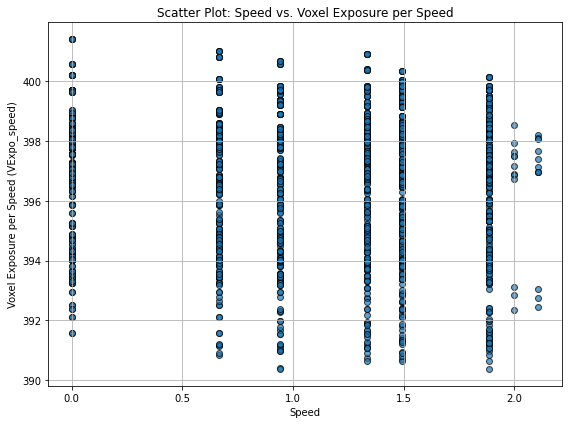

In [4]:
############### speed vs exposure (useless)


import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df
# df = pd.read_csv('your_file.csv')  # Example if you're loading from file

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(summary_v['speed'], summary_v['VExpo_speed'], alpha=0.7, edgecolor='k')
plt.xlabel('Speed')
plt.ylabel('Voxel Exposure per Speed (VExpo_speed)')
plt.title('Scatter Plot: Speed vs. Voxel Exposure per Speed')
plt.grid(True)
plt.tight_layout()
plt.show()


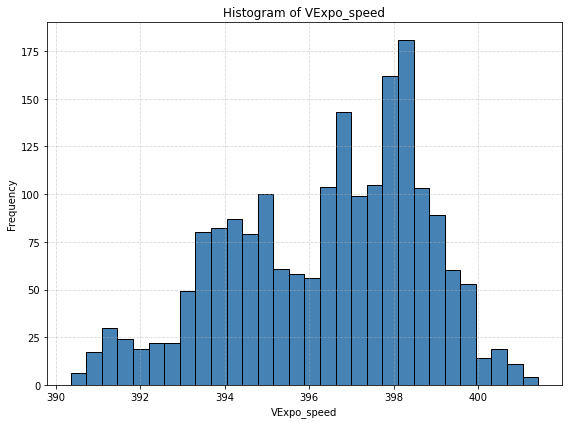

In [8]:
#################histogram of exposure for each speed

import matplotlib.pyplot as plt

# Plot histogram of VExpo_speed from summary_v
plt.figure(figsize=(8, 6))
plt.hist(summary_v['VExpo_speed'], bins=30, color='steelblue', edgecolor='black')
plt.title('Histogram of VExpo_speed')
plt.xlabel('VExpo_speed')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


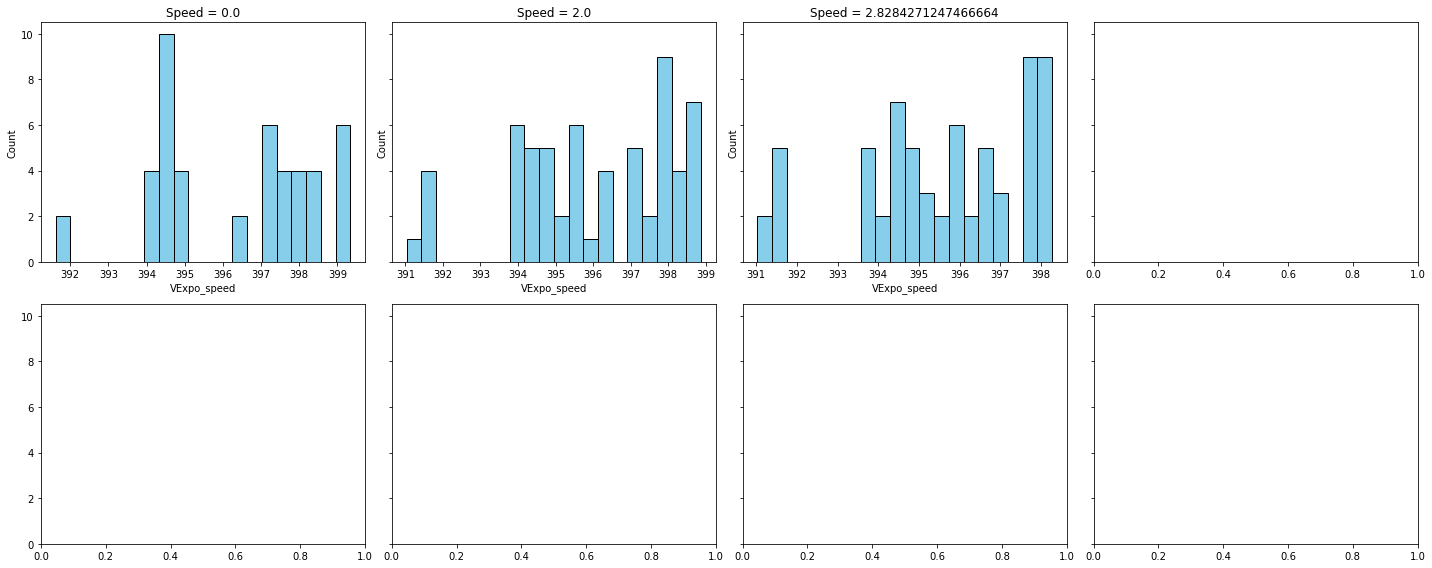

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
unique_speeds = sorted(summary_v['speed'].unique())
n = len(unique_speeds)

# Set up subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 8), sharey=True)
axes = axes.flatten()

for i, speed in enumerate(unique_speeds):
    subset = summary_v[summary_v['speed'] == speed]
    axes[i].hist(subset['VExpo_speed'], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Speed = {speed}')
    axes[i].set_xlabel('VExpo_speed')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()


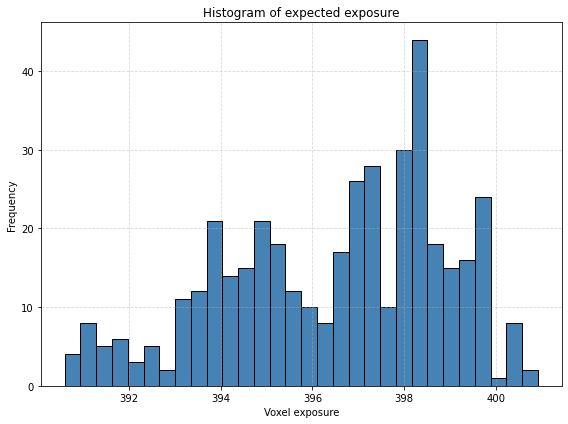

In [5]:
# Plot histogram of VExpo_speed from summary_v
plt.figure(figsize=(8, 6))
plt.hist(all_final_summary_df['VExpo_unweight'], bins=30, color='steelblue', edgecolor='black')
plt.title('Histogram of expected exposure')
plt.xlabel('Voxel exposure')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### sensitivity for single point

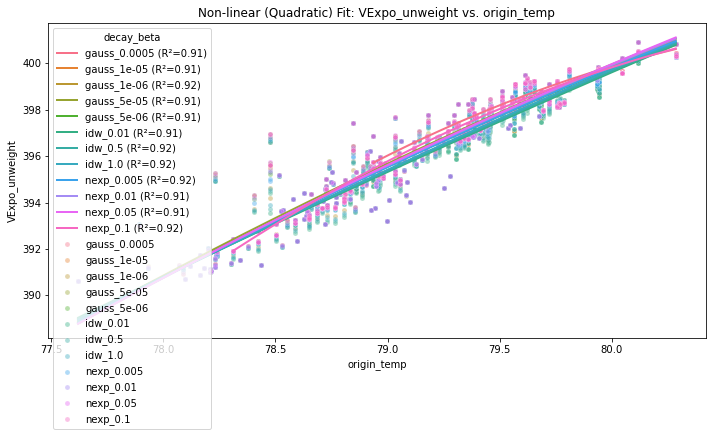

<Figure size 720x432 with 0 Axes>

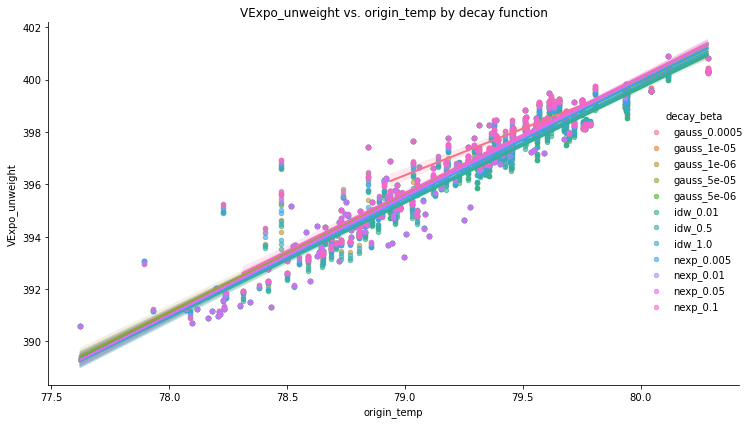

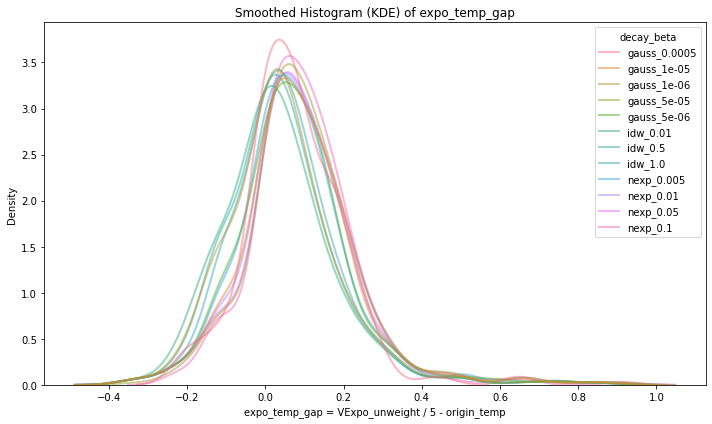

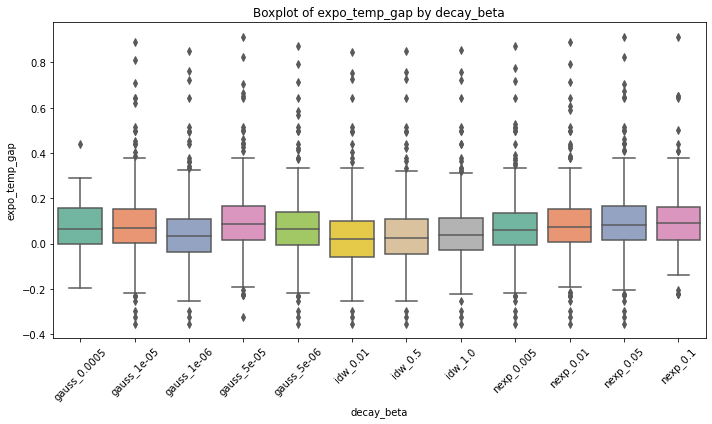

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# === Settings ===
folder_path = r"C:\Users\tokey\OneDrive - The Ohio State University\pyst_test\empirical result\single_point"
pattern = os.path.join(folder_path, "detailed_voxel_output_1533755_*.csv")

# === Load and combine files ===
all_dfs = []
for filepath in glob.glob(pattern):
    filename = os.path.basename(filepath)
    parts = filename.replace(".csv", "").split("_")
    
    cell_size = int(parts[4])
    decay_function = parts[5]
    beta = float(parts[6])
    label = f"{decay_function}_{beta}"
    
    df = pd.read_csv(filepath)
    df["cell_size"] = cell_size
    df["decay_function"] = decay_function
    df["beta"] = beta
    df["decay_beta"] = label
    df["expo_temp_gap"] = df["VExpo_unweight"] / 5.0 - df["origin_temp"]
    
    all_dfs.append(df)

# Combine all into one DataFrame
full_df = pd.concat(all_dfs, ignore_index=True)

# === Quadratic Model ===
def quadratic(x, a, b, c):
    return a * x**2 + b * x + c

# === Plot ===
plt.figure(figsize=(10, 6))
palette = sns.color_palette("husl", len(full_df["decay_beta"].unique()))

for i, (label, group_df) in enumerate(full_df.groupby("decay_beta")):
    x = group_df["origin_temp"].values
    y = group_df["VExpo_unweight"].values
    
    # Scatter points
    sns.scatterplot(x=x, y=y, label=f"{label}", color=palette[i], alpha=0.4, s=25)
    
    # Fit curve
    try:
        popt, _ = curve_fit(quadratic, x, y)
        x_fit = np.linspace(min(x), max(x), 200)
        y_fit = quadratic(x_fit, *popt)
        
        # R²
        y_pred = quadratic(x, *popt)
        r2 = r2_score(y, y_pred)
        
        # Plot curve
        plt.plot(x_fit, y_fit, color=palette[i], linewidth=2, label=f"{label} (R²={r2:.2f})")
    except Exception as e:
        print(f"Fit failed for {label}: {e}")

plt.title("Non-linear (Quadratic) Fit: VExpo_unweight vs. origin_temp")
plt.xlabel("origin_temp")
plt.ylabel("VExpo_unweight")
plt.legend(title="decay_beta")
plt.tight_layout()
plt.show()


# === Plot 1: Scatterplot with fitted lines ===
plt.figure(figsize=(10, 6))
sns.lmplot(
    data=full_df,
    x="origin_temp",
    y="VExpo_unweight",
    hue="decay_beta",
    aspect=1.5,
    height=6,
    scatter_kws={"s": 20, "alpha": 0.6},
    line_kws={"linewidth": 2}
)
plt.title("VExpo_unweight vs. origin_temp by decay function")
plt.tight_layout()
plt.show()

# === Plot 2: Smoothed histogram (KDE) of expo_temp_gap ===
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=full_df,
    x="expo_temp_gap",
    hue="decay_beta",
    fill=False,
    common_norm=False,
    alpha=0.5,
    linewidth=2
)
plt.title("Smoothed Histogram (KDE) of expo_temp_gap")
plt.xlabel("expo_temp_gap = VExpo_unweight / 5 - origin_temp")
plt.tight_layout()
plt.show()

# === Plot 3: Boxplot of expo_temp_gap ===
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=full_df,
    x="decay_beta",
    y="expo_temp_gap",
    palette="Set2"
)
plt.xticks(rotation=45)
plt.title("Boxplot of expo_temp_gap by decay_beta")
plt.tight_layout()
plt.show()


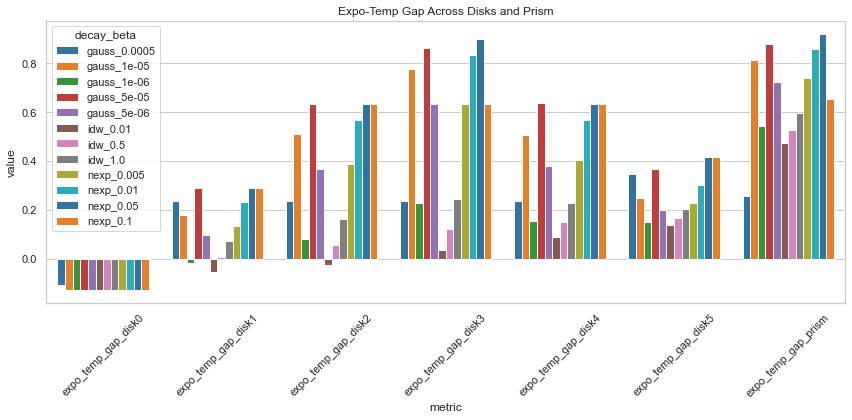

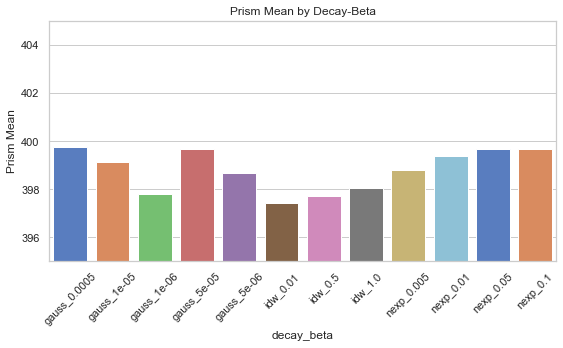

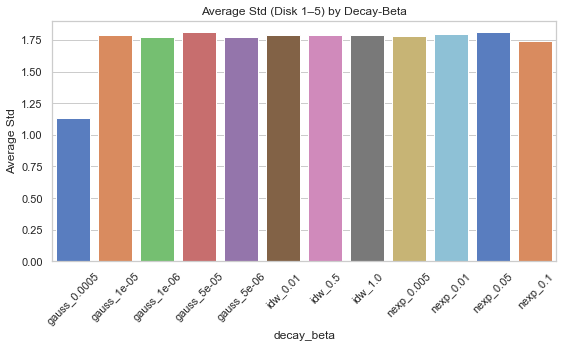

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# === Settings ===
summary_folder = r"C:\Users\tokey\OneDrive - The Ohio State University\pyst_test\empirical result\single_point"  # <- 🔁 Change this
pattern = os.path.join(summary_folder, "summary_1533755_200_*.csv")


summary_rows = []

for filepath in glob.glob(pattern):
    filename = os.path.basename(filepath)
    parts = filename.replace(".csv", "").split("_")
    
    # Extract parameters
    decay_function = parts[3]
    beta = float(parts[4])
    decay_beta = f"{decay_function}_{beta}"
    
    df = pd.read_csv(filepath)
    row = df.iloc[0].copy()
    row["decay_function"] = decay_function
    row["beta"] = beta
    row["decay_beta"] = decay_beta
    
    # Compute expo_temp_gap_disk{i}
    for i in range(6):
        mean_col = f"disk{i}_mean"
        temp_col = f"disk{i}_temp_mean"
        if mean_col in row and temp_col in row:
            row[f"expo_temp_gap_disk{i}"] = row[mean_col] / 5.0 - row[temp_col]
    
    # Compute expo_temp_gap_prism
    if "prism_mean" in row and "disk3_temp_mean" in row:
        row["expo_temp_gap_prism"] = row["prism_mean"] / 5.0 - row["disk3_temp_mean"]
    
    # Compute avg_std from disk1_std to disk5_std
    std_cols = [f"disk{i}_std" for i in range(1, 6) if f"disk{i}_std" in row]
    if std_cols:
        row["avg_std"] = sum([row[col] for col in std_cols]) / len(std_cols)

    summary_rows.append(row)

# === Combine into DataFrame ===
summary_df = pd.DataFrame(summary_rows)

# ========== 1. Expo-Temp Gap Plot ==========
expo_gap_cols = [f"expo_temp_gap_disk{i}" for i in range(6)] + ["expo_temp_gap_prism"]
expo_gap_df = summary_df[["decay_beta"] + expo_gap_cols].melt(id_vars="decay_beta", var_name="metric", value_name="value")

plt.figure(figsize=(12, 6))
sns.barplot(data=expo_gap_df, x="metric", y="value", hue="decay_beta", palette="tab10")
plt.title("Expo-Temp Gap Across Disks and Prism")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ========== 2. Prism Mean Plot ==========
plt.figure(figsize=(8, 5))
sns.barplot(data=summary_df, x="decay_beta", y="prism_mean", palette="muted")
plt.title("Prism Mean by Decay-Beta")
plt.ylabel("Prism Mean")
plt.xticks(rotation=45)
plt.ylim(395, 405) 
plt.tight_layout()
plt.show()

# ========== 3. Avg Std Plot ==========
plt.figure(figsize=(8, 5))
sns.barplot(data=summary_df, x="decay_beta", y="avg_std", palette="muted")
plt.title("Average Std (Disk 1–5) by Decay-Beta")
plt.ylabel("Average Std")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



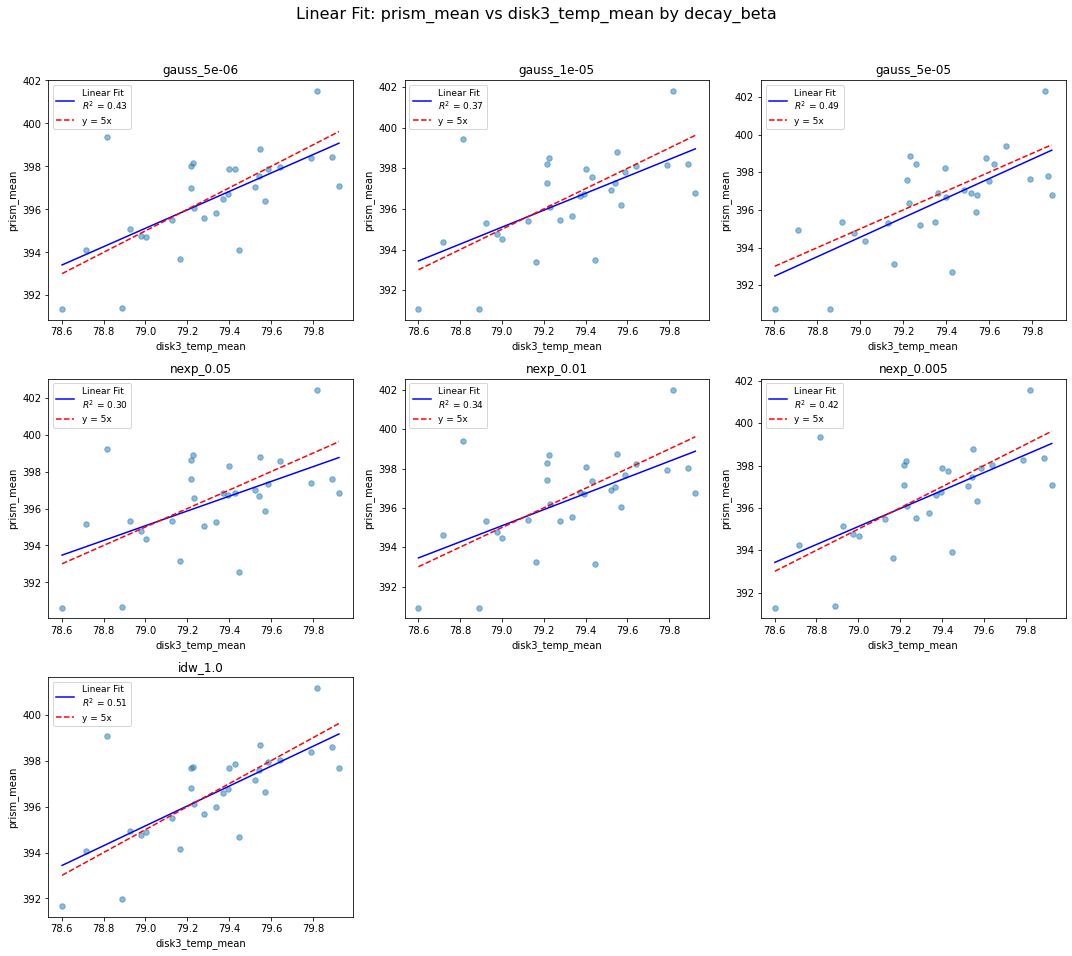

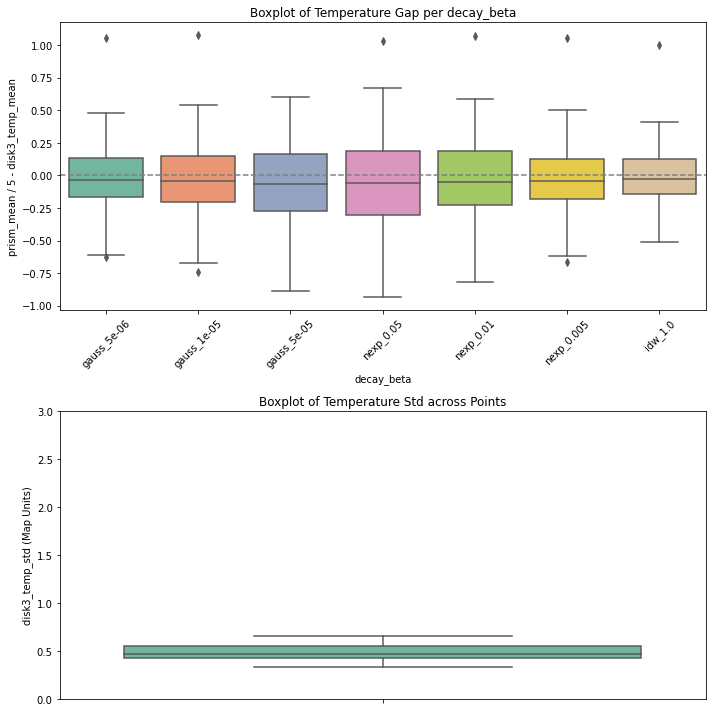

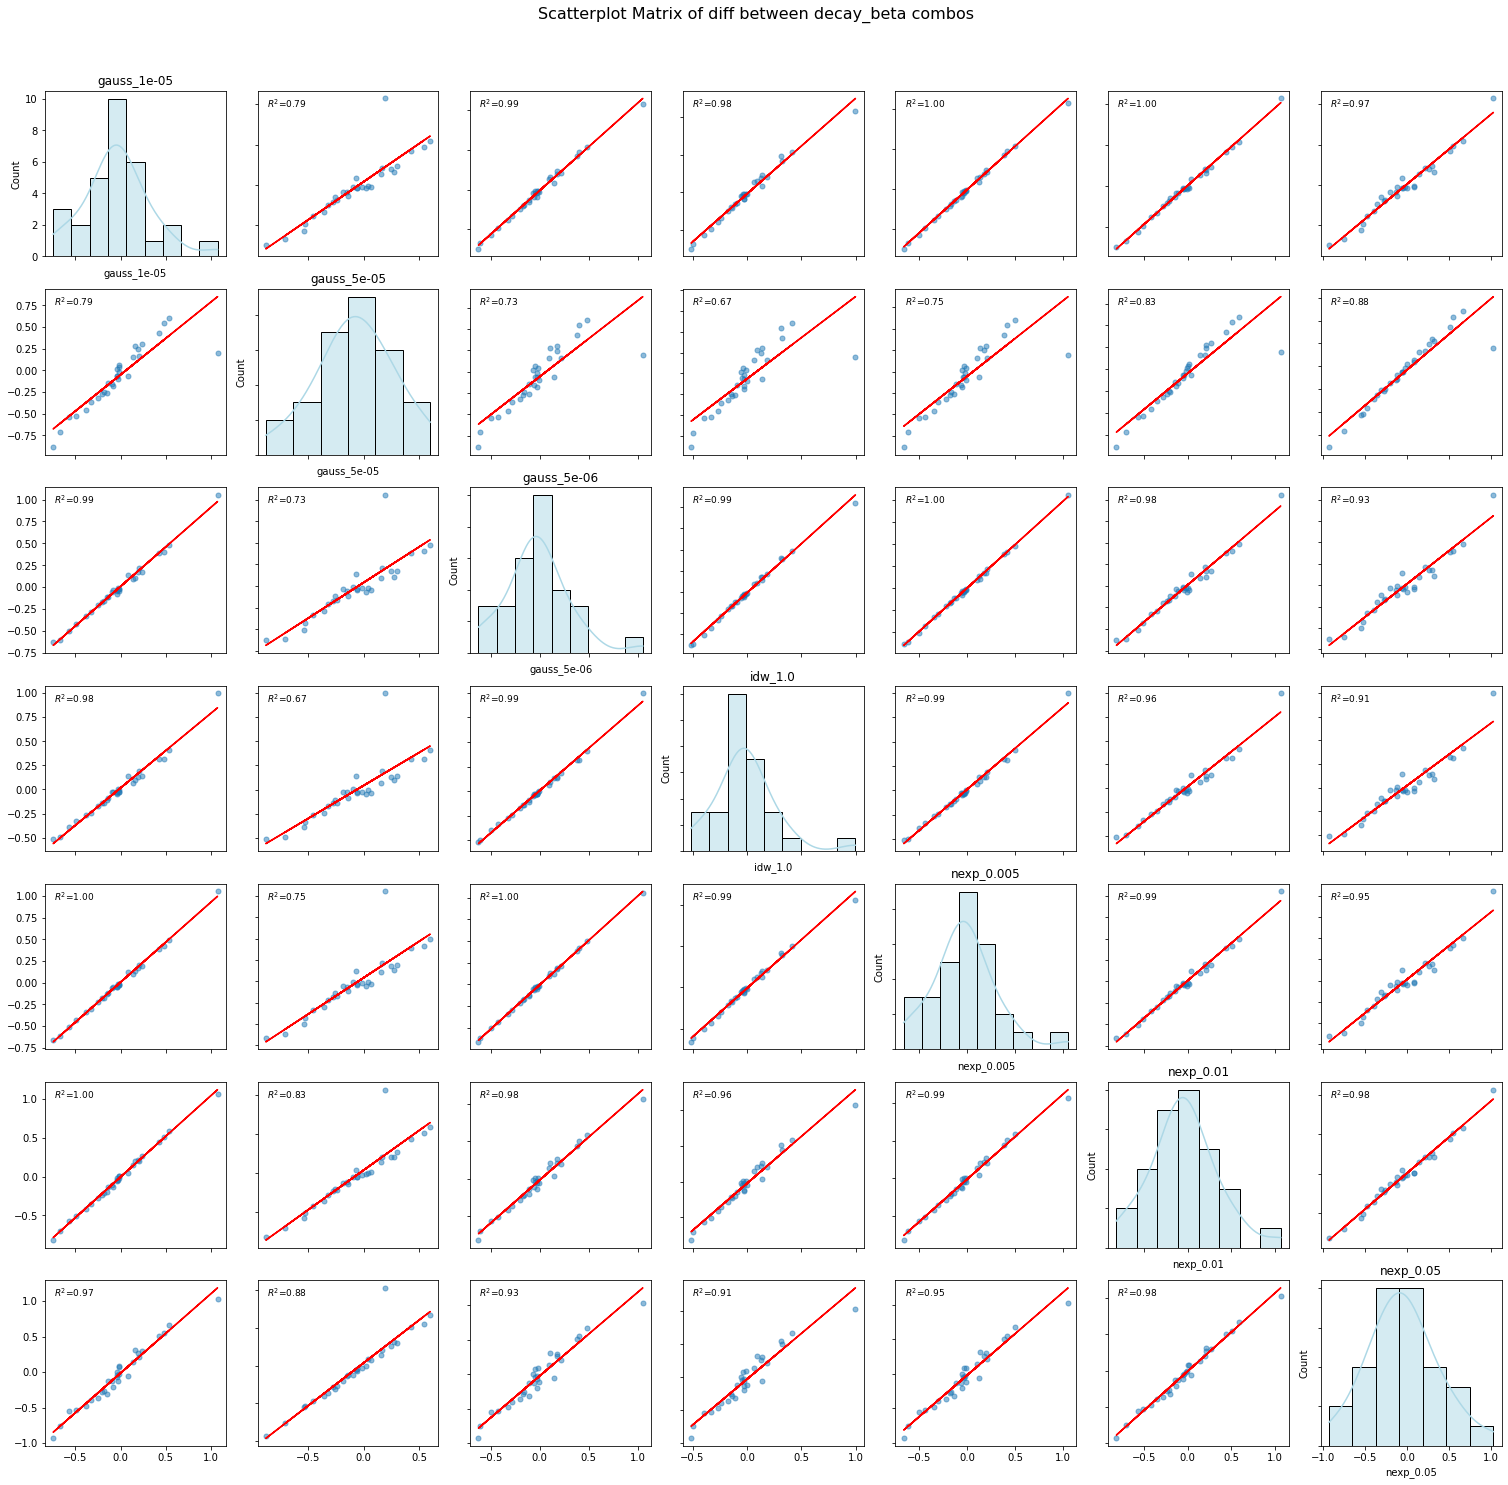

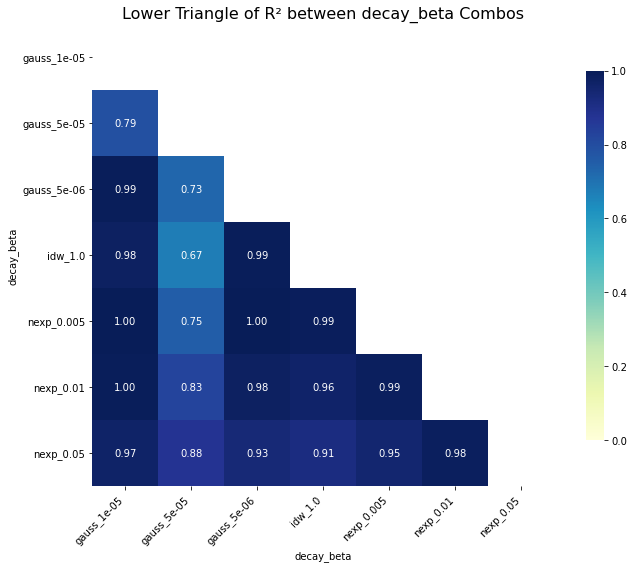

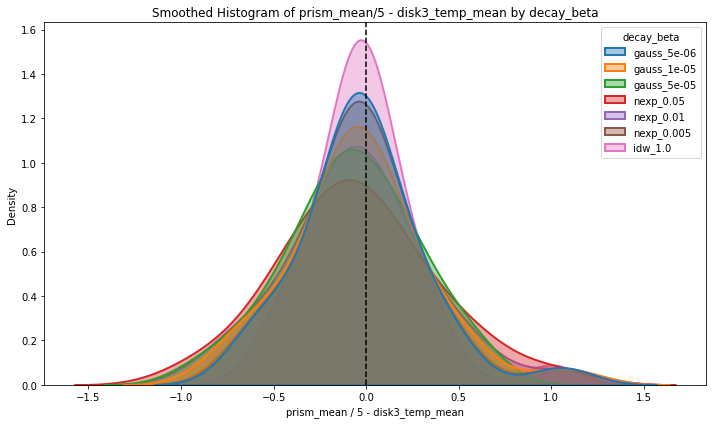

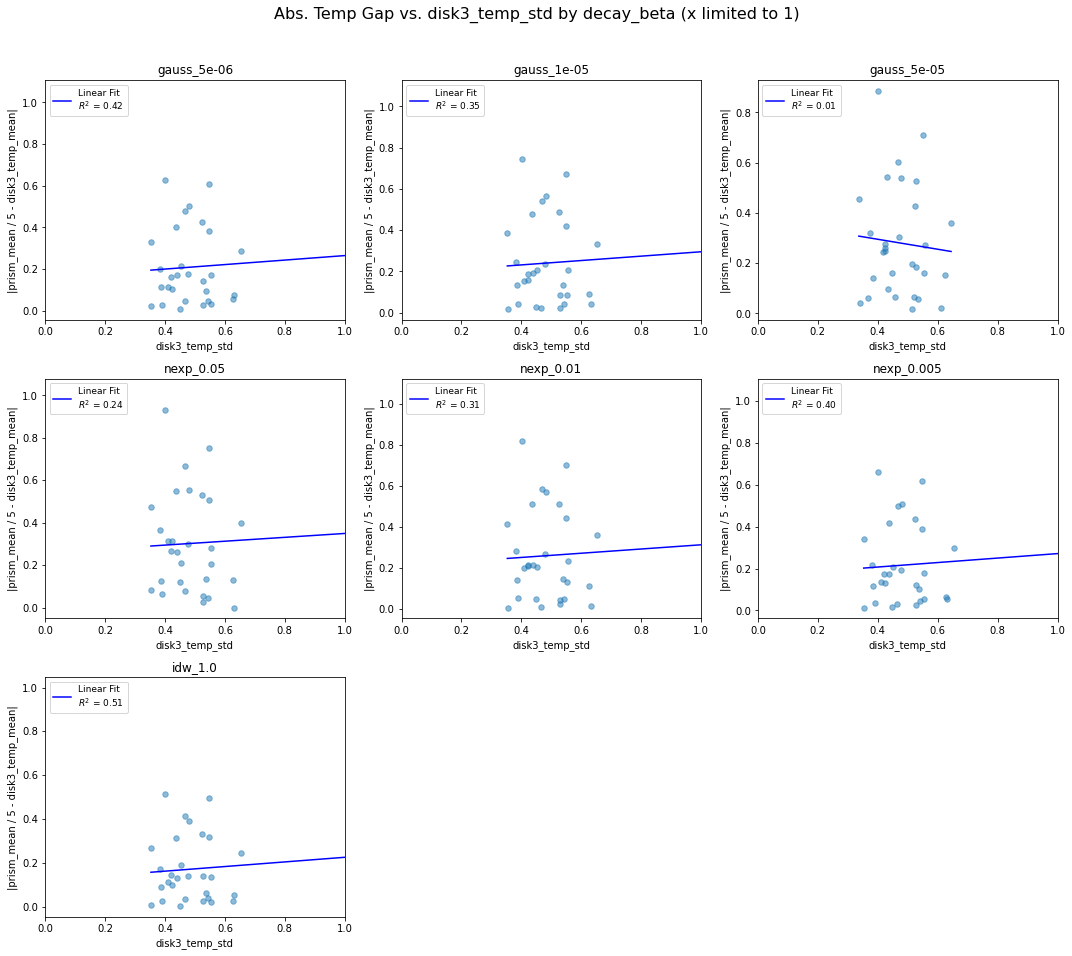

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# === Load Data ===
csv_path = r"C:\Users\tokey\OneDrive - The Ohio State University\pyst_test\empirical result\rand30_gauss\summary_columbusR30_gauss_nexp.csv"
df = pd.read_csv(csv_path)

# === Create decay_beta column ===
df["decay_beta"] = df["decay_function"].astype(str) + "_" + df["beta"].astype(str)

# === Compute difference ===
df["diff"] = df["prism_mean"] / 5.0 - df["disk3_temp_mean"]

# === 1. Scatterplot of expo and temp ===
unique_combos = df["decay_beta"].unique()
n = len(unique_combos)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4.5 * nrows))
axs = axs.flatten()

for i, combo in enumerate(unique_combos):
    sub_df = df[df["decay_beta"] == combo]
    ax = axs[i]

    x = sub_df["disk3_temp_mean"].values.reshape(-1, 1)
    y = sub_df["prism_mean"].values

    # Scatter
    ax.scatter(x, y, alpha=0.5, s=30)

    # Linear regression
    model = LinearRegression().fit(x, y)
    y_pred = model.predict(x)
    r2 = r2_score(y, y_pred)

    # Plot regression line
    x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    y_line = model.predict(x_line)
    ax.plot(x_line, y_line, color="blue", label=f"Linear Fit\n$R^2$ = {r2:.2f}")

    # Reference line y = 5x
    ax.plot(x_line, 5 * x_line, color="red", linestyle="--", label="y = 5x")

    # Labels
    ax.set_title(combo)
    ax.set_xlabel("disk3_temp_mean")
    ax.set_ylabel("prism_mean")
    ax.legend(loc="upper left", fontsize=9)

# Remove extra axes
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.suptitle("Linear Fit: prism_mean vs disk3_temp_mean by decay_beta", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# === 2. Boxplot of difference ===
# Melt the data for long-form plotting
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=False)

# Boxplot of diff by decay_beta
sns.boxplot(data=df, x="decay_beta", y="diff", palette="Set2", ax=axes[0])
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_ylabel("prism_mean / 5 - disk3_temp_mean")
axes[0].set_title("Boxplot of Temperature Gap per decay_beta")
axes[0].tick_params(axis='x', rotation=45)

# Boxplot of disk3_temp_std (just one box)
sns.boxplot(data=df, y="disk3_temp_std", palette="Set2", ax=axes[1])
axes[1].set_ylabel("disk3_temp_std (Map Units)")
axes[1].set_title("Boxplot of Temperature Std across Points")
axes[1].set_ylim(0, 3)

plt.tight_layout()
plt.show()

# === 3. Scatterplot matrix of diff comparisons ===


# Prepare pivoted wide format
pivot_df = df.pivot(index="pointid", columns="decay_beta", values="diff").dropna(axis=1)

# Get column names (decay_beta combos)
combos = pivot_df.columns.tolist()

# Create scatterplot matrix with fitted lines and R²
n = len(combos)
fig, axs = plt.subplots(n, n, figsize=(3 * n, 3 * n))

for i in range(n):
    for j in range(n):
        ax = axs[i, j]
        if i == j:
            sns.histplot(pivot_df[combos[i]], kde=True, ax=ax, color="lightblue")
            ax.set_title(combos[i])
        else:
            x = pivot_df[combos[j]]
            y = pivot_df[combos[i]]
            ax.scatter(x, y, alpha=0.5, s=25)

            # Fit and draw regression line
            slope, intercept = np.polyfit(x, y, 1)
            ax.plot(x, slope * x + intercept, color='red')

            # R² calculation
            corr_matrix = np.corrcoef(x, y)
            r_squared = corr_matrix[0, 1] ** 2
            ax.text(0.05, 0.9, f"$R^2$={r_squared:.2f}", transform=ax.transAxes, fontsize=9)

        if i < n - 1:
            ax.set_xticklabels([])
        if j > 0:
            ax.set_yticklabels([])

plt.suptitle("Scatterplot Matrix of diff between decay_beta combos", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# 3
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Pivot to wide format
pivot_df = df.pivot(index="pointid", columns="decay_beta", values="diff").dropna(axis=1)

# Compute R² matrix (squared correlation)
corr_matrix = pivot_df.corr() ** 2

# Mask the upper triangle including diagonal
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the lower-triangle R² matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="YlGnBu",
            square=True, cbar_kws={"shrink": 0.8}, vmin=0, vmax=1)

plt.title("Lower Triangle of R² between decay_beta Combos", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# === 4. Smoothed histogram (KDE plot) of differences ===
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="diff", hue="decay_beta", fill=True, common_norm=False, alpha=0.4, linewidth=2)
plt.axvline(0, color='black', linestyle='--')
plt.title("Smoothed Histogram of prism_mean/5 - disk3_temp_mean by decay_beta")
plt.xlabel("prism_mean / 5 - disk3_temp_mean")
plt.tight_layout()
plt.show()

# === 5. Scatterplot: disk3_temp_std vs. diff (per decay_beta) ===
# === 5. Scatterplot of disk3_temp_std vs. |diff| with x-axis limited to 1 ===
n = len(unique_combos)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4.5 * nrows))
axs = axs.flatten()

for i, combo in enumerate(unique_combos):
    sub_df = df[df["decay_beta"] == combo]
    ax = axs[i]

    x = sub_df["disk3_temp_std"].values.reshape(-1, 1)
    y = np.abs(sub_df["diff"].values)

    # Scatter
    ax.scatter(x, y, alpha=0.5, s=30)

    # Linear regression
    model = LinearRegression().fit(x, y)
    y_pred = model.predict(x)
    r2 = r2_score(y, y_pred)

    # Regression line
    x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    y_line = model.predict(x_line)
    ax.plot(x_line, y_line, color="blue", label=f"Linear Fit\n$R^2$ = {r2:.2f}")

    # Axes & labels
    ax.set_xlim(0, 1)
    ax.set_title(combo)
    ax.set_xlabel("disk3_temp_std")
    ax.set_ylabel("|prism_mean / 5 - disk3_temp_mean|")
    ax.legend(loc="upper left", fontsize=9)

# Remove unused axes
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.suptitle("Abs. Temp Gap vs. disk3_temp_std by decay_beta (x limited to 1)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



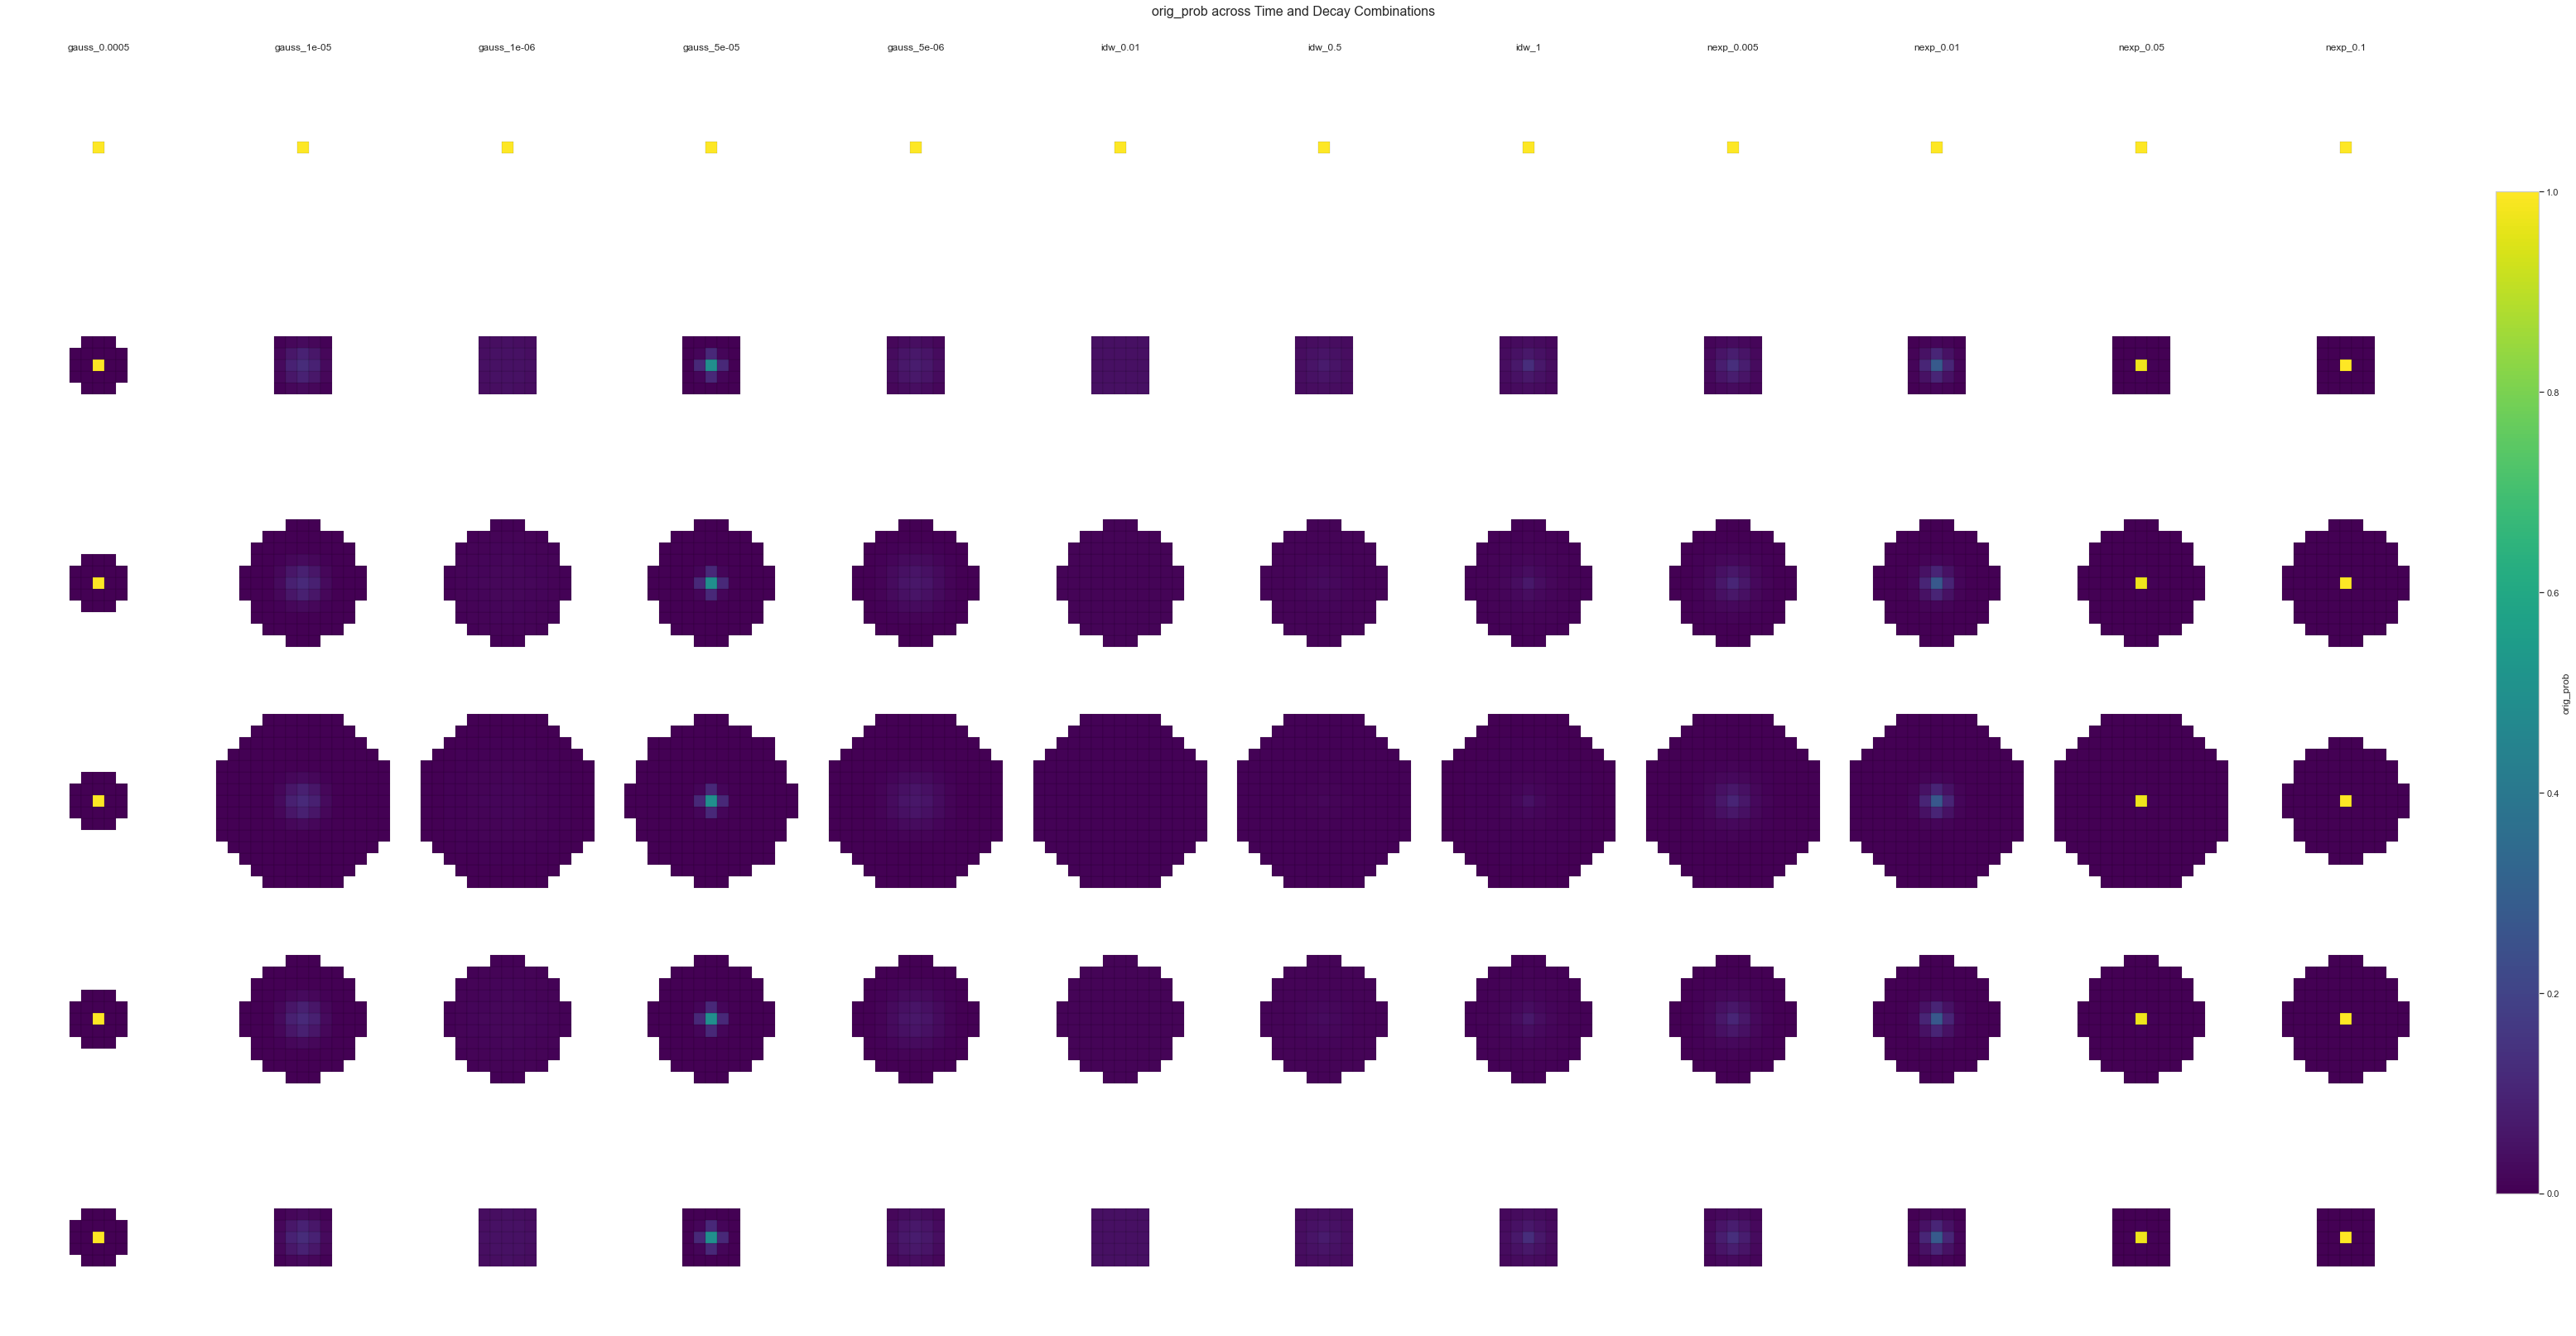

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import glob
import numpy as np

# === Settings ===
folder = r"C:\Users\tokey\OneDrive - The Ohio State University\pyst_test\empirical result\single_point"
pattern = os.path.join(folder, "detailed_voxel_output_1533755_200_*.csv")
variable = "orig_prob"
cell_size = 200  # for constructing square grids (change if needed)

# === Load and stack data ===
all_data = []
for filepath in glob.glob(pattern):
    filename = os.path.basename(filepath)
    parts = filename.replace(".csv", "").split("_")
    decay_function = parts[5]
    beta = parts[6]
    decay_beta = f"{decay_function}_{beta}"
    
    df = pd.read_csv(filepath)
    df["decay_beta"] = decay_beta
    df["X"] = df["Coord"].apply(lambda x: float(x.strip("()").split(",")[0]))
    df["Y"] = df["Coord"].apply(lambda x: float(x.strip("()").split(",")[1]))
    all_data.append(df)

full_df = pd.concat(all_data, ignore_index=True)

# === Prepare plotting grid ===
time_slices = sorted(full_df["timestamp"].unique())
decay_combos = sorted(full_df["decay_beta"].unique())
n_rows = len(time_slices)
n_cols = len(decay_combos)

# Determine global value range for consistent color scale
vmin = full_df[variable].min()
vmax = full_df[variable].max()
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis

# === Compute global extent ===
buffer = cell_size  # optional padding
xmin = full_df["X"].min() - buffer
xmax = full_df["X"].max() + buffer
ymin = full_df["Y"].min() - buffer
ymax = full_df["Y"].max() + buffer

# === Plot panel ===
fig, axs = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
plt.subplots_adjust(left=0.05, right=0.9, top=0.95, bottom=0.05, wspace=0.1, hspace=0.1)

for row_idx, t in enumerate(time_slices):
    for col_idx, decay_beta in enumerate(decay_combos):
        ax = axs[row_idx, col_idx] if n_rows > 1 else axs[col_idx]
        sub_df = full_df[(full_df["timestamp"] == t) & (full_df["decay_beta"] == decay_beta)]

        for _, row in sub_df.iterrows():
            x, y, val = row["X"], row["Y"], row[variable]
            square = plt.Rectangle(
                (x - cell_size / 2, y - cell_size / 2),
                cell_size,
                cell_size,
                color=cmap(norm(val)),
                ec="black",
                linewidth=0.1
            )
            ax.add_patch(square)

        # === Enforce global extent and aspect ratio ===
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect('equal')
        ax.axis("off")

        # === Labels
        if col_idx == 0:
            ax.set_ylabel(t, fontsize=10)
        if row_idx == 0:
            ax.set_title(decay_beta, fontsize=12)

# === Add shared colorbar further right ===
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # (x, y, width, height)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, cax=cbar_ax)
cbar.set_label(variable, fontsize=12)

# === Title & Save
plt.suptitle(f"{variable} across Time and Decay Combinations", fontsize=16)
plt.savefig(os.path.join(folder, f"{variable}_grid_matrix_scaled.png"), dpi=300, bbox_inches="tight")
plt.show()



C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\ipykernel_launcher.py:98: UserWarning: Attempting to set identical left == right == 1.0 results in singular transformations; automatically expanding.
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\ipykernel_launcher.py:98: UserWarning: Attempting to set identical bottom == top == 1.0 results in singular transformations; automatically expanding.
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\ipykernel_launcher.py:99: UserWarning: Use the colorbar set_ticks() method instead.


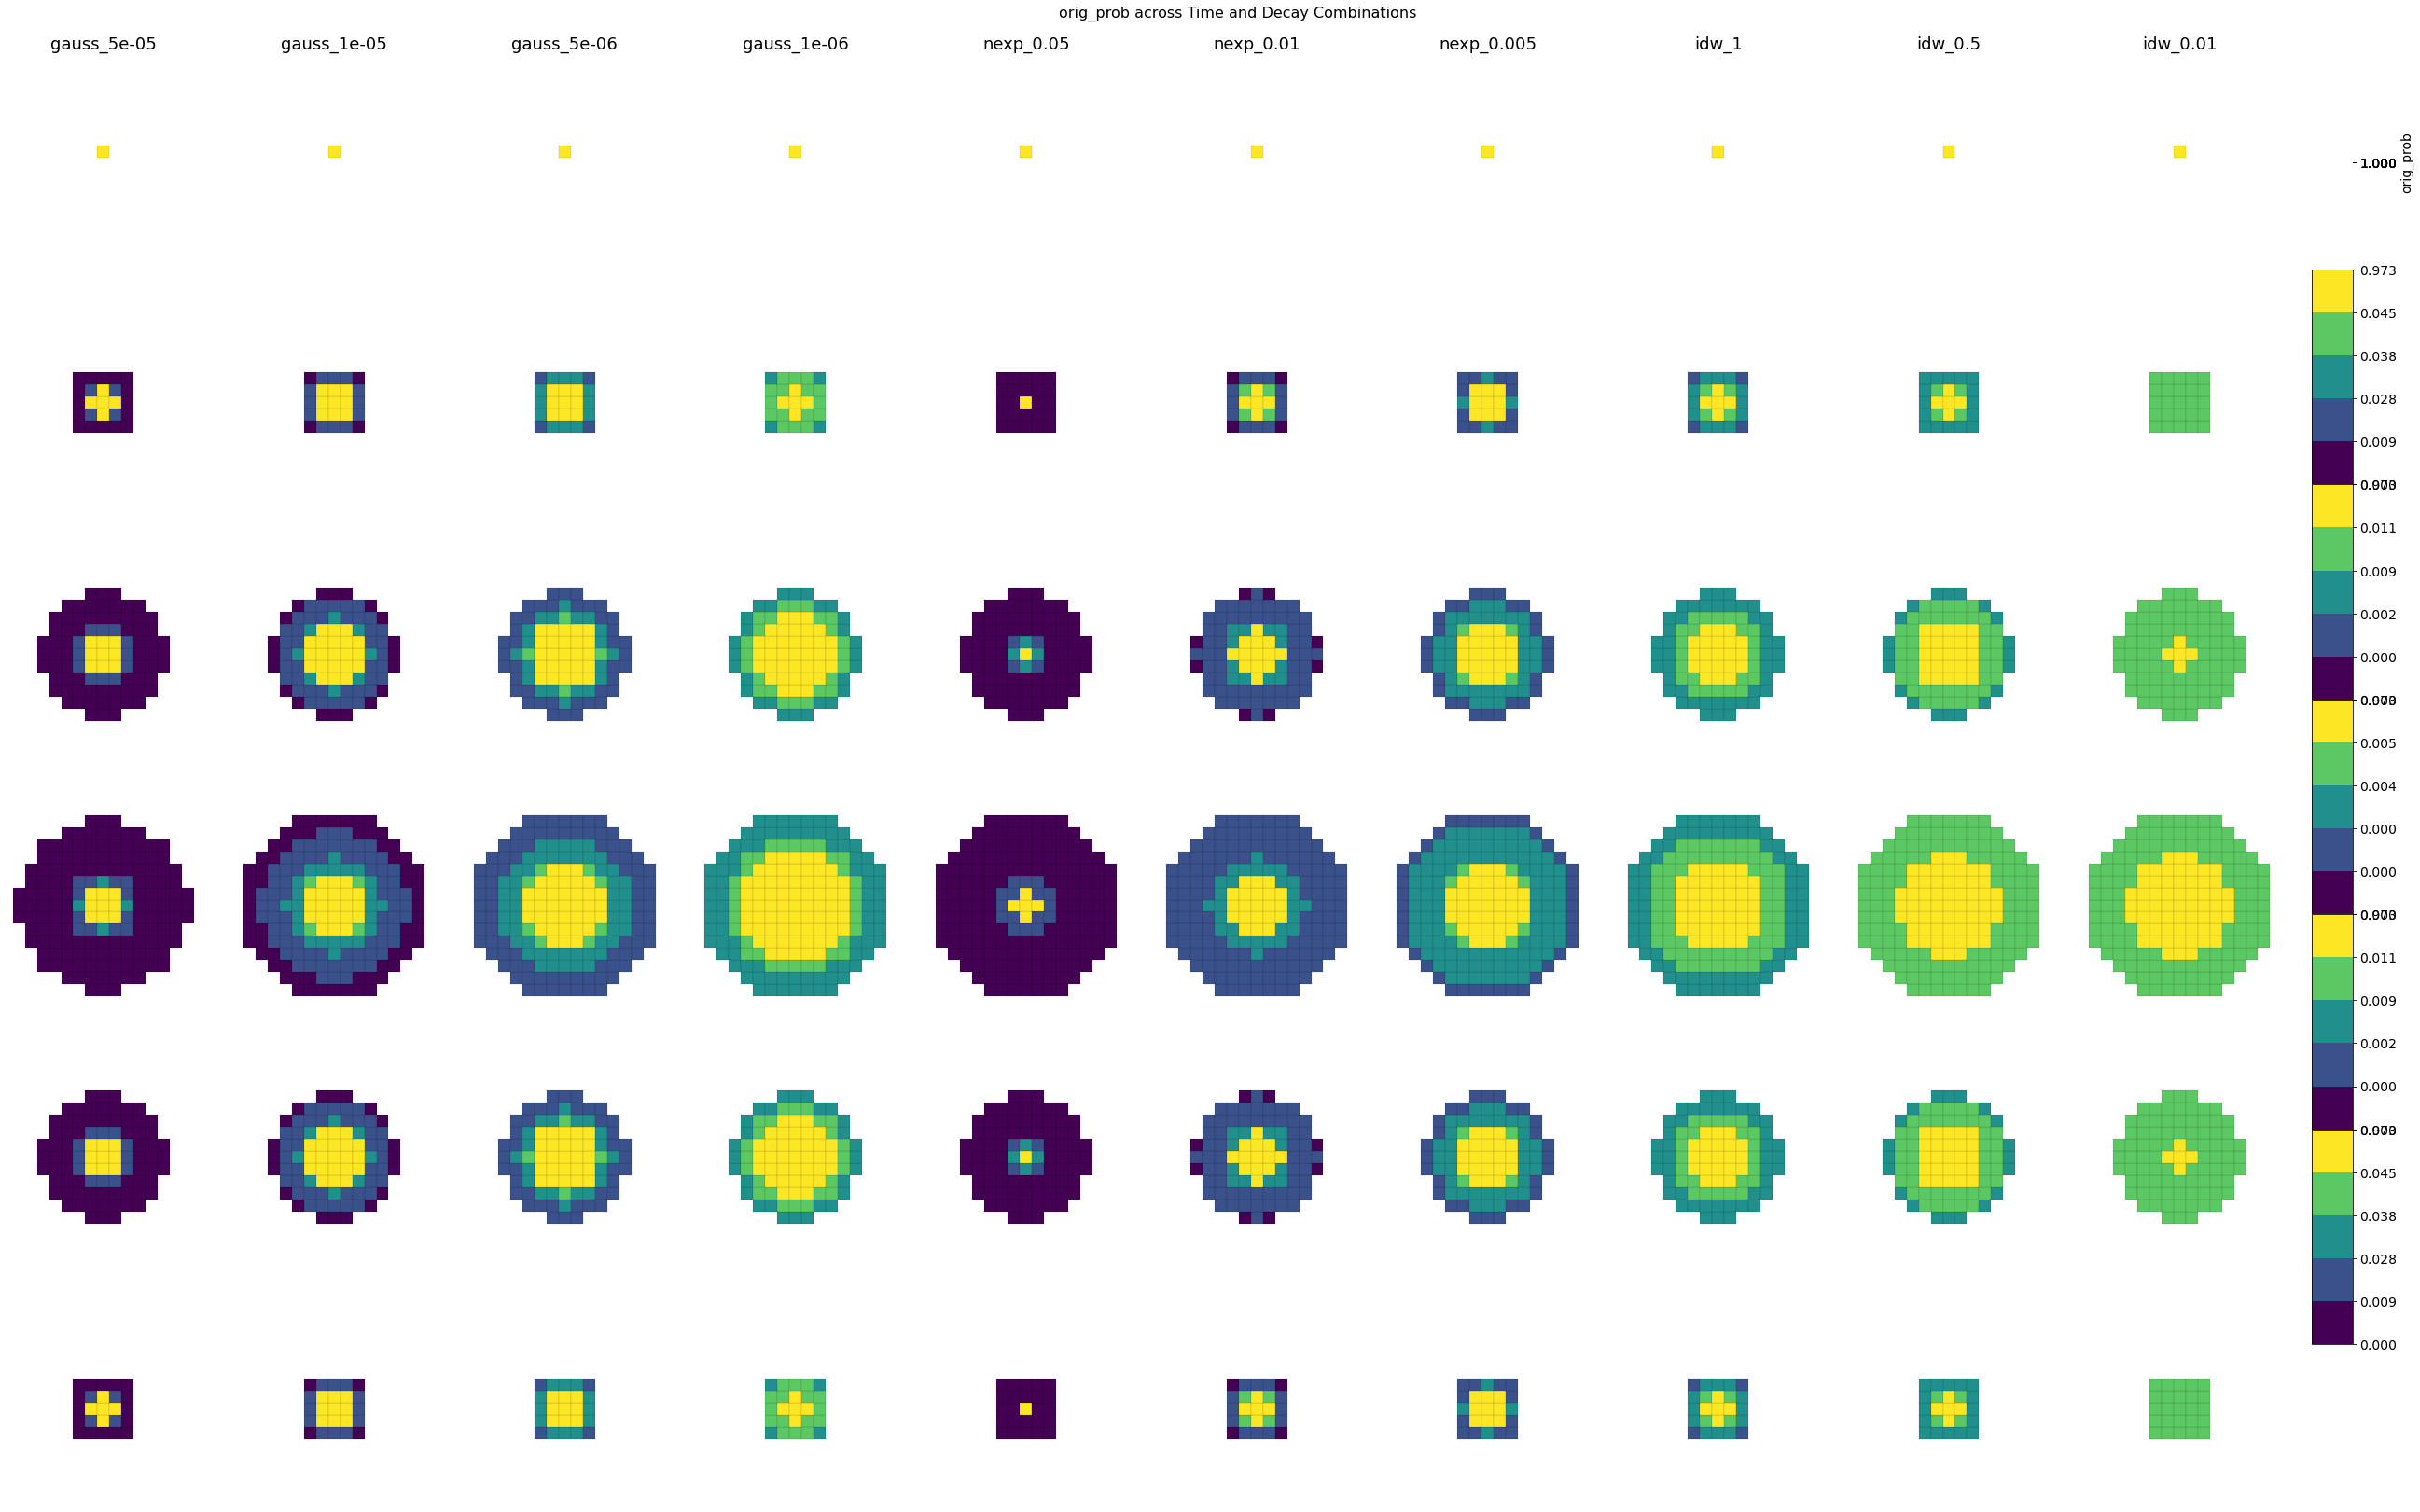

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import glob
import numpy as np

# === Settings ===
folder = r"C:\Users\tokey\OneDrive - The Ohio State University\pyst_test\empirical result\single_point"
pattern = os.path.join(folder, "detailed_voxel_output_1533755_200_*.csv")
variable = "orig_prob"
cell_size = 200  # for constructing square grids (change if needed)
n_bins = 5  # number of quantile bins

# === Load and stack data ===
all_data = []
for filepath in glob.glob(pattern):
    filename = os.path.basename(filepath)
    parts = filename.replace(".csv", "").split("_")
    decay_function = parts[5]
    beta = parts[6]
    decay_beta = f"{decay_function}_{beta}"
    
    df = pd.read_csv(filepath)
    df["decay_beta"] = decay_beta
    df["X"] = df["Coord"].apply(lambda x: float(x.strip("()").split(",")[0]))
    df["Y"] = df["Coord"].apply(lambda x: float(x.strip("()").split(",")[1]))
    all_data.append(df)

full_df = pd.concat(all_data, ignore_index=True)

# === Prepare plotting grid ===
time_slices = sorted(full_df["timestamp"].unique())
desired_order = [
    "gauss_5e-05", "gauss_1e-05", "gauss_5e-06", "gauss_1e-06",
    "nexp_0.05", "nexp_0.01", "nexp_0.005",
    "idw_1", "idw_0.5", "idw_0.01"
]
# Keep only combos that are in the data
decay_combos = [combo for combo in desired_order if combo in full_df["decay_beta"].unique()]

n_rows = len(time_slices)
n_cols = len(decay_combos)

# === Compute quantile-based breaks and color normalization ===
quantile_edges = np.quantile(full_df[variable].dropna(), q=np.linspace(0, 1, n_bins + 1))
cmap = plt.cm.viridis
norm = mcolors.BoundaryNorm(boundaries=quantile_edges, ncolors=cmap.N)

# === Compute global extent ===
buffer = cell_size  # optional padding
xmin = full_df["X"].min() - buffer
xmax = full_df["X"].max() + buffer
ymin = full_df["Y"].min() - buffer
ymax = full_df["Y"].max() + buffer

# === Plot panel with separate colorbars per row ===
fig, axs = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols + 1, 4 * n_rows))
plt.subplots_adjust(left=0.05, right=0.88, top=0.95, bottom=0.05, wspace=0.1, hspace=0.3)

for row_idx, t in enumerate(time_slices):
    row_df = full_df[full_df["timestamp"] == t]

    # Compute quantiles for this time slice
    quantile_edges = np.quantile(row_df[variable].dropna(), q=np.linspace(0, 1, n_bins + 1))
    norm = mcolors.BoundaryNorm(boundaries=quantile_edges, ncolors=cmap.N)

    for col_idx, decay_beta in enumerate(decay_combos):
        ax = axs[row_idx, col_idx] if n_rows > 1 else axs[col_idx]
        sub_df = row_df[row_df["decay_beta"] == decay_beta]

        for _, row in sub_df.iterrows():
            x, y, val = row["X"], row["Y"], row[variable]
            color = cmap(norm(val)) if not pd.isna(val) else (1, 1, 1, 0)
            square = plt.Rectangle(
                (x - cell_size / 2, y - cell_size / 2),
                cell_size,
                cell_size,
                color=color,
                ec="black",
                linewidth=0.1
            )
            ax.add_patch(square)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect('equal')
        ax.axis("off")

        if col_idx == 0:
            ax.set_ylabel(t, fontsize=18)
        if row_idx == 0:
            ax.set_title(decay_beta, fontsize=18)

    # === Per-row colorbar
    cbar_ax = fig.add_axes([0.89, 0.15 + (n_rows - 1 - row_idx) * (0.8 / n_rows), 0.015, 0.8 / n_rows])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(sm, cax=cbar_ax)
    cbar.ax.set_yticks(quantile_edges)
    cbar.ax.set_yticklabels([f"{q:.3f}" for q in quantile_edges], fontsize=14)
    if row_idx == 0:
        cbar.set_label(variable, fontsize=14)


# === Add shared quantile-based colorbar ===
""""
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, cax=cbar_ax)
cbar.set_label(variable, fontsize=14)
cbar.ax.set_yticks(quantile_edges)
cbar.ax.set_yticklabels([f"{q:.3f}" for q in quantile_edges])
"""
# === Title & Save ===
plt.suptitle(f"{variable} across Time and Decay Combinations", fontsize=16)
plt.savefig(os.path.join(folder, f"{variable}_grid_matrix_quantile.png"), dpi=300, bbox_inches="tight")
plt.show()


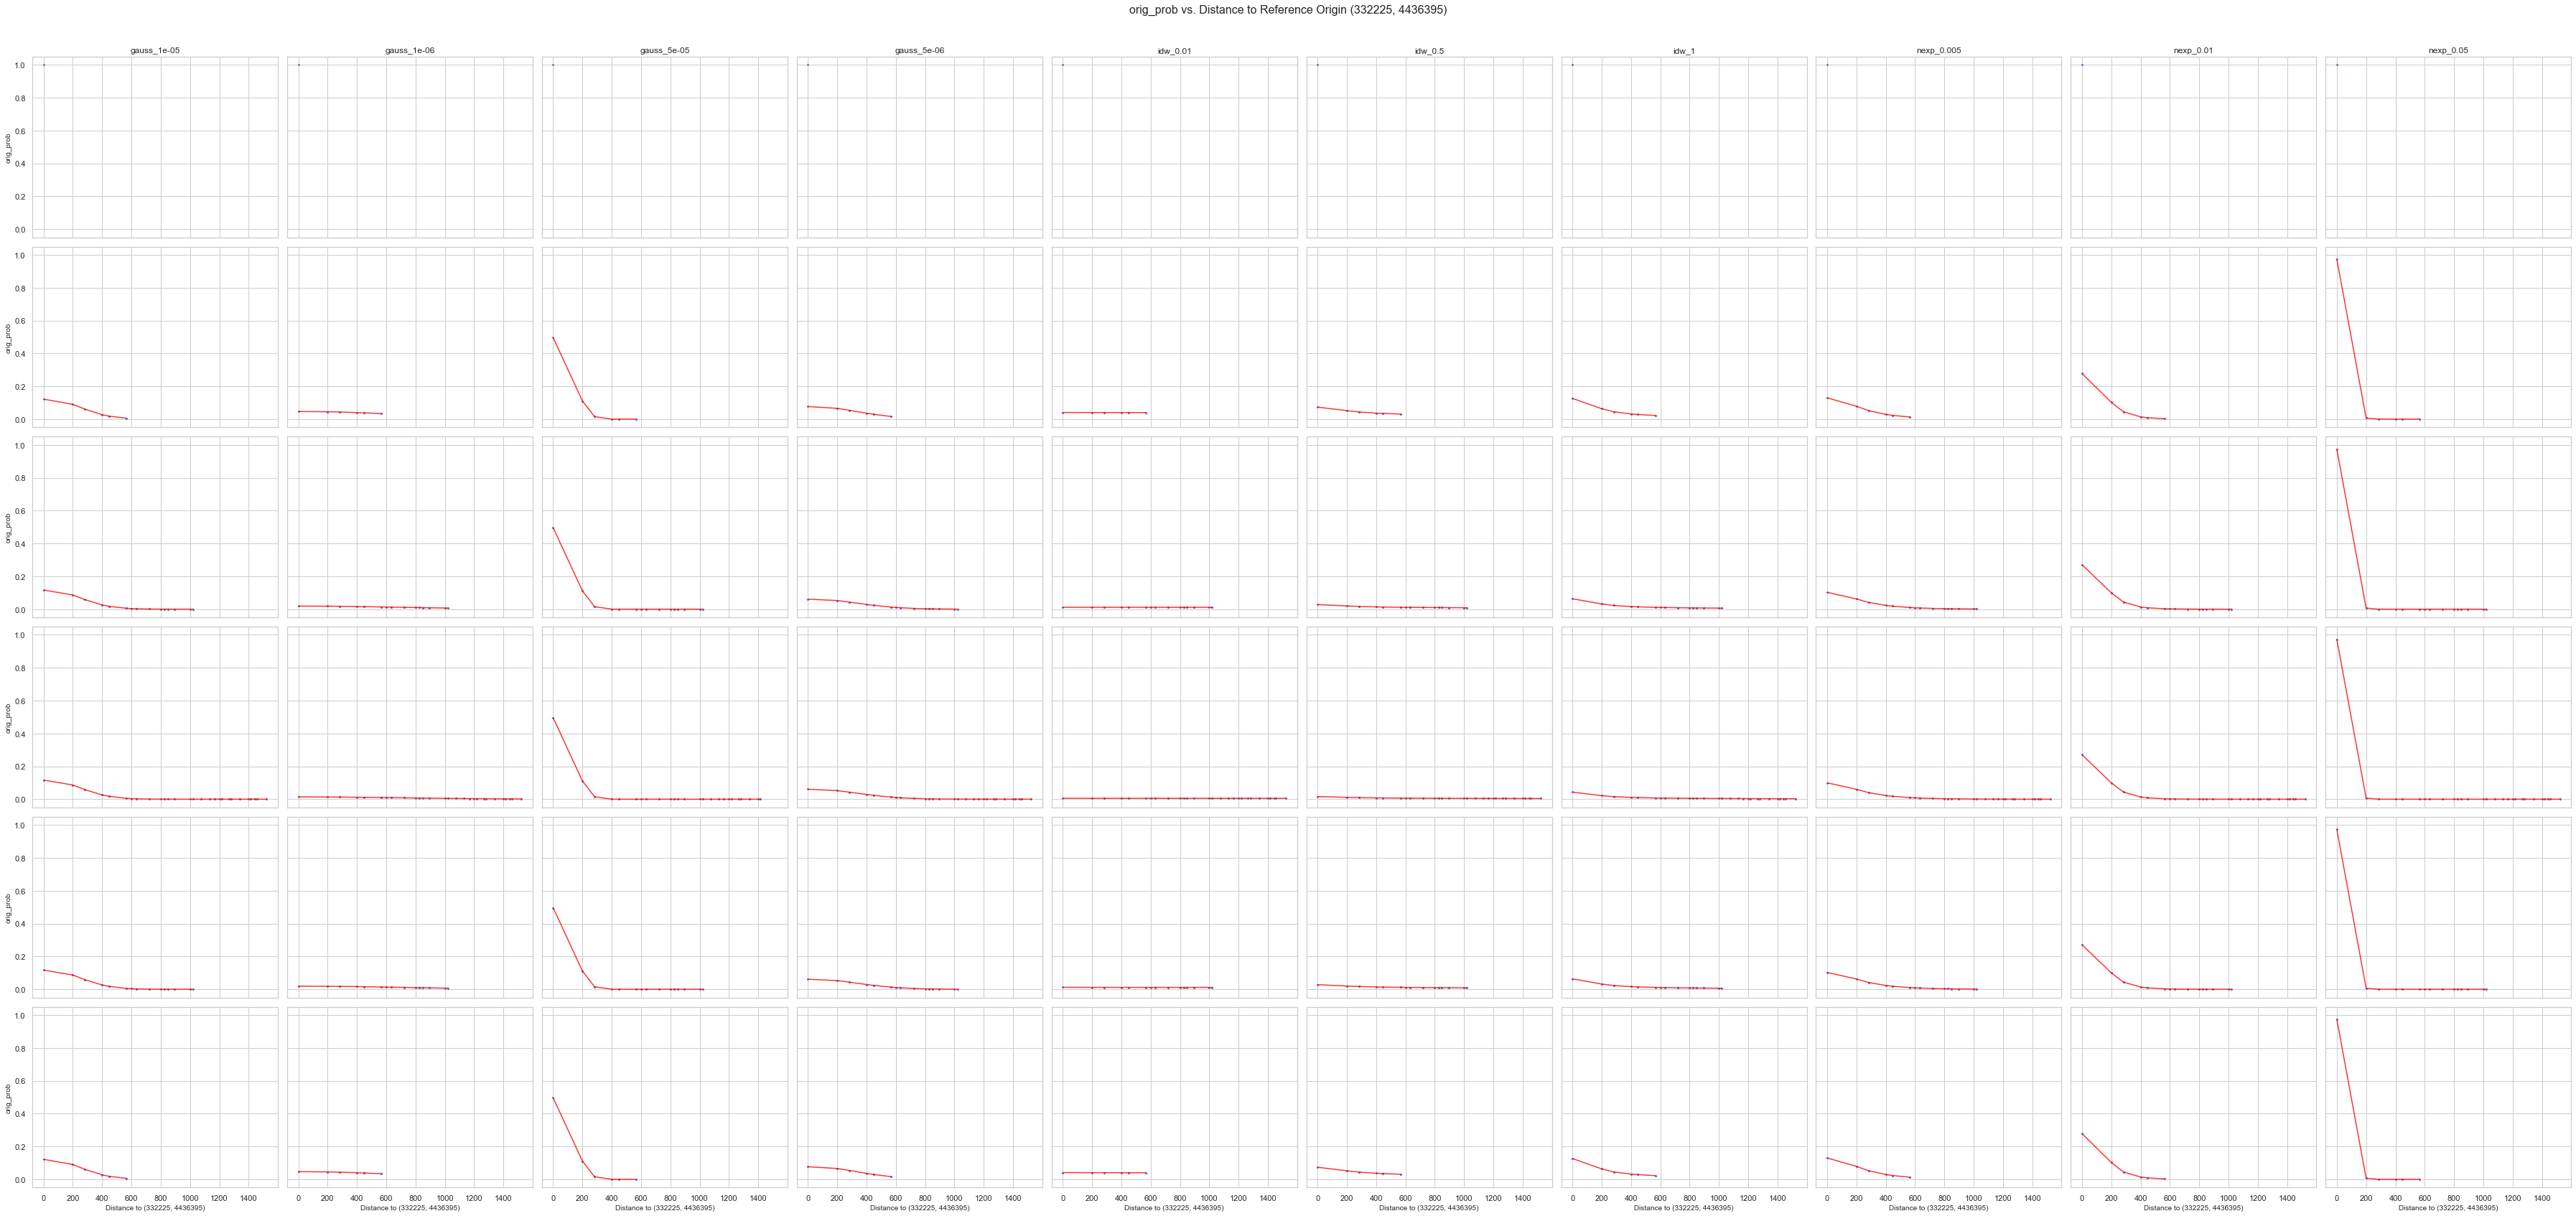

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import numpy as np

# === Settings ===
folder = r"C:\Users\tokey\OneDrive - The Ohio State University\pyst_test\empirical result\single_point"
pattern = os.path.join(folder, "detailed_voxel_output_1533755_200_*.csv")
variable = "orig_prob"
reference_point = (332225.0, 4436395.0)  # <-- your fixed reference point

# === Load and process data ===
all_data = []
for filepath in glob.glob(pattern):
    filename = os.path.basename(filepath)
    parts = filename.replace(".csv", "").split("_")
    decay_function = parts[5]
    beta = parts[6]
    decay_beta = f"{decay_function}_{beta}"

    df = pd.read_csv(filepath)

    # Extract originID coordinates and compute distance to reference point
    def extract_coords(coord_str):
        return tuple(map(float, coord_str.strip("()").split(",")))

    df["origin_xy"] = df["originID"].apply(extract_coords)
    df["distance_to_fixed"] = df["origin_xy"].apply(
        lambda xy: np.linalg.norm(np.array(xy) - np.array(reference_point))
    )

    df["decay_beta"] = decay_beta
    all_data.append(df)

full_df = pd.concat(all_data, ignore_index=True)

# === Prepare grid ===
time_slices = sorted(full_df["timestamp"].unique())
decay_combos = sorted(full_df["decay_beta"].unique())
n_rows = len(time_slices)
n_cols = len(decay_combos)

# === Plotting ===
fig, axs = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.3, wspace=0.2)

for row_idx, ts in enumerate(time_slices):
    for col_idx, decay_beta in enumerate(decay_combos):
        ax = axs[row_idx, col_idx] if n_rows > 1 else axs[col_idx]
        sub_df = full_df[(full_df["timestamp"] == ts) & (full_df["decay_beta"] == decay_beta)]

        # Scatter plot with optional smoothing
        sns.scatterplot(data=sub_df, x="distance_to_fixed", y=variable, ax=ax, s=10, alpha=1)
        # Sort by distance before line plot
        sorted_df = sub_df.sort_values("distance_to_fixed")

        ax.plot(
            sorted_df["distance_to_fixed"],
            sorted_df[variable],
            color="red",
            linewidth=1.5,
            alpha=0.8,
            label="Connected line"
        )


        if row_idx == 0:
            ax.set_title(decay_beta, fontsize=12)
        if col_idx == 0:
            ax.set_ylabel(f"{ts}", fontsize=10)

        ax.set_xlabel("") if row_idx < n_rows - 1 else ax.set_xlabel("Distance to (332225, 4436395)", fontsize=10)
        ax.set_ylabel("") if col_idx > 0 else ax.set_ylabel("orig_prob", fontsize=10)

# === Save and show
plt.suptitle("orig_prob vs. Distance to Reference Origin (332225, 4436395)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(os.path.join(folder, "orig_prob_vs_fixed_origin.png"), dpi=300)
plt.show()


#### check  individual origin

In [18]:

# 1. Find an originID present in all timestamps
origin_counts = summary.groupby("originID")["timestamp"].nunique()
total_timestamps = summary["timestamp"].nunique()
common_origins = origin_counts[origin_counts == (total_timestamps-1)].index

# Just pick the first one that satisfies the condition
origin_to_plot = common_origins[2] if len(common_origins) > 0 else None

origin_to_plot
filtered = summary[summary["originID"] == origin_to_plot]

In [19]:
############# function to export destinations for an origin
import arcpy
import pandas as pd

def export_by_timestamp_in_memory(filtered, grid_shapefile):
    arcpy.env.overwriteOutput = True
    arcpy.env.workspace = "in_memory"

    # Clean destinationID for matching with grid
    filtered = filtered.copy()
    filtered["destination_clean"] = filtered["destinationID"].astype(str).str.strip("()").str.replace(" ", "").str.replace(",", ",")

    # Make feature layer of grid
    grid_layer = "grid_layer"
    arcpy.MakeFeatureLayer_management(grid_shapefile, grid_layer)

    # Dictionary to store in-memory feature layers for each timestamp
    timestamp_layers = {}

    for timestamp, group in filtered.groupby("timestamp"):
        group = group.copy()
        group["join_key"] = group["destination_clean"]

        # Select matching features using Centroid field
        coords = group["join_key"].unique()
        where_clause = " OR ".join([f"Centroid = '{c}'" for c in coords])
        arcpy.SelectLayerByAttribute_management(grid_layer, "NEW_SELECTION", where_clause)

        # Copy to in-memory feature class
        layer_name = f"layer_{str(timestamp).replace(':','_').replace(' ','_')}"
        memory_fc = f"in_memory\\{layer_name}"
        arcpy.CopyFeatures_management(grid_layer, memory_fc)

        # Add join_key to polygon layer for join
        arcpy.AddField_management(memory_fc, "join_key", "TEXT")
        with arcpy.da.UpdateCursor(memory_fc, ["Centroid", "join_key"]) as cursor:
            for row in cursor:
                row[1] = row[0].replace(" ", "")
                cursor.updateRow(row)

        # Create in-memory table from group DataFrame
        table_fields = ["join_key"] + [col for col in group.columns if col not in ["timestamp", "destinationID", "destination_clean"]]
        memory_table = f"in_memory\\table_{layer_name}"
        group[table_fields].to_csv("temp_join.csv", index=False)  # still need temp CSV to use TableToTable
        arcpy.TableToTable_conversion("temp_join.csv", "in_memory", f"table_{layer_name}")

        # Join fields
        arcpy.JoinField_management(memory_fc, "join_key", memory_table, "join_key")

        # Store result
        timestamp_layers[timestamp] = memory_fc

    # Clean up base layer
    arcpy.Delete_management(grid_layer)

    return timestamp_layers


# Example usage
grid_shapefile = r'C:\study\1_OSU\harvey\pyst_test\temperature\mean_200m_af_2.shp'  # param 8

layer_dict = export_by_timestamp_in_memory(filtered, grid_shapefile)


In [159]:
layer_dict

{'2022_08_12_15_05_00': 'in_memory\\layer_2022_08_12_15_05_00',
 '2022_08_12_15_10_00': 'in_memory\\layer_2022_08_12_15_10_00',
 '2022_08_12_15_15_00': 'in_memory\\layer_2022_08_12_15_15_00',
 '2022_08_12_15_20_00': 'in_memory\\layer_2022_08_12_15_20_00',
 '2022_08_12_15_25_00': 'in_memory\\layer_2022_08_12_15_25_00'}

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\IPython\core\interactiveshell.py:3437: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\IPython\core\interactiveshell.py:3437: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\IPython\core\interactiveshell.py:3437: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\IPython\core\interactiveshell.py:3437: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\IPython\core\interactiveshell.py:3437: RankWarning: Polyfit may be p

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\IPython\core\interactiveshell.py:3437: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\IPython\core\interactiveshell.py:3437: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\IPython\core\interactiveshell.py:3437: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\IPython\core\interactiveshell.py:3437: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\IPython\core\interactiveshell.py:3437: RankWarning: Polyfit may be p

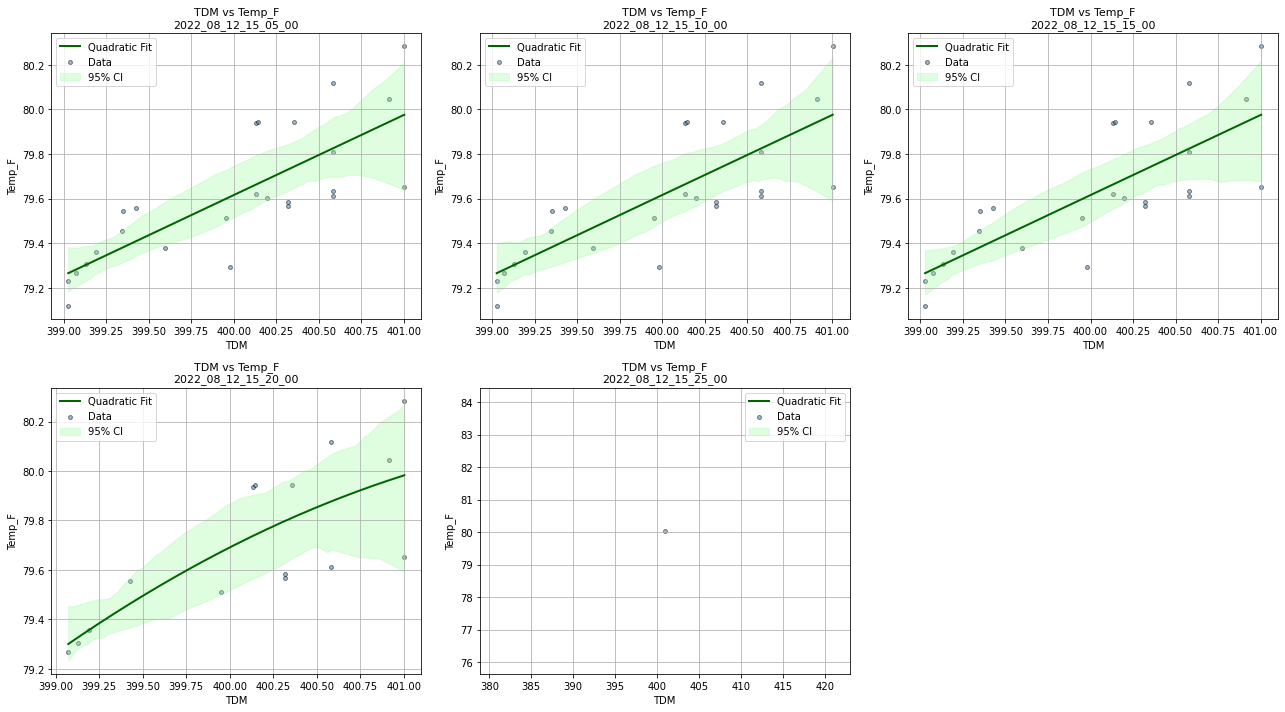

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import arcpy
from sklearn.utils import resample  # for bootstrapping CI

fig2, axs2 = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axs2 = axs2.flatten()
timestamps = sorted(layer_dict.keys())

for i, ts in enumerate(timestamps[:6]):
    shp_path = layer_dict[ts]
    tdm_vals = []
    temp_vals = []

    if arcpy.Exists(shp_path):
        with arcpy.da.SearchCursor(shp_path, ["TDM", "Temp_F"]) as cursor:
            for row in cursor:
                tdm, temp = row
                if tdm is not None and temp is not None:
                    tdm_vals.append(tdm)
                    temp_vals.append(temp)

        tdm_vals = np.array(tdm_vals)
        temp_vals = np.array(temp_vals)
        ax = axs2[i]
        ax.scatter(tdm_vals, temp_vals, s=15, alpha=0.5, color="steelblue", label="Data", edgecolor='k')

        # Fit a 2nd-degree polynomial (quadratic)
        coeffs = np.polyfit(tdm_vals, temp_vals, deg=2)
        poly = np.poly1d(coeffs)
        x_vals = np.linspace(min(tdm_vals), max(tdm_vals), 200)
        y_fit = poly(x_vals)

        ax.plot(x_vals, y_fit, color="darkgreen", lw=2, label="Quadratic Fit")

        # Bootstrap-based 95% confidence interval
        n_boot = 200
        y_boot = np.empty((n_boot, len(x_vals)))
        for b in range(n_boot):
            x_samp, y_samp = resample(tdm_vals, temp_vals)
            c = np.polyfit(x_samp, y_samp, deg=2)
            y_boot[b, :] = np.poly1d(c)(x_vals)
        y_lower = np.percentile(y_boot, 2.5, axis=0)
        y_upper = np.percentile(y_boot, 97.5, axis=0)
        ax.fill_between(x_vals, y_lower, y_upper, color='palegreen', alpha=0.3, label="95% CI")

        ax.set_title(f"TDM vs Temp_F\n{ts}", fontsize=11)
        ax.set_xlabel("TDM")
        ax.set_ylabel("Temp_F")
        ax.legend()
        ax.grid(True)
    else:
        axs2[i].set_title(f"{ts} (Shapefile not found)")
        axs2[i].axis('off')

# Hide unused subplots
for j in range(len(timestamps), len(axs2)):
    axs2[j].axis('off')

plt.tight_layout()
plt.show()


ValueError: Axis limits cannot be NaN or Inf

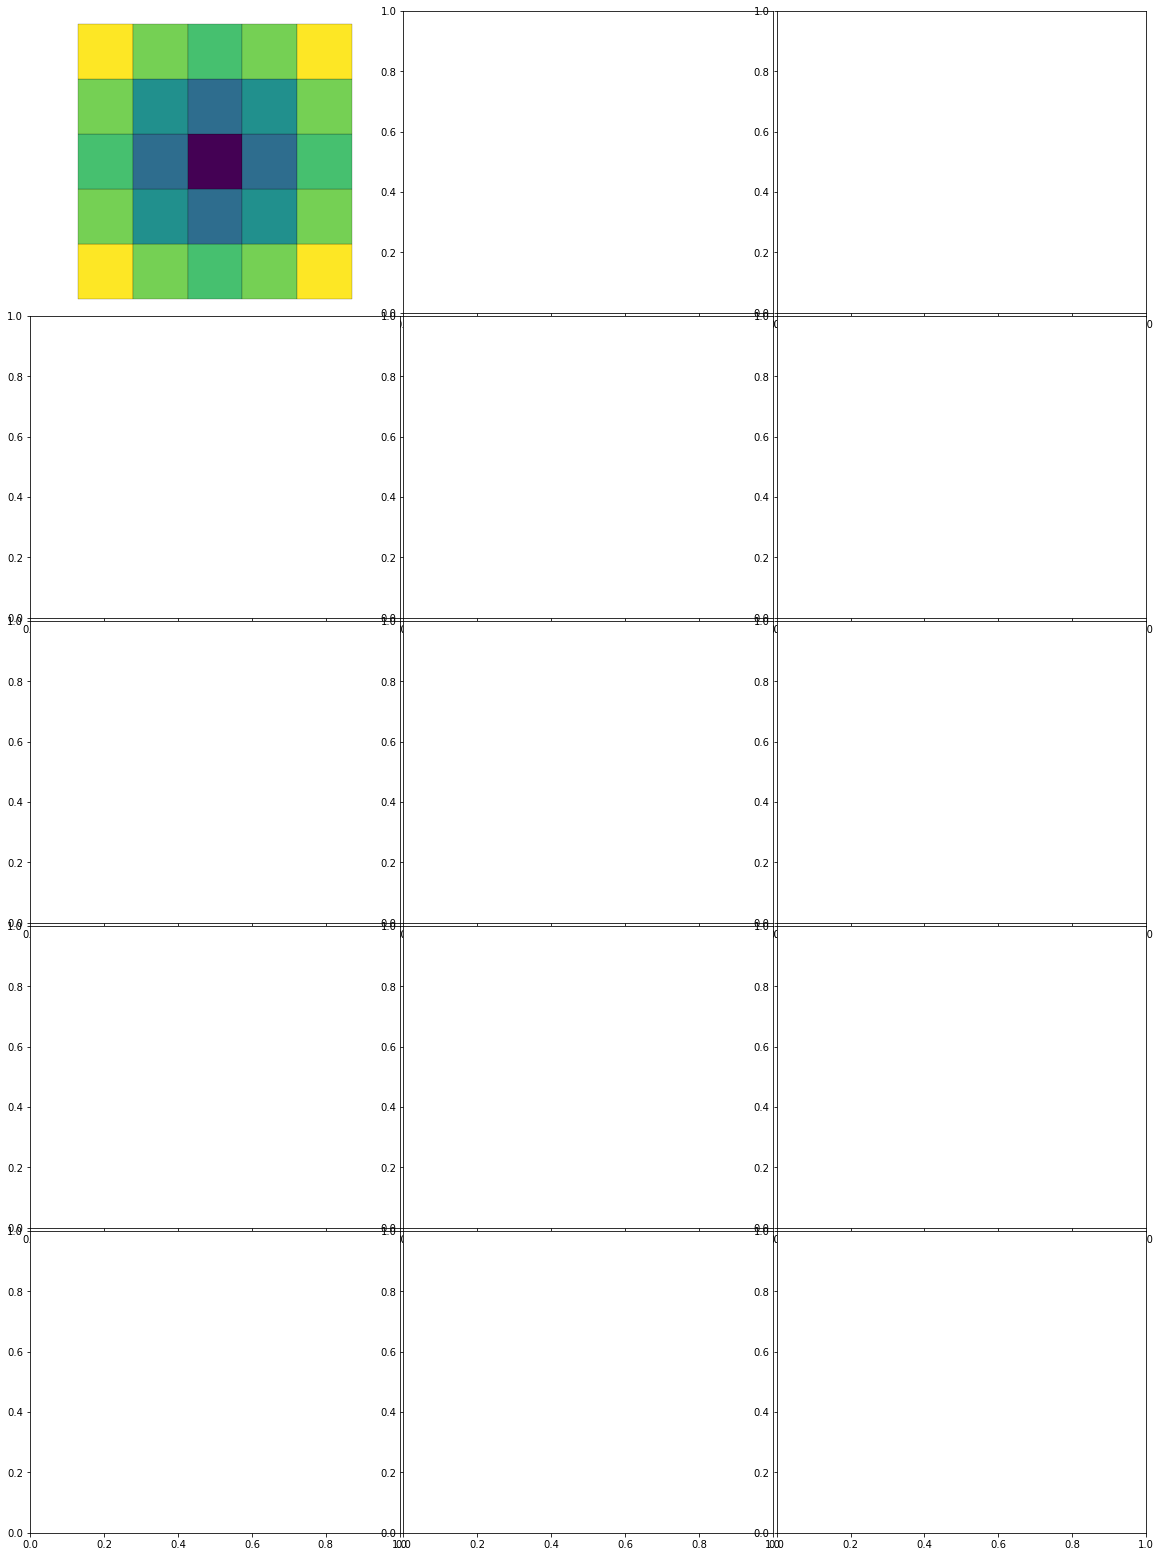

In [21]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import arcpy
from matplotlib.ticker import FuncFormatter

# Variables to plot and their titles
variables = ['speed', 'TDM', 'Temp_F']
titles = ['Speed (m/s)', 'TDM', 'Temperature (F)']

# Use the in-memory layers (already built) and sorted timestamps
timestamps = sorted(layer_dict.keys())
layers = [layer_dict[t] for t in timestamps]

# Load basemap shapefile (static polygon grid)
basemap_file = [os.path.join(workspace, f)
    for f in os.listdir(workspace)
    if f.startswith("expo_2022_08_12_15_15_00") and f.endswith(".shp")
][0]

# Determine consistent extent from all in-memory layers
global_extent = arcpy.Describe(basemap_file).extent
for lyr in layers:
    desc = arcpy.Describe(lyr)
    extent = desc.extent
    if global_extent is None:
        global_extent = extent
    else:
        global_extent.XMin = min(global_extent.XMin, extent.XMin)
        global_extent.XMax = max(global_extent.XMax, extent.XMax)
        global_extent.YMin = min(global_extent.YMin, extent.YMin)
        global_extent.YMax = max(global_extent.YMax, extent.YMax)

# Set up figure
fig, axs = plt.subplots(nrows=len(layers), ncols=3, figsize=(20, 28))
plt.subplots_adjust(wspace=0.01, hspace=0.01)

# Plot each timestamp-layer
for row, lyr in enumerate(layers):
    for col, var in enumerate(variables):
        ax = axs[row, col]
        ax.axis('off')
        ax.set_aspect('equal')

        # Step 1: Draw gray grid basemap
        with arcpy.da.SearchCursor(basemap_file, ['SHAPE@']) as cursor:
            for shape, in cursor:
                if shape:
                    for part in shape:
                        x, y = zip(*[(pt.X, pt.Y) for pt in part])
                        ax.fill(x, y, facecolor='lightgray', edgecolor='gray', linewidth=0.3)

        # Step 2: Draw variable overlay
        vals = []
        with arcpy.da.SearchCursor(lyr, [var]) as cursor:
            for row_ in cursor:
                val = row_[0]
                if val is not None:
                    vals.append(val)
        local_min = min(vals) if vals else 0
        local_max = max(vals) if vals else 1

        cmap = plt.cm.viridis
        if var == 'speed':
            local_min = round(local_min, 3)
            local_max = round(local_max, 3)
            if local_max == local_min:
                local_max += 0.001
        norm = mpl.colors.Normalize(vmin=local_min, vmax=local_max)

        with arcpy.da.SearchCursor(lyr, ['SHAPE@', var]) as cursor:
            for shape, val in cursor:
                if shape and val is not None:
                    for part in shape:
                        x, y = zip(*[(pt.X, pt.Y) for pt in part])
                        ax.fill(x, y, color=cmap(norm(val)), edgecolor='black', linewidth=0.2)

        ax.set_xlim(global_extent.XMin, global_extent.XMax)
        ax.set_ylim(global_extent.YMin, global_extent.YMax)

        # Titles and labels
        if row == 0:
            ax.set_title(titles[col], fontsize=14)
        if col == 0:
            ax.text(
                -0.1, 0.5, str(timestamps[row]),
                rotation=90, va='center', ha='center',
                fontsize=12, transform=ax.transAxes
            )

        # Colorbar
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm._A = []
        cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
        if var == 'speed':
            formatter = FuncFormatter(lambda x, _: f'{x:.3f}'.rstrip('0').rstrip('.') if '.' in f'{x:.3f}' else f'{x:.3f}')
            cbar.ax.yaxis.set_major_formatter(formatter)
        else:
            cbar.ax.ticklabel_format(style='plain', useOffset=False)
        cbar.ax.tick_params(labelsize=8)
        cbar.set_label(titles[col], fontsize=12)

plt.show()


In [100]:
(expo_summary_df)

,pointid,disk0_mean,disk1_mean,disk2_mean,disk3_mean,disk4_mean,disk5_mean,disk0_std,disk1_std,disk2_std,...,disk4_std,disk5_std,prism_mean,prism_std,start_datetime,budget,vmax,disk_interval,cell_size,process_time
0,2498856,400.0,399.999594,399.999897,400.000051,399.999894,399.999592,NaN,0.000006,0.000003,...,0.000004,2.196950e-10,399.999838,0.000182,8/12/2022 03:00:00 PM,"(30, 1)",1.5646,300,200,12.311086


In [23]:
(all_final_summary_df)

,timestamp,originID,VExpo_unweight,Coord,Timestamp,orig_prob,VExpo_weight,pointid
0,2022_08_12_15_00_00,"(334510.0, 4432090.0)",395.606999,"(334510.0, 4432090.0)",2022_08_12_15_00_00,1.000000,395.606999,2498856
1,2022_08_12_15_05_00,"(334110.0, 4431690.0)",396.375400,"(334110.0, 4431690.0)",2022_08_12_15_05_00,0.022348,8.858197,2498856
2,2022_08_12_15_05_00,"(334110.0, 4431890.0)",396.271911,"(334110.0, 4431890.0)",2022_08_12_15_05_00,0.028268,11.201893,2498856
3,2022_08_12_15_05_00,"(334110.0, 4432090.0)",395.071004,"(334110.0, 4432090.0)",2022_08_12_15_05_00,0.031605,12.486180,2498856
4,2022_08_12_15_05_00,"(334110.0, 4432290.0)",394.180462,"(334110.0, 4432290.0)",2022_08_12_15_05_00,0.028268,11.142772,2498856
...,...,...,...,...,...,...,...,...
409,2022_08_12_15_25_00,"(334910.0, 4431690.0)",397.373877,"(334910.0, 4431690.0)",2022_08_12_15_25_00,0.022348,8.880511,2498856
410,2022_08_12_15_25_00,"(334910.0, 4431890.0)",396.468258,"(334910.0, 4431890.0)",2022_08_12_15_25_00,0.028268,11.207444,2498856
411,2022_08_12_15_25_00,"(334910.0, 4432090.0)",396.763754,"(334910.0, 4432090.0)",2022_08_12_15_25_00,0.031605,12.539679,2498856
412,2022_08_12_15_25_00,"(334910.0, 4432290.0)",396.337500,"(334910.0, 4432290.0)",2022_08_12_15_25_00,0.028268,11.203747,2498856


In [91]:
(expo_summary_df)

,pointid,disk0_mean,disk1_mean,disk2_mean,disk3_mean,disk4_mean,disk5_mean,disk6_mean,disk7_mean,disk0_std,...,disk6_std,disk7_std,prism_mean,prism_std,start_datetime,budget,vmax,disk_interval,cell_size,process_time
0,1533755,399.680082,398.750273,397.960155,396.90587,396.22447,397.136986,398.19332,399.320297,NaN,...,1.770347,1.000555,398.021432,1.132391,8/12/2022 03:00:00 PM,"(40, 1)",1.17345,300,200,13.43368


In [95]:
(all_final_summary_df)

,timestamp,originID,VExpo_unweight,Coord,Timestamp,orig_prob,VExpo_weight,pointid
0,2022_08_12_15_00_00,"(334510.0, 4432090.0)",395.606999,"(334510.0, 4432090.0)",2022_08_12_15_00_00,1.000000,395.606999,2498856
1,2022_08_12_15_05_00,"(334110.0, 4431690.0)",396.278056,"(334110.0, 4431690.0)",2022_08_12_15_05_00,0.022348,8.856022,2498856
2,2022_08_12_15_05_00,"(334110.0, 4431890.0)",396.162592,"(334110.0, 4431890.0)",2022_08_12_15_05_00,0.028268,11.198803,2498856
3,2022_08_12_15_05_00,"(334110.0, 4432090.0)",395.057027,"(334110.0, 4432090.0)",2022_08_12_15_05_00,0.031605,12.485738,2498856
4,2022_08_12_15_05_00,"(334110.0, 4432290.0)",394.279713,"(334110.0, 4432290.0)",2022_08_12_15_05_00,0.028268,11.145578,2498856
...,...,...,...,...,...,...,...,...
409,2022_08_12_15_25_00,"(334910.0, 4431690.0)",397.373877,"(334910.0, 4431690.0)",2022_08_12_15_25_00,0.022348,8.880511,2498856
410,2022_08_12_15_25_00,"(334910.0, 4431890.0)",396.468258,"(334910.0, 4431890.0)",2022_08_12_15_25_00,0.028268,11.207444,2498856
411,2022_08_12_15_25_00,"(334910.0, 4432090.0)",396.763754,"(334910.0, 4432090.0)",2022_08_12_15_25_00,0.031605,12.539679,2498856
412,2022_08_12_15_25_00,"(334910.0, 4432290.0)",396.337500,"(334910.0, 4432290.0)",2022_08_12_15_25_00,0.028268,11.203747,2498856


### export as shapefile

In [8]:
import arcpy
import pandas as pd
import os

def export_by_timestamp(df, grid_shapefile, output_folder, output_specifier):
    arcpy.env.overwriteOutput = True
    arcpy.env.workspace = output_folder

    # Prepare Coord column for matching
    df["Coord_clean"] = df["Coord"].str.strip("()").str.replace(" ", "")  # "(x, y)" → "x,y"

    # Create a feature layer once
    grid_layer = "grid_layer"
    arcpy.MakeFeatureLayer_management(grid_shapefile, grid_layer)

    for timestamp, group in df.groupby("timestamp"):
        coords = group["Coord_clean"].unique()
        where = " OR ".join([f"Centroid = '{c}'" for c in coords])

        # Select matching features
        arcpy.SelectLayerByAttribute_management(grid_layer, "NEW_SELECTION", where)

        # Export selected features to temp shapefile
        safe_timestamp = str(timestamp).replace(":", "_").replace(" ", "_")
        out_shapefile = os.path.join(output_folder, f"expo_{output_specifier}_{safe_timestamp}.shp")
        arcpy.CopyFeatures_management(grid_layer, out_shapefile)

        # Write filtered df to temp CSV for joining
        group["join_key"] = group["Coord_clean"]
        csv_path = os.path.join(output_folder, "temp.csv")
        group.to_csv(csv_path, index=False)

        # Convert CSV to DBF table
        table_path = os.path.join(output_folder, "temp_table.dbf")
        if arcpy.Exists(table_path):
            arcpy.Delete_management(table_path)
        arcpy.TableToTable_conversion(csv_path, output_folder, "temp_table.dbf")

        # Add join_key to shapefile
        arcpy.AddField_management(out_shapefile, "join_key", "TEXT")
        with arcpy.da.UpdateCursor(out_shapefile, ["Centroid", "join_key"]) as cursor:
            for row in cursor:
                row[1] = row[0].replace(" ", "")  # set join_key = Centroid with no spaces
                cursor.updateRow(row)

        # Join and update export
        arcpy.JoinField_management(out_shapefile, "join_key", table_path, "join_key")
        print(f"Exported: expo_{output_specifier}_{safe_timestamp}.shp")

    arcpy.Delete_management(grid_layer)


In [15]:
df = pd.read_csv(r"C:\study\1_OSU\harvey\pyst_test\columbus_sample\detailed_voxel_output_table.csv")  # Has timestamp, pointid, Coord
grid_shapefile = r'C:\study\1_OSU\harvey\pyst_test\temperature\mean_200m_af_2.shp'  # param 8
output_folder = workspace
output_specifier = "200m" 

export_by_timestamp(df, grid_shapefile, output_folder,output_specifier)
#df["Coord"].astype(str).str.strip("()")



Exported: expo_200m_2022_08_12_15_00_00.shp
Exported: expo_200m_2022_08_12_15_05_00.shp
Exported: expo_200m_2022_08_12_15_10_00.shp
Exported: expo_200m_2022_08_12_15_15_00.shp
Exported: expo_200m_2022_08_12_15_20_00.shp
Exported: expo_200m_2022_08_12_15_25_00.shp


### Visualize and summary

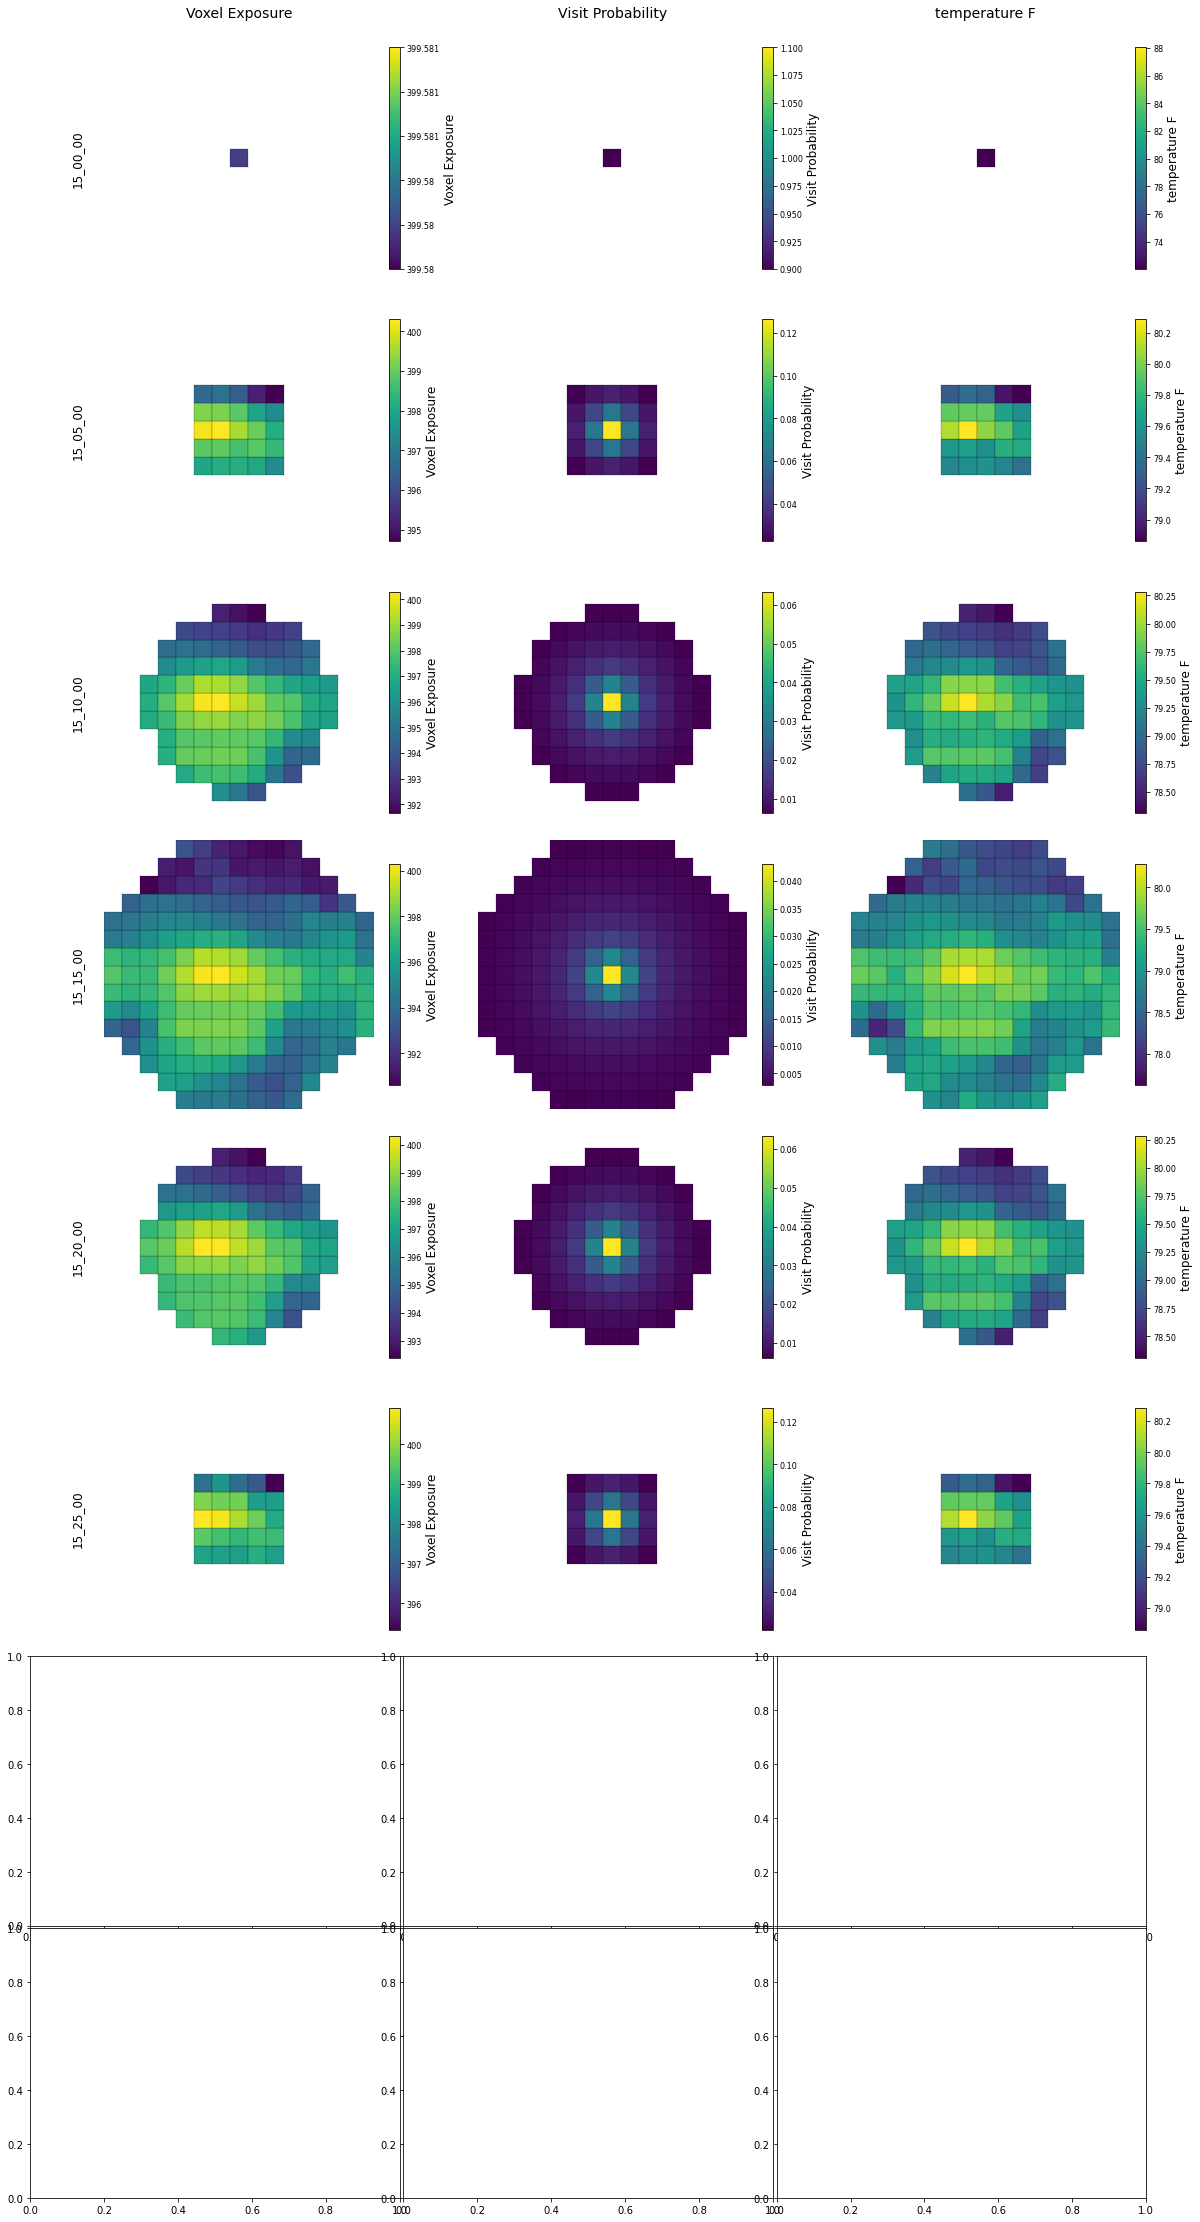

In [16]:
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import arcpy
from matplotlib.ticker import FuncFormatter

# Configurations
shapefile_dir = workspace  # Change to your actual path
output_fig = os.path.join(shapefile_dir, "exposure_matrix_final_scaled_separate_legends.png")

variables = ['VExpo_unwe', 'orig_prob', 'Temp_F']
titles = ['Voxel Exposure', 'Visit Probability', 'temperature F']

# Sort shapefiles by timestamp in filename
shapefiles = sorted([
    os.path.join(shapefile_dir, f)
    for f in os.listdir(shapefile_dir)
    if f.endswith(".shp") and f.startswith("expo_200m_2022_08_12_")
])[:8]

timestamps = [os.path.basename(f).replace(".shp", "").split("expo_200m_2022_08_12_")[1] for f in shapefiles]

# Determine consistent extent (bounding box)
global_extent = None
for shp in shapefiles:
    desc = arcpy.Describe(shp)
    extent = desc.extent
    if global_extent is None:
        global_extent = extent
    else:
        global_extent.XMin = min(global_extent.XMin, extent.XMin)
        global_extent.XMax = max(global_extent.XMax, extent.XMax)
        global_extent.YMin = min(global_extent.YMin, extent.YMin)
        global_extent.YMax = max(global_extent.YMax, extent.YMax)

# Set up figure and axes
fig, axs = plt.subplots(nrows=8, ncols=3, figsize=(20, 40))
plt.subplots_adjust(wspace=0.01, hspace=0.01)

# Draw maps
for row, shp in enumerate(shapefiles):
    for col, var in enumerate(variables):
        ax = axs[row, col]
        ax.axis('off')
        ax.set_aspect('equal')

        # Compute local min/max for this variable in this shapefile
        vals = []
        with arcpy.da.SearchCursor(shp, [var]) as cursor:
            for row_ in cursor:
                val = row_[0]
                if val is not None:
                    vals.append(val)
        local_min = min(vals) if vals else 0
        local_max = max(vals) if vals else 1
        
        
        cmap = plt.cm.viridis
        #norm = mpl.colors.Normalize(vmin=local_min, vmax=local_max)
        
        if var == 'VExpo_unwe':
            local_min = round(min(vals), 3)
            local_max = round(max(vals), 3)
            if local_max == local_min:
                local_max += 0.001
            norm = mpl.colors.Normalize(vmin=local_min, vmax=local_max)
        else:
            norm = mpl.colors.Normalize(vmin=local_min, vmax=local_max)

        
        with arcpy.da.SearchCursor(shp, ['SHAPE@', var]) as cursor:
            for shape, val in cursor:
                if shape and val is not None:
                    for part in shape:
                        x, y = zip(*[(pt.X, pt.Y) for pt in part])
                        ax.fill(x, y, color=cmap(norm(val)), edgecolor='black', linewidth=0.2)

        ax.set_xlim(global_extent.XMin, global_extent.XMax)
        ax.set_ylim(global_extent.YMin, global_extent.YMax)

        # Add column titles
        if row == 0:
            ax.set_title(titles[col], fontsize=14)

        # Add timestamp label on left of each row
        if col == 0:
            ax.text(
                -0.1, 0.5, timestamps[row],
                rotation=90, va='center', ha='center',
                fontsize=12, transform=ax.transAxes
            )

        # Add individual colorbar below each subplot
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm._A = []  # dummy array for ScalarMappable
        cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)
        cbar.ax.ticklabel_format(style='plain', useOffset=False)
        # Custom formatter to round to 3 decimal places
        if var == 'VExpo_unwe':
            # Custom formatter to round to 3 decimals and remove scientific notation
            formatter = FuncFormatter(lambda x, _: f'{x:.3f}'.rstrip('0').rstrip('.') if '.' in f'{x:.3f}' else f'{x:.3f}')
            cbar.ax.yaxis.set_major_formatter(formatter)
        else:
            cbar.ax.ticklabel_format(style='plain', useOffset=False)
        cbar.ax.tick_params(labelsize=8)
        cbar.ax.xaxis.label.set_size(8)
        cbar.set_label(titles[col], fontsize=12)

# Remove old shared colorbars (commented out)
"""
for col, var in enumerate(variables):
    left = 0.13 + col * 0.22
    bottom = 0.04
    width = 0.18
    cax = fig.add_axes([left, bottom, width, 0.015])
    norm = mpl.colors.Normalize(vmin=global_mins[var], vmax=global_maxs[var])
    sm = plt.cm.ScalarMappable(norm=norm, cmap=plt.cm.viridis)
    cb = plt.colorbar(sm, cax=cax, orientation='horizontal')
    cb.ax.set_xlabel(titles[col], fontsize=11)
    cb.ax.tick_params(labelsize=9)
"""

plt.savefig(output_fig, dpi=1000, bbox_inches='tight')
plt.show()


C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\IPython\core\interactiveshell.py:3437: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


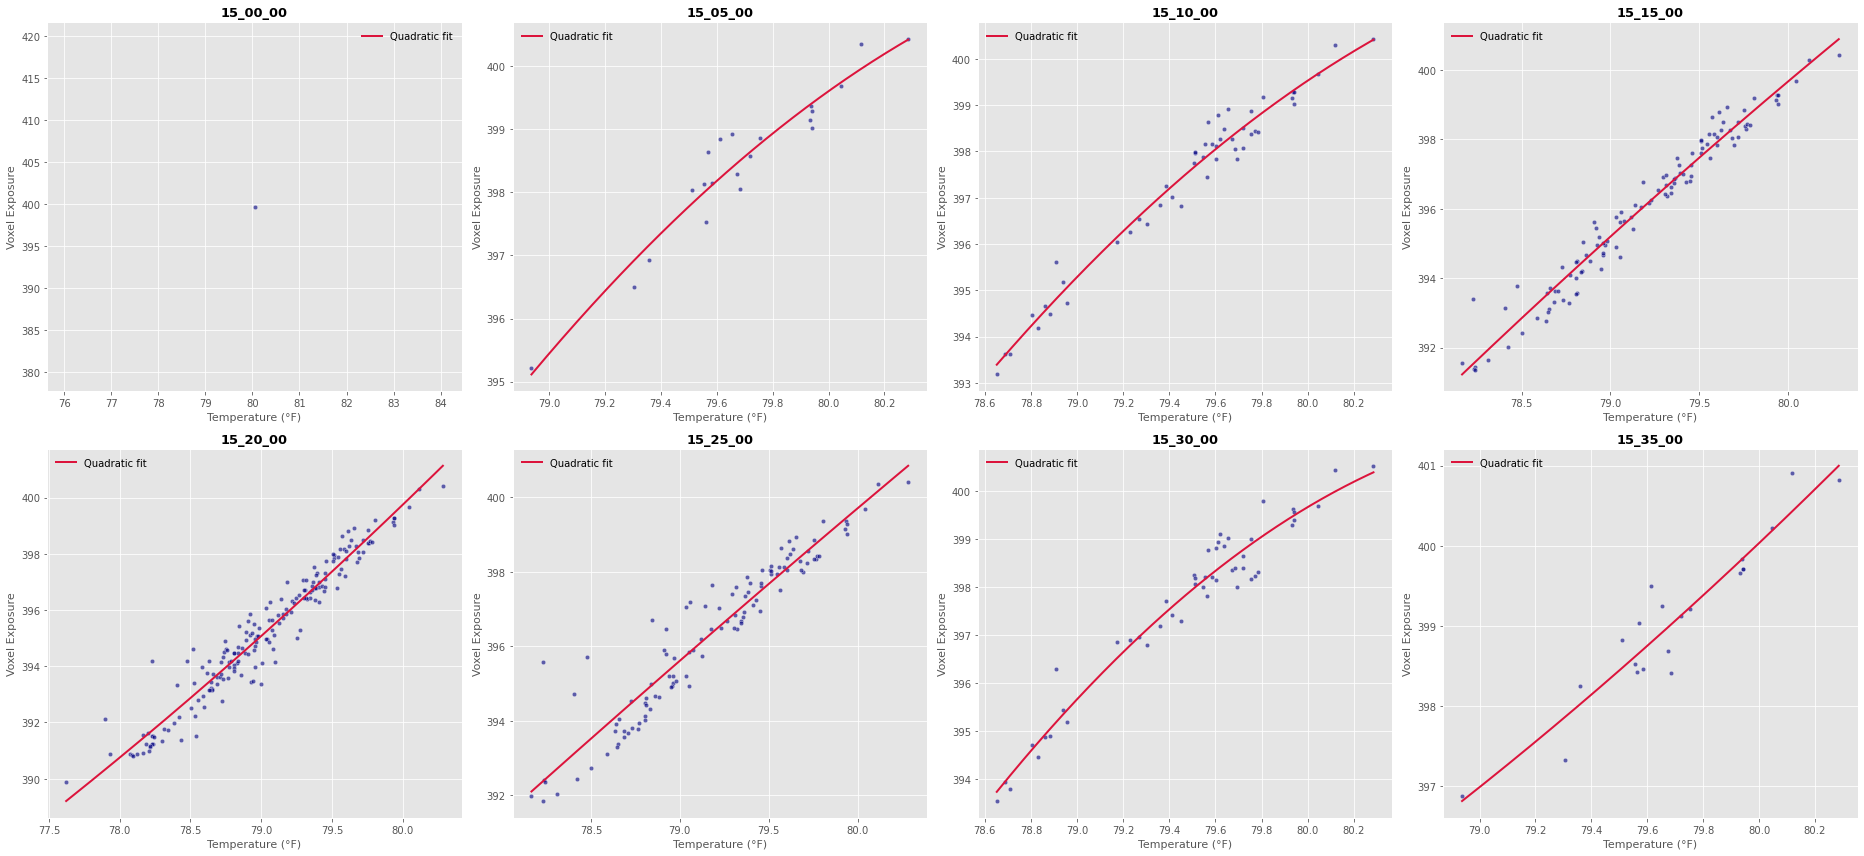

In [93]:
import os
import matplotlib.pyplot as plt
import arcpy
import numpy as np

# Configuration
shapefile_dir = workspace  # Set this to your folder path
output_fig = os.path.join(shapefile_dir, "scatter_temp_vs_vexpo_quadratic.png")

# Collect and sort shapefiles
shapefiles = sorted([
    os.path.join(shapefile_dir, f)
    for f in os.listdir(shapefile_dir)
    if f.endswith(".shp") and f.startswith("expo_200_T40_5min_2022_08_12_")
])[:8]

timestamps = [os.path.basename(f).split("expo_200_T40_5min_2022_08_12_")[1].replace(".shp", "") for f in shapefiles]

# Set up modern plot style
plt.style.use("ggplot")  # or "ggplot" or your preference
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(26, 12))
axs = axs.flatten()

# Loop through shapefiles
for i, (shp, ts) in enumerate(zip(shapefiles, timestamps)):
    temp_vals = []
    vexpo_vals = []

    with arcpy.da.SearchCursor(shp, ["Temp_F", "VExpo_unwe"]) as cursor:
        for row in cursor:
            temp, vexpo = row
            if temp is not None and vexpo is not None:
                temp_vals.append(temp)
                vexpo_vals.append(vexpo)

    ax = axs[i]
    if temp_vals:
        ax.scatter(temp_vals, vexpo_vals, s=20, alpha=0.6, color="navy", edgecolor="white", linewidth=0.5)

        # Fit quadratic curve
        coeffs = np.polyfit(temp_vals, vexpo_vals, deg=2)
        fit_fn = np.poly1d(coeffs)
        temp_range = np.linspace(min(temp_vals), max(temp_vals), 200)
        ax.plot(temp_range, fit_fn(temp_range), color="crimson", linewidth=2.0, label="Quadratic fit")

        ax.set_title(f"{ts}", fontsize=13, weight="bold")
        ax.set_xlabel("Temperature (°F)", fontsize=11)
        ax.set_ylabel("Voxel Exposure", fontsize=11)
        ax.legend(frameon=False, fontsize=10)
        ax.tick_params(axis='both', labelsize=10)
    else:
        ax.text(0.5, 0.5, "No data", ha='center', va='center')
        ax.set_axis_off()

# Hide any unused axes
for j in range(len(shapefiles), len(axs)):
    axs[j].set_visible(False)

plt.tight_layout()
plt.savefig(output_fig, dpi=300, bbox_inches='tight')
plt.show()


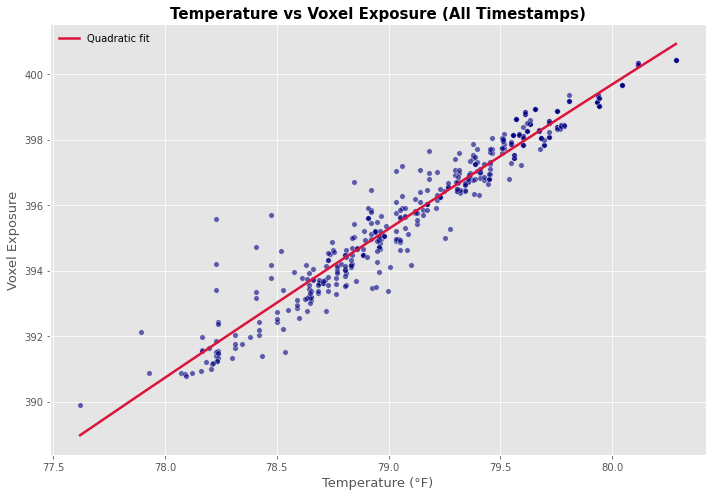

In [94]:
import os
import matplotlib.pyplot as plt
import arcpy
import numpy as np

# Configuration
shapefile_dir = workspace  # Your shapefile folder path
output_fig = os.path.join(shapefile_dir, "scatter_all_temp_vs_vexpo.png")

# Collect and sort shapefiles
shapefiles = sorted([
    os.path.join(shapefile_dir, f)
    for f in os.listdir(shapefile_dir)
    if f.endswith(".shp") and f.startswith("expo_200_T40_5min_2022_08_12_")
])[:6]

# Set up modern plot style
plt.style.use("ggplot")

# Collect all data
all_temp_vals = []
all_vexpo_vals = []

for shp in shapefiles:
    with arcpy.da.SearchCursor(shp, ["Temp_F", "VExpo_unwe"]) as cursor:
        for row in cursor:
            temp, vexpo = row
            if temp is not None and vexpo is not None:
                all_temp_vals.append(temp)
                all_vexpo_vals.append(vexpo)

# Create single scatter plot
plt.figure(figsize=(10, 7))
plt.scatter(all_temp_vals, all_vexpo_vals, s=30, alpha=0.6, color="navy", edgecolor="white", linewidth=0.5)

# Fit and plot quadratic curve
if all_temp_vals:
    coeffs = np.polyfit(all_temp_vals, all_vexpo_vals, deg=2)
    fit_fn = np.poly1d(coeffs)
    temp_range = np.linspace(min(all_temp_vals), max(all_temp_vals), 300)
    plt.plot(temp_range, fit_fn(temp_range), color="crimson", linewidth=2.5, label="Quadratic fit")

    plt.xlabel("Temperature (°F)", fontsize=13)
    plt.ylabel("Voxel Exposure", fontsize=13)
    plt.title("Temperature vs Voxel Exposure (All Timestamps)", fontsize=15, weight="bold")
    plt.legend(frameon=False)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_fig, dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No valid data found across shapefiles.")


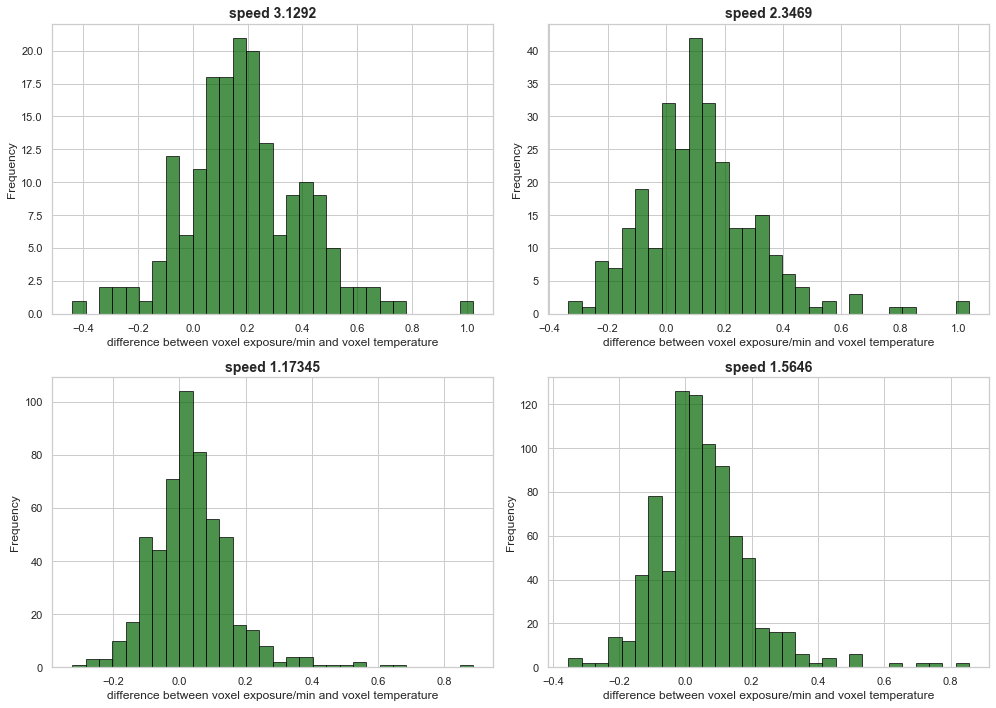

In [28]:
import os
import arcpy
import matplotlib.pyplot as plt

# Workspace directory where shapefiles are stored
shapefile_dir = r'C:\study\1_OSU\harvey\pyst_test\columbus_sample'  # 🔁 Replace with your path
arcpy.env.workspace = shapefile_dir

# Define the group prefixes and plot titles
groups = {
    "expo_200_T15_5min": "speed 3.1292",
    "expo_200_T20_5min": "speed 2.3469",
    "expo_200_T40_5min": "speed 1.17345",
    "expo_200m": "speed 1.5646"  # Keep last to avoid partial matches with more specific ones
}

# Set up the plot
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axs = axs.flatten()

# Process each group
for idx, (prefix, speed_label) in enumerate(groups.items()):
    values = []

    # Collect shapefiles for this group
    group_shapefiles = sorted([
        os.path.join(shapefile_dir, f)
        for f in os.listdir(shapefile_dir)
        if f.endswith(".shp") and f.startswith(prefix)
    ])

    # Loop through shapefiles and collect values
    for shp in group_shapefiles:
        with arcpy.da.SearchCursor(shp, ["VExpo_unwe", "Temp_F"]) as cursor:
            for vexpo, temp in cursor:
                if vexpo is not None and temp is not None:
                    values.append((vexpo / 5.0) - temp)

    # Plot histogram
    ax = axs[idx]
    if values:
        ax.hist(values, bins=30, color='darkgreen', edgecolor='black', alpha=0.7)
        ax.set_title(speed_label, fontsize=14, weight='bold')
        ax.set_xlabel('difference between voxel exposure/min and voxel temperature', fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
    else:
        ax.text(0.5, 0.5, "No data", ha='center', va='center', fontsize=12)
        ax.set_axis_off()

# Final touches
plt.tight_layout()
output_fig = os.path.join(shapefile_dir, "histograms_by_group_speed.png")
plt.savefig(output_fig, dpi=300, bbox_inches='tight')
plt.show()


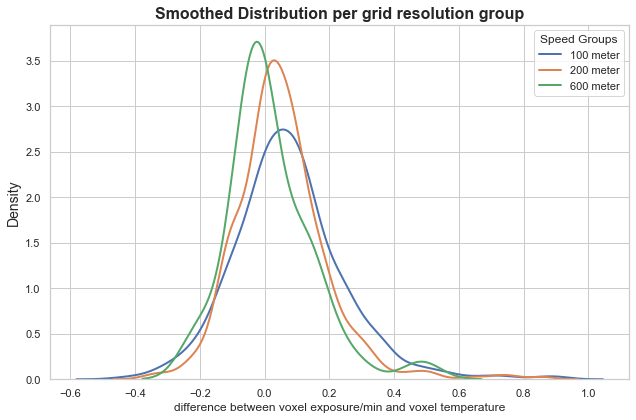

In [40]:
import os
import arcpy
import matplotlib.pyplot as plt
import seaborn as sns

# Workspace
shapefile_dir = r'C:\study\1_OSU\harvey\pyst_test\columbus_sample'
arcpy.env.workspace = shapefile_dir

# Group prefixes and speed labels
groups = {
    "expo_100m": "100 meter",
    "expo_200m": "200 meter",
    "expo_600": "600 meter"

    
    
}

# Matplotlib setup
plt.figure(figsize=(9, 6))
sns.set(style="whitegrid")

# Process each group
for prefix, speed_label in groups.items():
    values = []

    # Get all shapefiles for this group
    group_shapefiles = sorted([
        os.path.join(shapefile_dir, f)
        for f in os.listdir(shapefile_dir)
        if f.endswith(".shp") and f.startswith(prefix)
    ])

    #"""
    for shp in group_shapefiles:
        with arcpy.da.SearchCursor(shp, ["VExpo_unwe", "Temp_F"]) as cursor:
            for vexpo, temp in cursor:
                if vexpo is not None and temp is not None:
                    values.append((vexpo / 5.0) - temp)
    """
    for shp in group_shapefiles:
        with arcpy.da.SearchCursor(shp, ["VExpo_unwe"]) as cursor:
            for (vexpo,) in cursor:
                if vexpo is not None:
                    values.append(vexpo)
    #"""
    # Plot KDE curve if data exists
    if values:
        sns.kdeplot(values, label=speed_label, linewidth=2)

# Customize plot
plt.xlabel('difference between voxel exposure/min and voxel temperature', fontsize=12)
#plt.xlabel('voxel exposures of time slices (TDM)', fontsize=12)
plt.ylabel('Density', fontsize=14)
plt.title('Smoothed Distribution per grid resolution group', fontsize=16, weight='bold')
plt.legend(title="Speed Groups")
plt.tight_layout()

# Save and show
output_fig = os.path.join(shapefile_dir, "smoothed_curves_by_group.png")
plt.savefig(output_fig, dpi=300)
plt.show()


## batch visualization

In [9]:
import arcpy
import os

# Paths
gdb_path = r"C:\study\1_OSU\harvey\pyst_test\pyst_test.gdb"
feature_class = "fishnet_1800m_validtemp1450m"
csv_path = r"C:\study\1_OSU\harvey\pyst_test\columbus_sample\empirical result\summary_columbus_200m.csv"

# Temp layer names
fc_layer = "fishnet_layer"
csv_table = "summary_csv"

# Set environment
arcpy.env.workspace = gdb_path

# Make a feature layer from the feature class
arcpy.MakeFeatureLayer_management(os.path.join(gdb_path, feature_class), fc_layer)

# Make a table view from CSV
arcpy.MakeTableView_management(csv_path, csv_table)

# Perform join using 'pointid'
arcpy.AddJoin_management(fc_layer, "pointid", csv_table, "pointid")

# Add new fields to the joined layer
fields_to_add = [
    ("prism_total", "DOUBLE"),
    ("mean_disk_std", "DOUBLE"),
    ("expo_temp_gap", "DOUBLE")
]
for field_name, field_type in fields_to_add:
    arcpy.AddField_management(fc_layer, field_name, field_type)

# Calculate prism_total
arcpy.CalculateField_management(
    fc_layer, "prism_total", "!summary_columbus_200m.prism_mean! * 6", "PYTHON3"
)

# Calculate mean_disk_std
arcpy.CalculateField_management(
    fc_layer, "mean_disk_std",
    "mean([!summary_columbus_200m.disk1_std!, !summary_columbus_200m.disk2_std!, !summary_columbus_200m.disk3_std!, !summary_columbus_200m.disk4_std!, !summary_columbus_200m.disk5_std!])",
    "PYTHON3", "from statistics import mean"
)

# Calculate expo_temp_gap
arcpy.CalculateField_management(
    fc_layer, "expo_temp_gap",
    "(!summary_columbus_200m.prism_mean! / 5) - !summary_columbus_200m.disk3_temp_mean!",
    "PYTHON3"
)

print("Join and field calculations complete.")


ExecuteError: ERROR 000539: Invalid field summary_columbus_200m.prism_mean
Failed to execute (CalculateField).


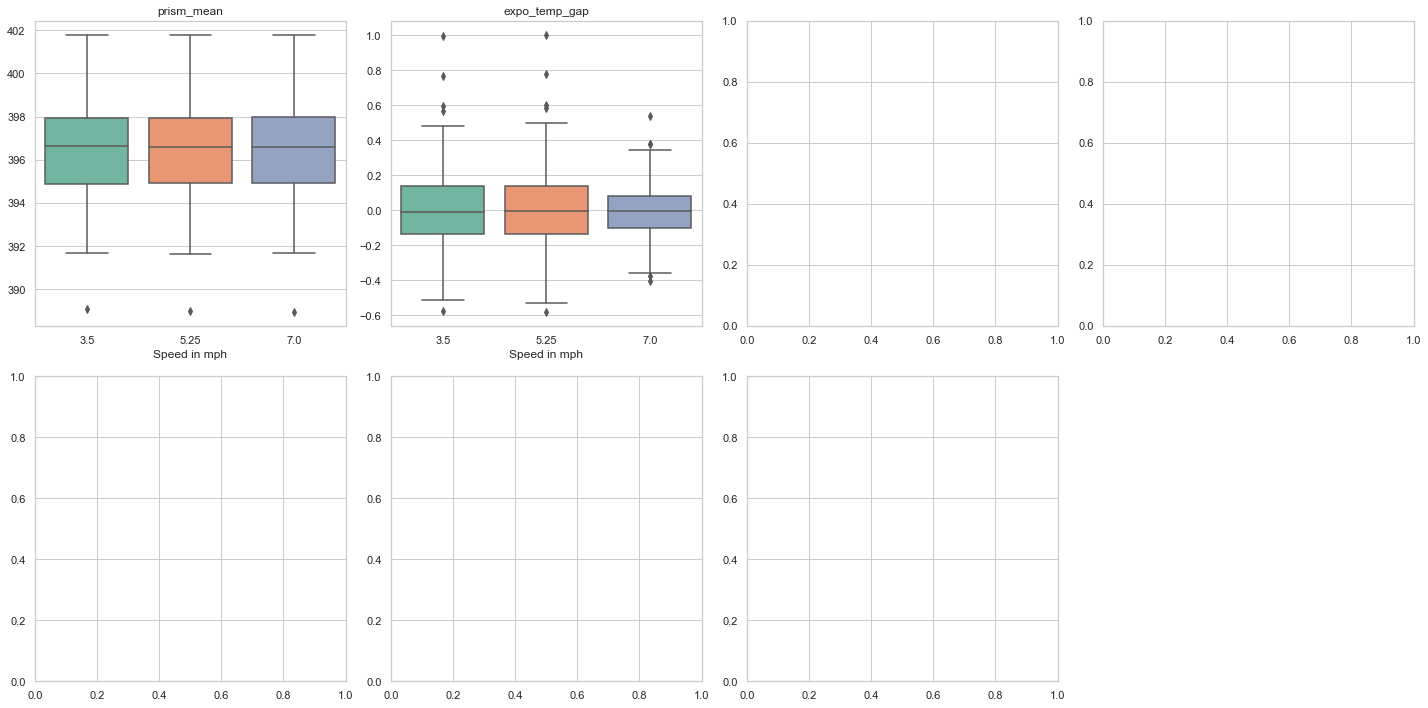

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df
# And it contains: 'cell_size', 'disk0_mean', ..., 'disk5_mean', 'prism_mean'
df = pd.read_csv(r"C:\Users\tokey\OneDrive - The Ohio State University\pyst_test\empirical result\speed_summary.csv")
# List of the variables to plot
variables = ['prism_mean','expo_temp_gap']

# Set up plot
sns.set(style="whitegrid")
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
axs = axs.flatten()

# Get a consistent color palette
palette = sns.color_palette("Set2", n_colors=df["vmax_mph"].nunique())

# Create a boxplot for each variable
for i, var in enumerate(variables):
    ax = axs[i]
    sns.boxplot(data=df, x="vmax_mph", y=var, palette=palette, ax=ax)
    ax.set_title(var)
    ax.set_xlabel("Speed in mph")
    ax.set_ylabel("")

# Remove the unused subplot (8th)
fig.delaxes(axs[-1])

plt.tight_layout()
plt.show()


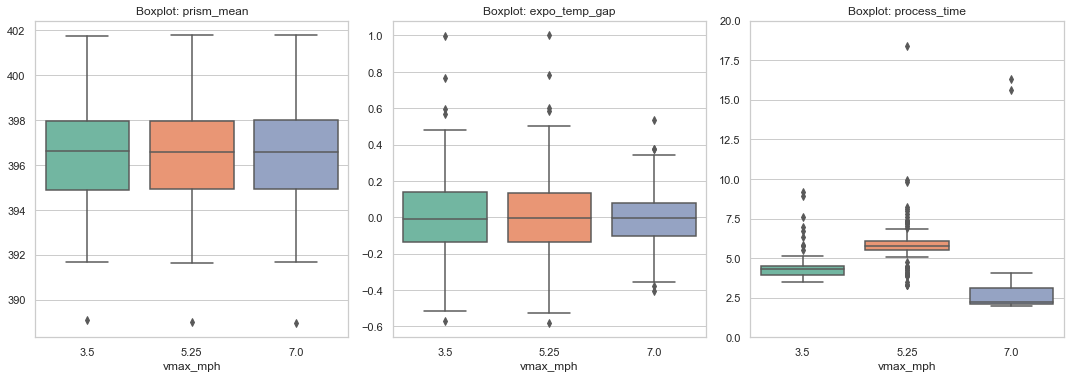

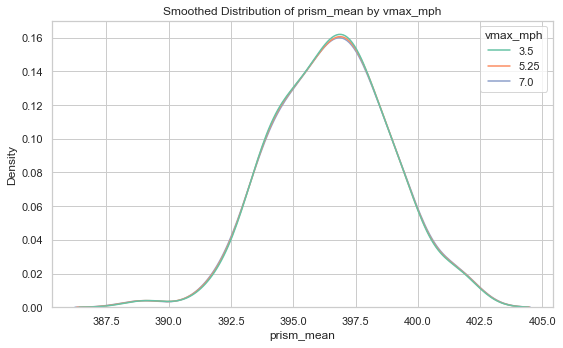

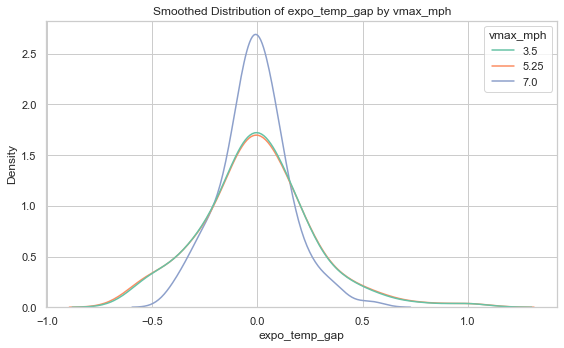

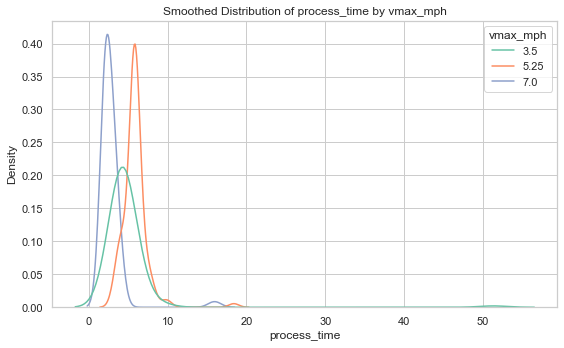


▶ Scatterplots for variable: prism_mean


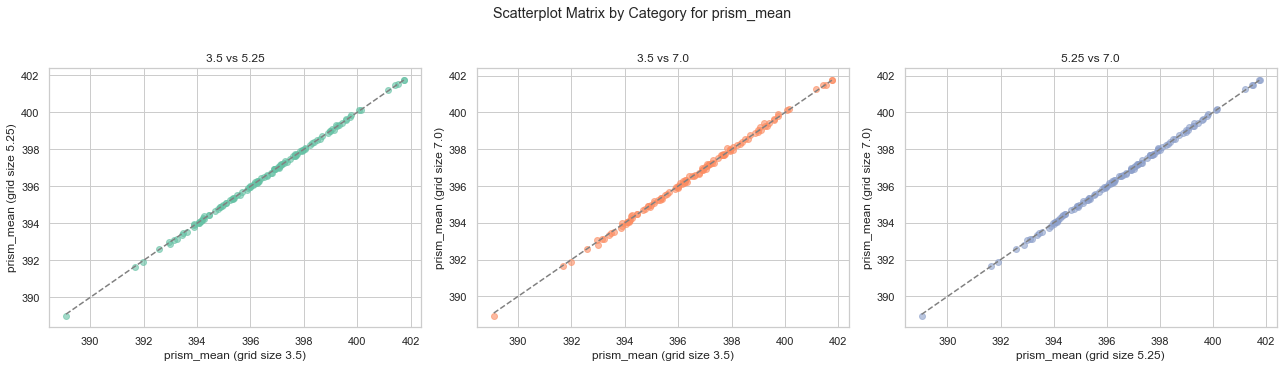


▶ Scatterplots for variable: expo_temp_gap


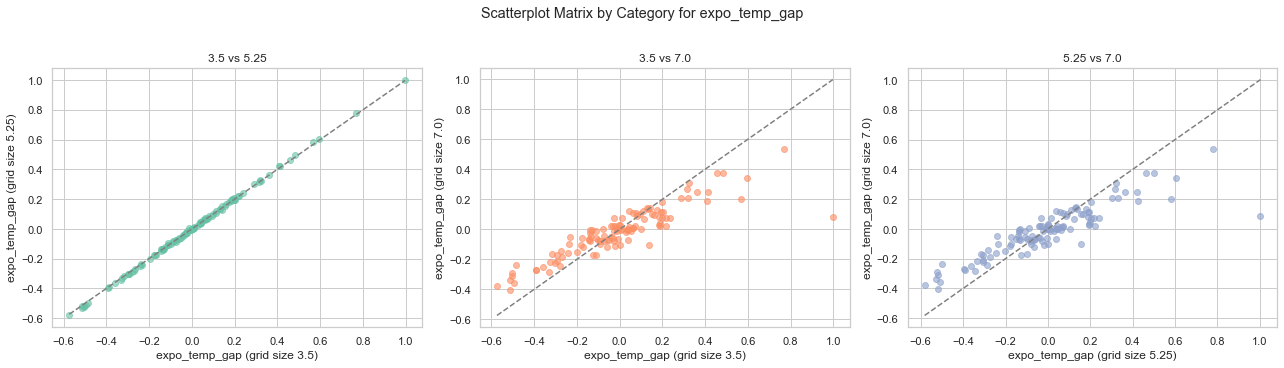


▶ Scatterplots for variable: process_time


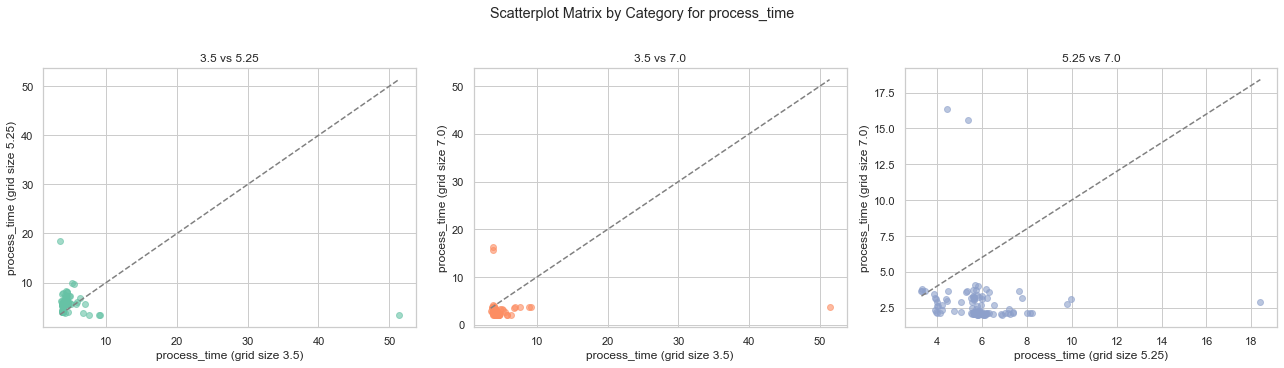

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

# Load data
df = pd.read_csv(r"C:\Users\tokey\OneDrive - The Ohio State University\pyst_test\empirical result\speed_summary.csv")

# Variables to plot
variables = [ 'prism_mean','expo_temp_gap','process_time'] #'disk0_mean', 'disk1_mean', 'disk2_mean', 'disk3_mean', 'disk4_mean', 'disk5_mean',
category = 'vmax_mph'

# Set style
sns.set(style="whitegrid")
palette = sns.color_palette("Set2", n_colors=df[category].nunique())

# -------------------------------------
# 📦 1. Boxplots for each variable
# -------------------------------------
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
axs = axs.flatten()

for i, var in enumerate(variables):
    ax = axs[i]
    sns.boxplot(data=df, x=category, y=var, palette=palette, ax=ax)
    ax.set_title(f"Boxplot: {var}")
    ax.set_xlabel("vmax_mph")
    ax.set_ylabel("")
    
# Remove unused subplot if needed
if len(variables) < len(axs):
    for j in range(len(variables), len(axs)):
        fig.delaxes(axs[j])
if var == variables[2]:
    plt.ylim(0, 20)
plt.tight_layout()
plt.show()


# -------------------------------------
# 📈 2. Smoothed distribution plot (KDE)
# -------------------------------------
for var in variables:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(data=df, x=var, hue=category, fill=False, common_norm=False, palette=palette, alpha=1)
    plt.title(f"Smoothed Distribution of {var} by {category}")
    plt.xlabel(var)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

# -------------------------------------
# 🔍 3. Scatterplot matrix (pairplot)
# -------------------------------------

# Unique categories (e.g., 3 speeds)
categories = sorted(df["vmax_mph"].dropna().unique())

# Loop through each variable
for var in variables:
    print(f"\n▶ Scatterplots for variable: {var}")
    
    # Pivot data: one row per ID, one column per category
    pivot_df = df.pivot(index="pointid", columns="vmax_mph", values=var)

    # Drop rows with missing values across any category
    pivot_df = pivot_df.dropna()

    # Create scatter plots for each pair of categories
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    for i, (cat_x, cat_y) in enumerate(combinations(categories, 2)):
        ax = axs[i]
        ax.scatter(pivot_df[cat_x], pivot_df[cat_y], alpha=0.6, color=palette[i])
        ax.plot([pivot_df[cat_x].min(), pivot_df[cat_x].max()],
                [pivot_df[cat_x].min(), pivot_df[cat_x].max()],
                color='gray', linestyle='--')  # 45-degree line

        ax.set_xlabel(f"{var} (grid size {cat_x})")
        ax.set_ylabel(f"{var} (grid size {cat_y})")
        ax.set_title(f"{cat_x} vs {cat_y}")
    
    plt.suptitle(f"Scatterplot Matrix by Category for {var}", y=1.02)
    plt.tight_layout()
    plt.show()



📄 Regression Summary Table:
      regression  intercept     slope  stderr_intercept  stderr_slope  \
0   Y:200 ~ X:66  -0.000076  1.000000          0.000090  2.278430e-07   
1   Y:600 ~ X:66  17.105708  0.956801          4.178144  1.053267e-02   
2  Y:600 ~ X:200  17.105773  0.956800          4.178132  1.053264e-02   

   pval_intercept    pval_slope  
0        0.403212  0.000000e+00  
1        0.000138  1.700213e-62  
2        0.000138  1.699954e-62  


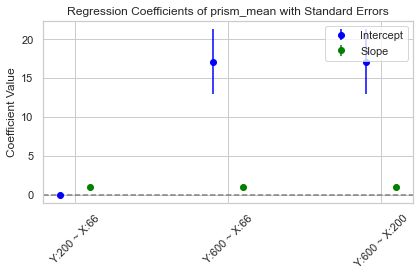

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from itertools import combinations

# Load data
df = pd.read_csv(r"C:\Users\tokey\OneDrive - The Ohio State University\pyst_test\empirical result\temp_scale_summary.csv")

# ID column and variable of interest
id_col = 'pointid'
var = 'prism_mean'
category_col = 'temp_cell'# 'vmax_mph'

# Clean categories
categories = sorted(df[category_col].dropna().unique())

# Pivot data: one row per pointid, columns = categories
pivot_df = df.pivot(index=id_col, columns=category_col, values=var)
pivot_df = pivot_df.dropna()

# Store regression results
results = []

# Regress each pair: y = later category, X = earlier category
for (cat_x, cat_y) in combinations(categories, 2):
    X = pivot_df[cat_x]
    y = pivot_df[cat_y]
    
    # Add constant for intercept
    X_with_const = sm.add_constant(X)
    
    # Run OLS regression
    model = sm.OLS(y, X_with_const).fit()
    
    # Extract info
    intercept = model.params['const']
    coef = model.params[cat_x]
    stderr_int = model.bse['const']
    stderr_coef = model.bse[cat_x]
    pval_int = model.pvalues['const']
    pval_coef = model.pvalues[cat_x]
    
    results.append({
        'regression': f'Y:{cat_y} ~ X:{cat_x}',
        'intercept': intercept,
        'slope': coef,
        'stderr_intercept': stderr_int,
        'stderr_slope': stderr_coef,
        'pval_intercept': pval_int,
        'pval_slope': pval_coef
        
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
print("\n📄 Regression Summary Table:")
print(results_df)

# -------------------------------------
# 📊 Coefficient Plot (intercept & slope with error bars)
# -------------------------------------
plt.figure(figsize=(6, 4))

for i, row in results_df.iterrows():
    plt.errorbar(x=i - 0.1, y=row['intercept'], yerr=row['stderr_intercept'],
                 fmt='o', color='blue', label='Intercept' if i == 0 else "")
    plt.errorbar(x=i + 0.1, y=row['slope'], yerr=row['stderr_slope'],
                 fmt='o', color='green', label='Slope' if i == 0 else "")

plt.xticks(range(len(results_df)), results_df['regression'], rotation=45)
plt.ylabel("Coefficient Value")
plt.title(f"Regression Coefficients of {var} with Standard Errors")
plt.axhline(0, color='gray', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()


### test algorithm

In [3]:
# test algorithm
import math

def line_grid_lengths(origin, destination, grid_size):
    """
    Calculates the length of a line that passes through grid cells.

    Parameters:
    - origin: (x, y) tuple
    - destination: (x, y) tuple
    - grid_size: length of one grid cell (assuming square)

    Returns:
    - List of (grid_x, grid_y, length_in_cell)
    """

    x0, y0 = origin
    x1, y1 = destination

    dx = x1 - x0
    dy = y1 - y0
    total_length = math.hypot(dx, dy)

    if total_length == 0:
        grid_x = int(x0 // grid_size)
        grid_y = int(y0 // grid_size)
        return [(grid_x, grid_y, 0.0)]

    # Direction
    step_x = 1 if dx > 0 else -1
    step_y = 1 if dy > 0 else -1

    # Grid start positions
    x = x0
    y = y0
    grid_x = int(x // grid_size)
    grid_y = int(y // grid_size)

    t_max_x = ((grid_x + (step_x > 0)) * grid_size - x) / dx if dx != 0 else float('inf')
    t_max_y = ((grid_y + (step_y > 0)) * grid_size - y) / dy if dy != 0 else float('inf')

    t_delta_x = abs(grid_size / dx) if dx != 0 else float('inf')
    t_delta_y = abs(grid_size / dy) if dy != 0 else float('inf')

    t = 0.0
    results = []

    while t <= 1.0:
        next_t = min(t_max_x, t_max_y)
        segment_length = (next_t - t) * total_length
        results.append(((grid_x, grid_y), segment_length))
        t = next_t

        if t_max_x < t_max_y:
            grid_x += step_x
            t_max_x += t_delta_x
        else:
            grid_y += step_y
            t_max_y += t_delta_y

    return results


In [4]:
origin = (332910, 4427090)
destination = (331710, 4427890)
grid_size = 200

segments = line_grid_lengths(origin, destination, grid_size)
for (gx, gy), length in segments:
    print(f"Grid ({gx}, {gy}) — Length in cell: {length:.2f}")


Grid (1664, 22135) — Length in cell: 132.20
Grid (1663, 22135) — Length in cell: 66.10
Grid (1663, 22136) — Length in cell: 174.27
Grid (1662, 22136) — Length in cell: 186.29
Grid (1662, 22137) — Length in cell: 54.08
Grid (1661, 22137) — Length in cell: 240.37
Grid (1660, 22137) — Length in cell: 66.10
Grid (1660, 22138) — Length in cell: 174.27
Grid (1659, 22138) — Length in cell: 186.29
Grid (1659, 22139) — Length in cell: 54.08
Grid (1658, 22139) — Length in cell: 240.37


In [5]:
1664 * grid_size + grid_size / 2

332900.0

In [6]:
import numpy as np
import pandas as pd

def grid_traversal_lengths(x0, y0, x1, y1, grid_size, x_min, y_min):
    """
    Compute partial lengths of a line from (x0, y0) to (x1, y1)
    as it passes through a regular grid.

    Parameters:
    - x0, y0: Coordinates of the start point
    - x1, y1: Coordinates of the end point
    - grid_size: Length of the side of each square grid cell
    - x_min, y_min: Coordinates of the bottom-left corner of the entire grid

    Returns:
    - A pandas DataFrame with columns: ['grid_i', 'grid_j', 'length']
    """
    dx = x1 - x0
    dy = y1 - y0

    length = np.hypot(dx, dy)
    if length == 0:
        return pd.DataFrame([{'grid_i': int((x0 - x_min) // grid_size),
                              'grid_j': int((y0 - y_min) // grid_size),
                              'length': 0.0}])

    step_x = np.sign(dx)
    step_y = np.sign(dy)

    t_delta_x = grid_size / abs(dx) if dx != 0 else np.inf
    t_delta_y = grid_size / abs(dy) if dy != 0 else np.inf

    x = x0
    y = y0

    i = int((x - x_min) // grid_size)
    j = int((y - y_min) // grid_size)

    if dx > 0:
        next_x = x_min + (i + 1) * grid_size
    else:
        next_x = x_min + i * grid_size
    if dy > 0:
        next_y = y_min + (j + 1) * grid_size
    else:
        next_y = y_min + j * grid_size

    t_max_x = (next_x - x) / dx if dx != 0 else np.inf
    t_max_y = (next_y - y) / dy if dy != 0 else np.inf

    result = []
    current_x, current_y = x0, y0
    t = 0.0

    while t <= 1.0:
        if t_max_x < t_max_y:
            new_t = t_max_x
            t_max_x += t_delta_x
            i += int(step_x)
        else:
            new_t = t_max_y
            t_max_y += t_delta_y
            j += int(step_y)

        if new_t > 1.0:
            new_t = 1.0

        new_x = x0 + new_t * dx
        new_y = y0 + new_t * dy

        segment_length = np.hypot(new_x - current_x, new_y - current_y)
        grid_i = int((current_x - x_min) // grid_size)
        grid_j = int((current_y - y_min) // grid_size)

        result.append({'grid_i': grid_i, 'grid_j': grid_j, 'length': segment_length})

        current_x, current_y = new_x, new_y
        t = new_t

        if np.isclose(t, 1.0):
            break

    grid_result = pd.DataFrame(result)
    # Compute actual grid coordinates (e.g., using centroid of each grid)
    grid_result["x_coord"] = x_min + (grid_result["grid_i"] + 0.5) * grid_size
    grid_result["y_coord"] = y_min + (grid_result["grid_j"] + 0.5) * grid_size

    # Create a new column with coordinates in (x, y) format
    grid_result["grid_coord"] = grid_result.apply(
        lambda row: f"({int(row['x_coord'])},{int(row['y_coord'])})", axis=1
    )

    # Optional: drop the separate i/j/coord columns if only the formatted output is needed
    grid_result = grid_result[["grid_coord", "length"]]
    
    return grid_result

# Example run: A to E (distance = 12) across regular grid
grid_result = grid_traversal_lengths(x0=0, y0=0, x1=12, y1=0, grid_size=2, x_min=0, y_min=0)
grid_result


,grid_coord,length
0,"(1,1)",2.0
1,"(3,1)",2.0
2,"(5,1)",2.0
3,"(7,1)",2.0
4,"(9,1)",2.0
5,"(11,1)",2.0


In [7]:
grid_result = grid_traversal_lengths(x0=332910, y0=4427090, x1=332310, y1=4428490, grid_size=200, x_min=331610, y_min=4426990)
grid_result

,grid_coord,length
0,"(332910,4427090)",108.796759
1,"(332910,4427290)",145.062345
2,"(332910,4427290)",72.531172
3,"(332710,4427490)",217.593517
4,"(332710,4427690)",217.593517
5,"(332710,4427890)",0.000000
6,"(332710,4427890)",217.593517
7,"(332510,4428090)",217.593517
8,"(332510,4428290)",72.531172
9,"(332510,4428290)",145.062345
